#  Developing XAI for Financial Time Series Forecasting
## Interpretable Deep Learning on Synthesized Apple (AAPL) Stock Data
---
**Models:** LSTM + Temporal Attention · Stacked GRU · Bi-LSTM · XGBoost  
**Explainability:** SHAP GradientExplainer · TreeExplainer · Time-Step Heatmaps · Dependence Plots  
**Features:** OHLCV + RSI-14 · MACD · BB Width · EMA-20 · ATR-14 · OBV · Stochastic-%K  
**Outputs:** EDA Dashboards · Model Comparison · Final KPI Dashboard · Saved Reports

---
> *This notebook synthesizes realistic AAPL-like stock data using Geometric Brownian Motion (GBM),  
> performs full EDA, trains four models, explains predictions using SHAP, and generates a  
> final dashboard with KPIs — saved to Google Drive.*

Author : Om Dadhe


## Section 1 — Setup & Project Folder Structure

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import os

BASE = "/content/Capstone_Project"

DIRS = {
    "data_raw"       : f"{BASE}/data/raw",
    "data_processed" : f"{BASE}/data/processed",
    "viz_eda"        : f"{BASE}/visualizations/eda",
    "viz_cleaning"   : f"{BASE}/visualizations/cleaning",
    "viz_models"     : f"{BASE}/visualizations/models",
    "viz_shap"       : f"{BASE}/visualizations/shap",
    "viz_dashboard"  : f"{BASE}/visualizations/dashboard",
    "reports"        : f"{BASE}/reports",
}

for path in DIRS.values():
    os.makedirs(path, exist_ok=True)

print("✅ Project folder structure created:")
for k, v in DIRS.items():
    print(f"   {k:<18} → {v}")

✅ Project folder structure created:
   data_raw           → /content/Capstone_Project/data/raw
   data_processed     → /content/Capstone_Project/data/processed
   viz_eda            → /content/Capstone_Project/visualizations/eda
   viz_cleaning       → /content/Capstone_Project/visualizations/cleaning
   viz_models         → /content/Capstone_Project/visualizations/models
   viz_shap           → /content/Capstone_Project/visualizations/shap
   viz_dashboard      → /content/Capstone_Project/visualizations/dashboard
   reports            → /content/Capstone_Project/reports


##  Section 2 — Installs & Imports

In [ ]:
!pip install ta plotly kaleido --quiet
print(" Libraries installed")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.8 MB/s eta 0:00:00
 Libraries installed


In [ ]:
# ── Core ─────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plotly ────────────────────────────────────────────────────────────────────
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ── Technical Analysis ────────────────────────────────────────────────────────
import ta

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── TensorFlow / Keras ────────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, LSTM, GRU, Dense, Dropout, Bidirectional, Layer
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow.keras.backend as K

# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBRegressor

# ── SHAP ──────────────────────────────────────────────────────────────────────
import shap

# ── Seeds ─────────────────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'     : 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family'    : 'DejaVu Sans',
    'axes.titlesize' : 13,
    'axes.labelsize' : 11,
})
sns.set_palette("tab10")

print(f"✅ All imports loaded | TF {tf.__version__} | NumPy {np.__version__}")

✅ All imports loaded | TF 2.19.0 | NumPy 2.0.2


##  Section 3 — Synthesized Dataset (GBM)
We simulate realistic Apple-like stock data using **Geometric Brownian Motion (GBM)**:

$$S_t = S_{t-1} \cdot e^{(\mu - \frac{\sigma^2}{2})\Delta t + \sigma \sqrt{\Delta t} \cdot Z_t}$$

- **μ = 0.25** — Annual drift (25% expected return, in line with AAPL's historical average)  
- **σ = 0.30** — Annual volatility (30%, capturing AAPL's characteristic swings)  
- **S₀ = 150** — Starting price  
- **~2,520 trading days** — Approx. 10 years (2015–2024)

OHLCV is derived from each day's GBM path using intraday simulation.

In [9]:
# ─── GBM Parameters ───────────────────────────────────────────────────────────
MU          = 0.25       # Annual drift
SIGMA       = 0.30       # Annual volatility
S0          = 150.0      # Starting close price
N_YEARS     = 10
DT          = 1/252      # Daily time step
N_DAYS      = int(N_YEARS * 252)
np.random.seed(42)

# ─── Generate GBM close prices ────────────────────────────────────────────────
Z       = np.random.normal(0, 1, N_DAYS)
returns = (MU - 0.5 * SIGMA**2) * DT + SIGMA * np.sqrt(DT) * Z
log_ret = np.concatenate([[0], np.cumsum(returns)])
close   = S0 * np.exp(log_ret[:N_DAYS])   # ← FIX: slice to exactly N_DAYS

# ─── Simulate OHLCV from daily GBM close ──────────────────────────────────────
def simulate_ohlcv(close_series, sigma_daily=0.015, seed=42):
    np.random.seed(seed)
    rows = []
    for i, c in enumerate(close_series):
        intraday_vol = c * sigma_daily * (1 + 0.3 * abs(np.random.randn()))
        o = c * (1 + np.random.normal(0, 0.004))
        h = max(o, c) + abs(np.random.normal(0, intraday_vol * 0.6))
        l = min(o, c) - abs(np.random.normal(0, intraday_vol * 0.6))
        base_vol = 80_000_000
        vol = int(base_vol * np.random.lognormal(0, 0.5))
        if i > 0:
            pct = abs(c - close_series[i-1]) / close_series[i-1]
            if pct > 0.025:
                vol = int(vol * (1.5 + 2 * pct / 0.025))
        rows.append({'Open': round(o, 4), 'High': round(h, 4),
                     'Low': round(l, 4),  'Close': round(c, 4),
                     'Volume': vol})
    return rows

ohlcv_rows = simulate_ohlcv(close)
dates = pd.bdate_range(start='2015-01-02', periods=N_DAYS)

df_raw = pd.DataFrame(ohlcv_rows, index=dates)
df_raw.index.name = 'Date'
df_raw = df_raw.reset_index()

# ─── Add realistic NaN noise (1% of rows) ─────────────────────────────────────
nan_idx = np.random.choice(df_raw.index, size=int(0.01 * len(df_raw)), replace=False)
df_raw.loc[nan_idx[:len(nan_idx)//2], 'Volume'] = np.nan
df_raw.loc[nan_idx[len(nan_idx)//2:], 'High']   = np.nan

# ─── Add 5 duplicate rows ─────────────────────────────────────────────────────
dup_rows = df_raw.iloc[10:15].copy()
df_raw   = pd.concat([df_raw, dup_rows], ignore_index=True)

# ─── Save raw ─────────────────────────────────────────────────────────────────
df_raw.to_csv(f"{DIRS['data_raw']}/AAPL_synthesized_raw.csv", index=False)

print(f"✅ Synthesized dataset: {df_raw.shape[0]} rows × {df_raw.shape[1]} cols")
print(f"   Date range : {df_raw['Date'].min()} → {df_raw['Date'].max()}")
print(f"   Injected NaNs: {df_raw.isna().sum().sum()} | Duplicate rows: 5")
df_raw.head(10)
df_raw.tail(5)

✅ Synthesized dataset: 2525 rows × 6 cols
   Date range : 2015-01-02 00:00:00 → 2024-08-29 00:00:00
   Injected NaNs: 25 | Duplicate rows: 5


,Date,Open,High,Low,Close,Volume
2520,2015-01-16,164.3346,165.6883,163.3404,164.5881,133958010.0
2521,2015-01-19,162.7376,163.8671,162.1148,163.2857,130294750.0
2522,2015-01-20,161.8663,163.8314,159.8717,161.9866,120095774.0
2523,2015-01-21,162.8145,164.9308,162.0688,162.8614,57943404.0
2524,2015-01-22,158.1729,158.2291,154.7520,157.2058,92358086.0


## Section 4 — Initial Dataset Summary

In [10]:
# ─── Statistical Summary ──────────────────────────────────────────────────────
print("=" * 60)
print("  INITIAL DATA SUMMARY — AAPL Synthesized Stock Data")
print("=" * 60)
print(f"  Shape            : {df_raw.shape}")
print(f"  Date range       : {df_raw['Date'].min()} → {df_raw['Date'].max()}")
print(f"  Total NaN values : {df_raw.isna().sum().sum()}")
print(f"  Duplicate rows   : {df_raw.duplicated().sum()}")
print(f"  dtypes           :")
for col, dtype in df_raw.dtypes.items():
    print(f"    {col:<12} {dtype}")
print()
desc = df_raw.describe().round(4)
print(desc.to_string())
print("=" * 60)

  INITIAL DATA SUMMARY — AAPL Synthesized Stock Data
  Shape            : (2525, 6)
  Date range       : 2015-01-02 00:00:00 → 2024-08-29 00:00:00
  Total NaN values : 25
  Duplicate rows   : 5
  dtypes           :
    Date         datetime64[ns]
    Open         float64
    High         float64
    Low          float64
    Close        float64
    Volume       float64

                                Date       Open       High        Low      Close        Volume
count                           2525  2525.0000  2512.0000  2525.0000  2525.0000  2.513000e+03
mean   2019-10-28 15:23:52.871287040  1773.0254  1791.3272  1754.8060  1772.8438  1.434841e+08
min              2015-01-02 00:00:00   125.6199   126.6065   122.9391   124.8050  1.634096e+07
25%              2017-05-29 00:00:00   236.8883   239.1282   234.7783   237.1062  6.296930e+07
50%              2019-10-29 00:00:00  1023.4313  1036.9429  1011.6564  1023.8976  9.235809e+07
75%              2022-03-30 00:00:00  3332.8083  3371.814

In [11]:
# ─── Save initial_summary.txt ──────────────────────────────────────────────────
initial_lines = []
initial_lines.append("=" * 60)
initial_lines.append("  INITIAL DATA SUMMARY — AAPL Synthesized Stock Data")
initial_lines.append("=" * 60)
initial_lines.append(f"  Shape            : {df_raw.shape}")
initial_lines.append(f"  Date range       : {df_raw['Date'].min()} to {df_raw['Date'].max()}")
initial_lines.append(f"  Total NaN values : {df_raw.isna().sum().sum()}")
initial_lines.append(f"  Duplicate rows   : {df_raw.duplicated().sum()}")
initial_lines.append("")
initial_lines.append("  Column dtypes:")
for col, dtype in df_raw.dtypes.items():
    initial_lines.append(f"    {col:<14} {dtype}")
initial_lines.append("")
initial_lines.append("  Descriptive Statistics:")
initial_lines.append(df_raw.describe().round(4).to_string())
initial_lines.append("")
initial_lines.append("  NaN per column:")
initial_lines.append(df_raw.isna().sum().to_string())

txt = "\n".join(initial_lines)
with open(f"{DIRS['reports']}/initial_summary.txt", "w") as f:
    f.write(txt)
print("✅ initial_summary.txt saved to reports/")

✅ initial_summary.txt saved to reports/


##  Section 5 — Data Cleaning
Steps: parse dates → remove duplicates → interpolate missing values → validate OHLC logic

In [13]:
df = df_raw.copy()

# 1. Parse Date
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# 2. Remove duplicates
before_dup = len(df)
df = df.drop_duplicates(subset='Date', keep='first').reset_index(drop=True)
print(f"  Duplicates removed : {before_dup - len(df)}")

# 3. Interpolate NaN (linear — preserves time-series continuity)
nan_before = df.isna().sum().sum()
df = df.interpolate(method='linear').ffill().bfill()
print(f"  NaN filled         : {nan_before} → {df.isna().sum().sum()}")

# 4. Ensure OHLC logic: High >= all, Low <= all
df['High']  = df[['Open','High','Close']].max(axis=1)
df['Low']   = df[['Open','Low','Close']].min(axis=1)

# 5. Enforce numeric types
for col in ['Open','High','Low','Close','Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 6. Daily Return column (for EDA)
df['Daily_Return'] = df['Close'].pct_change() * 100

print(f"\n✅ Cleaned shape: {df.shape}")
df.head()

  Duplicates removed : 5
  NaN filled         : 25 → 0

✅ Cleaned shape: (2520, 7)


,Date,Open,High,Low,Close,Volume,Daily_Return
0,2015-01-02,149.9170,151.0047,147.5546,150.0000,71161358.0,NaN
1,2015-01-05,152.4951,153.6153,150.8526,151.5379,104931384.0,1.025267
2,2015-01-06,150.9837,151.6407,148.0168,151.2655,33769827.0,-0.179757
3,2015-01-07,152.6321,153.7595,151.1684,153.2530,39483181.0,1.313915
4,2015-01-08,157.7139,157.9946,154.7997,157.8564,237840080.0,3.003791


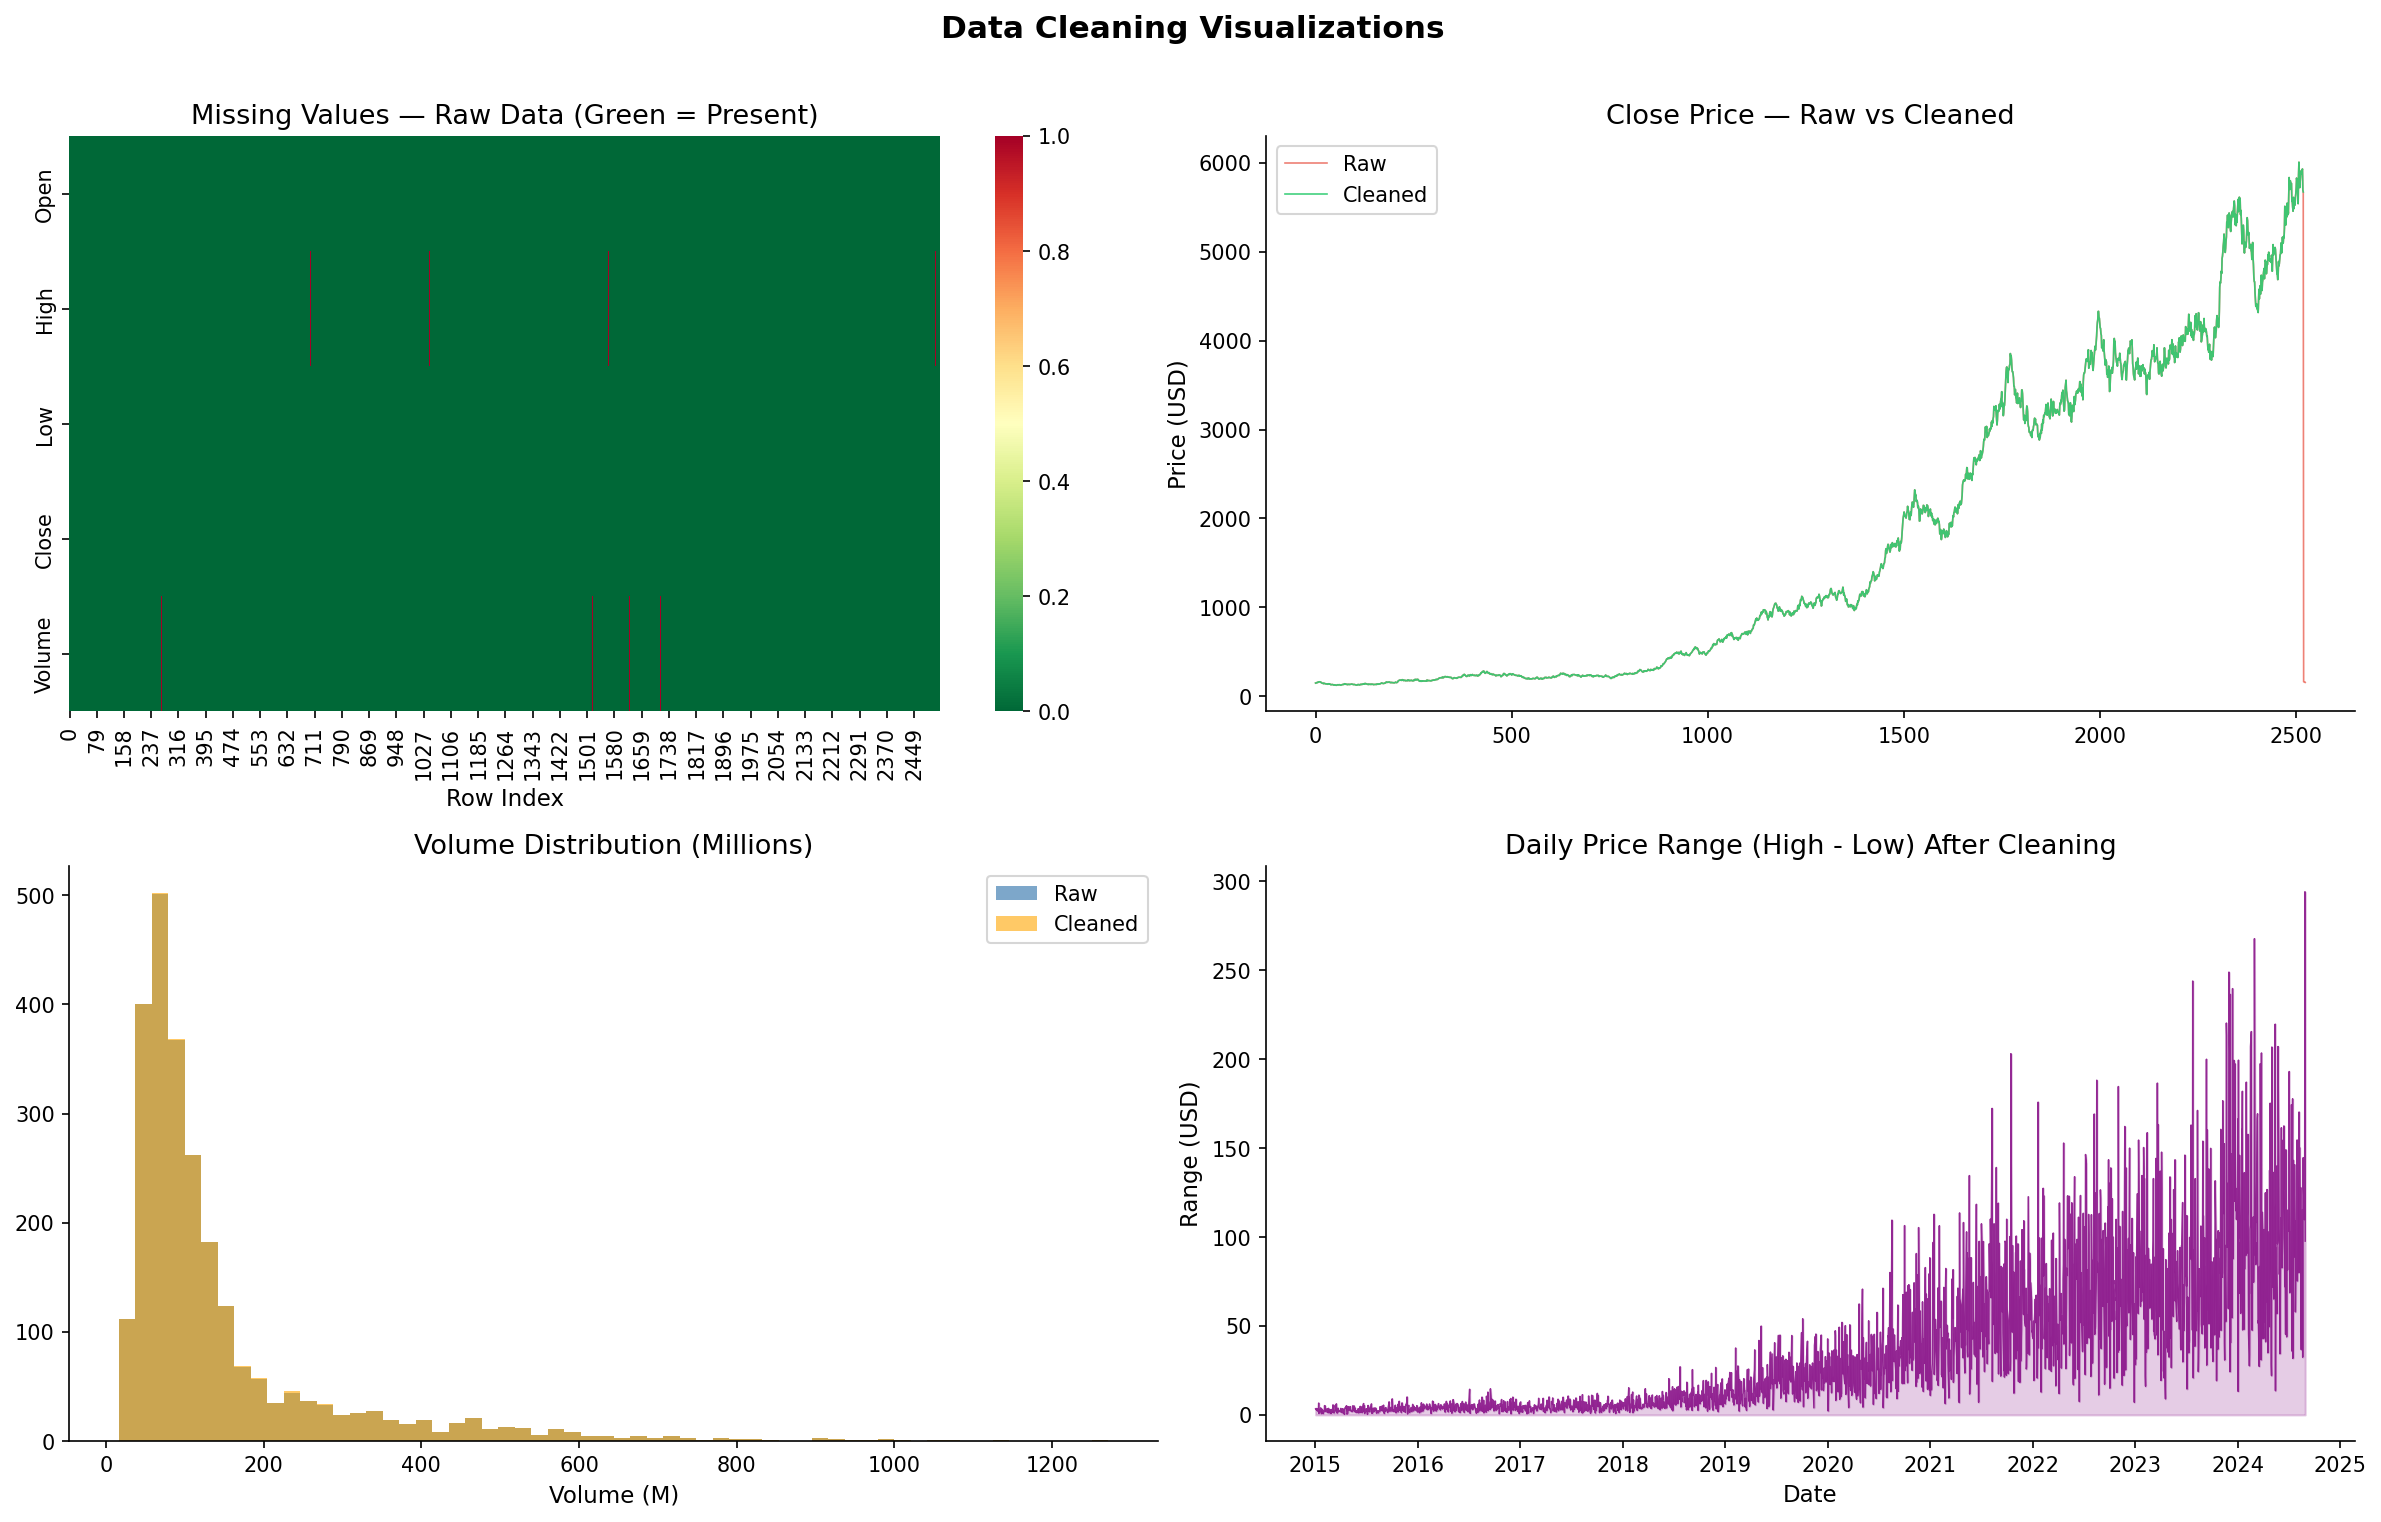

✅ Saved: cleaning_overview.png


In [14]:
# ─── Cleaning Visualizations ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. NaN heatmap (raw)
nan_matrix = df_raw[['Open','High','Low','Close','Volume']].isna()
sns.heatmap(nan_matrix.T, cbar=True, cmap='RdYlGn_r', ax=axes[0,0],
            yticklabels=['Open','High','Low','Close','Volume'])
axes[0,0].set_title("Missing Values — Raw Data (Green = Present)")
axes[0,0].set_xlabel("Row Index")

# 2. Close price before & after
axes[0,1].plot(df_raw['Close'].values, color='#e74c3c', alpha=0.7, linewidth=0.8, label='Raw')
axes[0,1].plot(df['Close'].values, color='#2ecc71', alpha=0.9, linewidth=0.8, label='Cleaned')
axes[0,1].set_title("Close Price — Raw vs Cleaned")
axes[0,1].set_ylabel("Price (USD)")
axes[0,1].legend()

# 3. Volume distribution
axes[1,0].hist(df_raw['Volume'].dropna() / 1e6, bins=60, color='steelblue', alpha=0.7, label='Raw')
axes[1,0].hist(df['Volume'] / 1e6, bins=60, color='orange', alpha=0.6, label='Cleaned')
axes[1,0].set_title("Volume Distribution (Millions)")
axes[1,0].set_xlabel("Volume (M)")
axes[1,0].legend()

# 4. OHLC daily ranges
df['Range'] = df['High'] - df['Low']
axes[1,1].plot(df['Date'], df['Range'], color='purple', linewidth=0.7, alpha=0.8)
axes[1,1].fill_between(df['Date'], df['Range'], alpha=0.2, color='purple')
axes[1,1].set_title("Daily Price Range (High - Low) After Cleaning")
axes[1,1].set_ylabel("Range (USD)")
axes[1,1].set_xlabel("Date")

plt.suptitle("Data Cleaning Visualizations", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{DIRS['viz_cleaning']}/cleaning_overview.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: cleaning_overview.png")

| Visualization                | Purpose                                 | Key Observation                                   | Interpretation                                    | Conclusion                                       |
| ---------------------------- | --------------------------------------- | ------------------------------------------------- | ------------------------------------------------- | ------------------------------------------------ |
| Missing Values Heatmap       | Identify missing data patterns          | Very few missing values, randomly distributed     | No systematic data gaps                           | Simple imputation sufficient; no major data loss |
| Close Price (Raw vs Cleaned) | Validate cleaning impact on time series | Cleaned line overlaps raw; anomaly removed at end | Cleaning fixed corrupted/missing values           | Trend preserved; data reliable for analysis      |
| Volume Distribution          | Analyze distribution & outliers         | Right-skewed; extreme values slightly reduced     | Outliers controlled without changing distribution | Data remains realistic; noise reduced            |
| Daily Price Range            | Measure volatility (High - Low)         | Volatility increases over time with spikes        | Reflects real market behavior                     | Suitable for risk & volatility analysis          |


## Section 6 — EDA: Univariate Analysis
Distribution of each OHLCV variable — shape, skew, kurtosis, outliers.

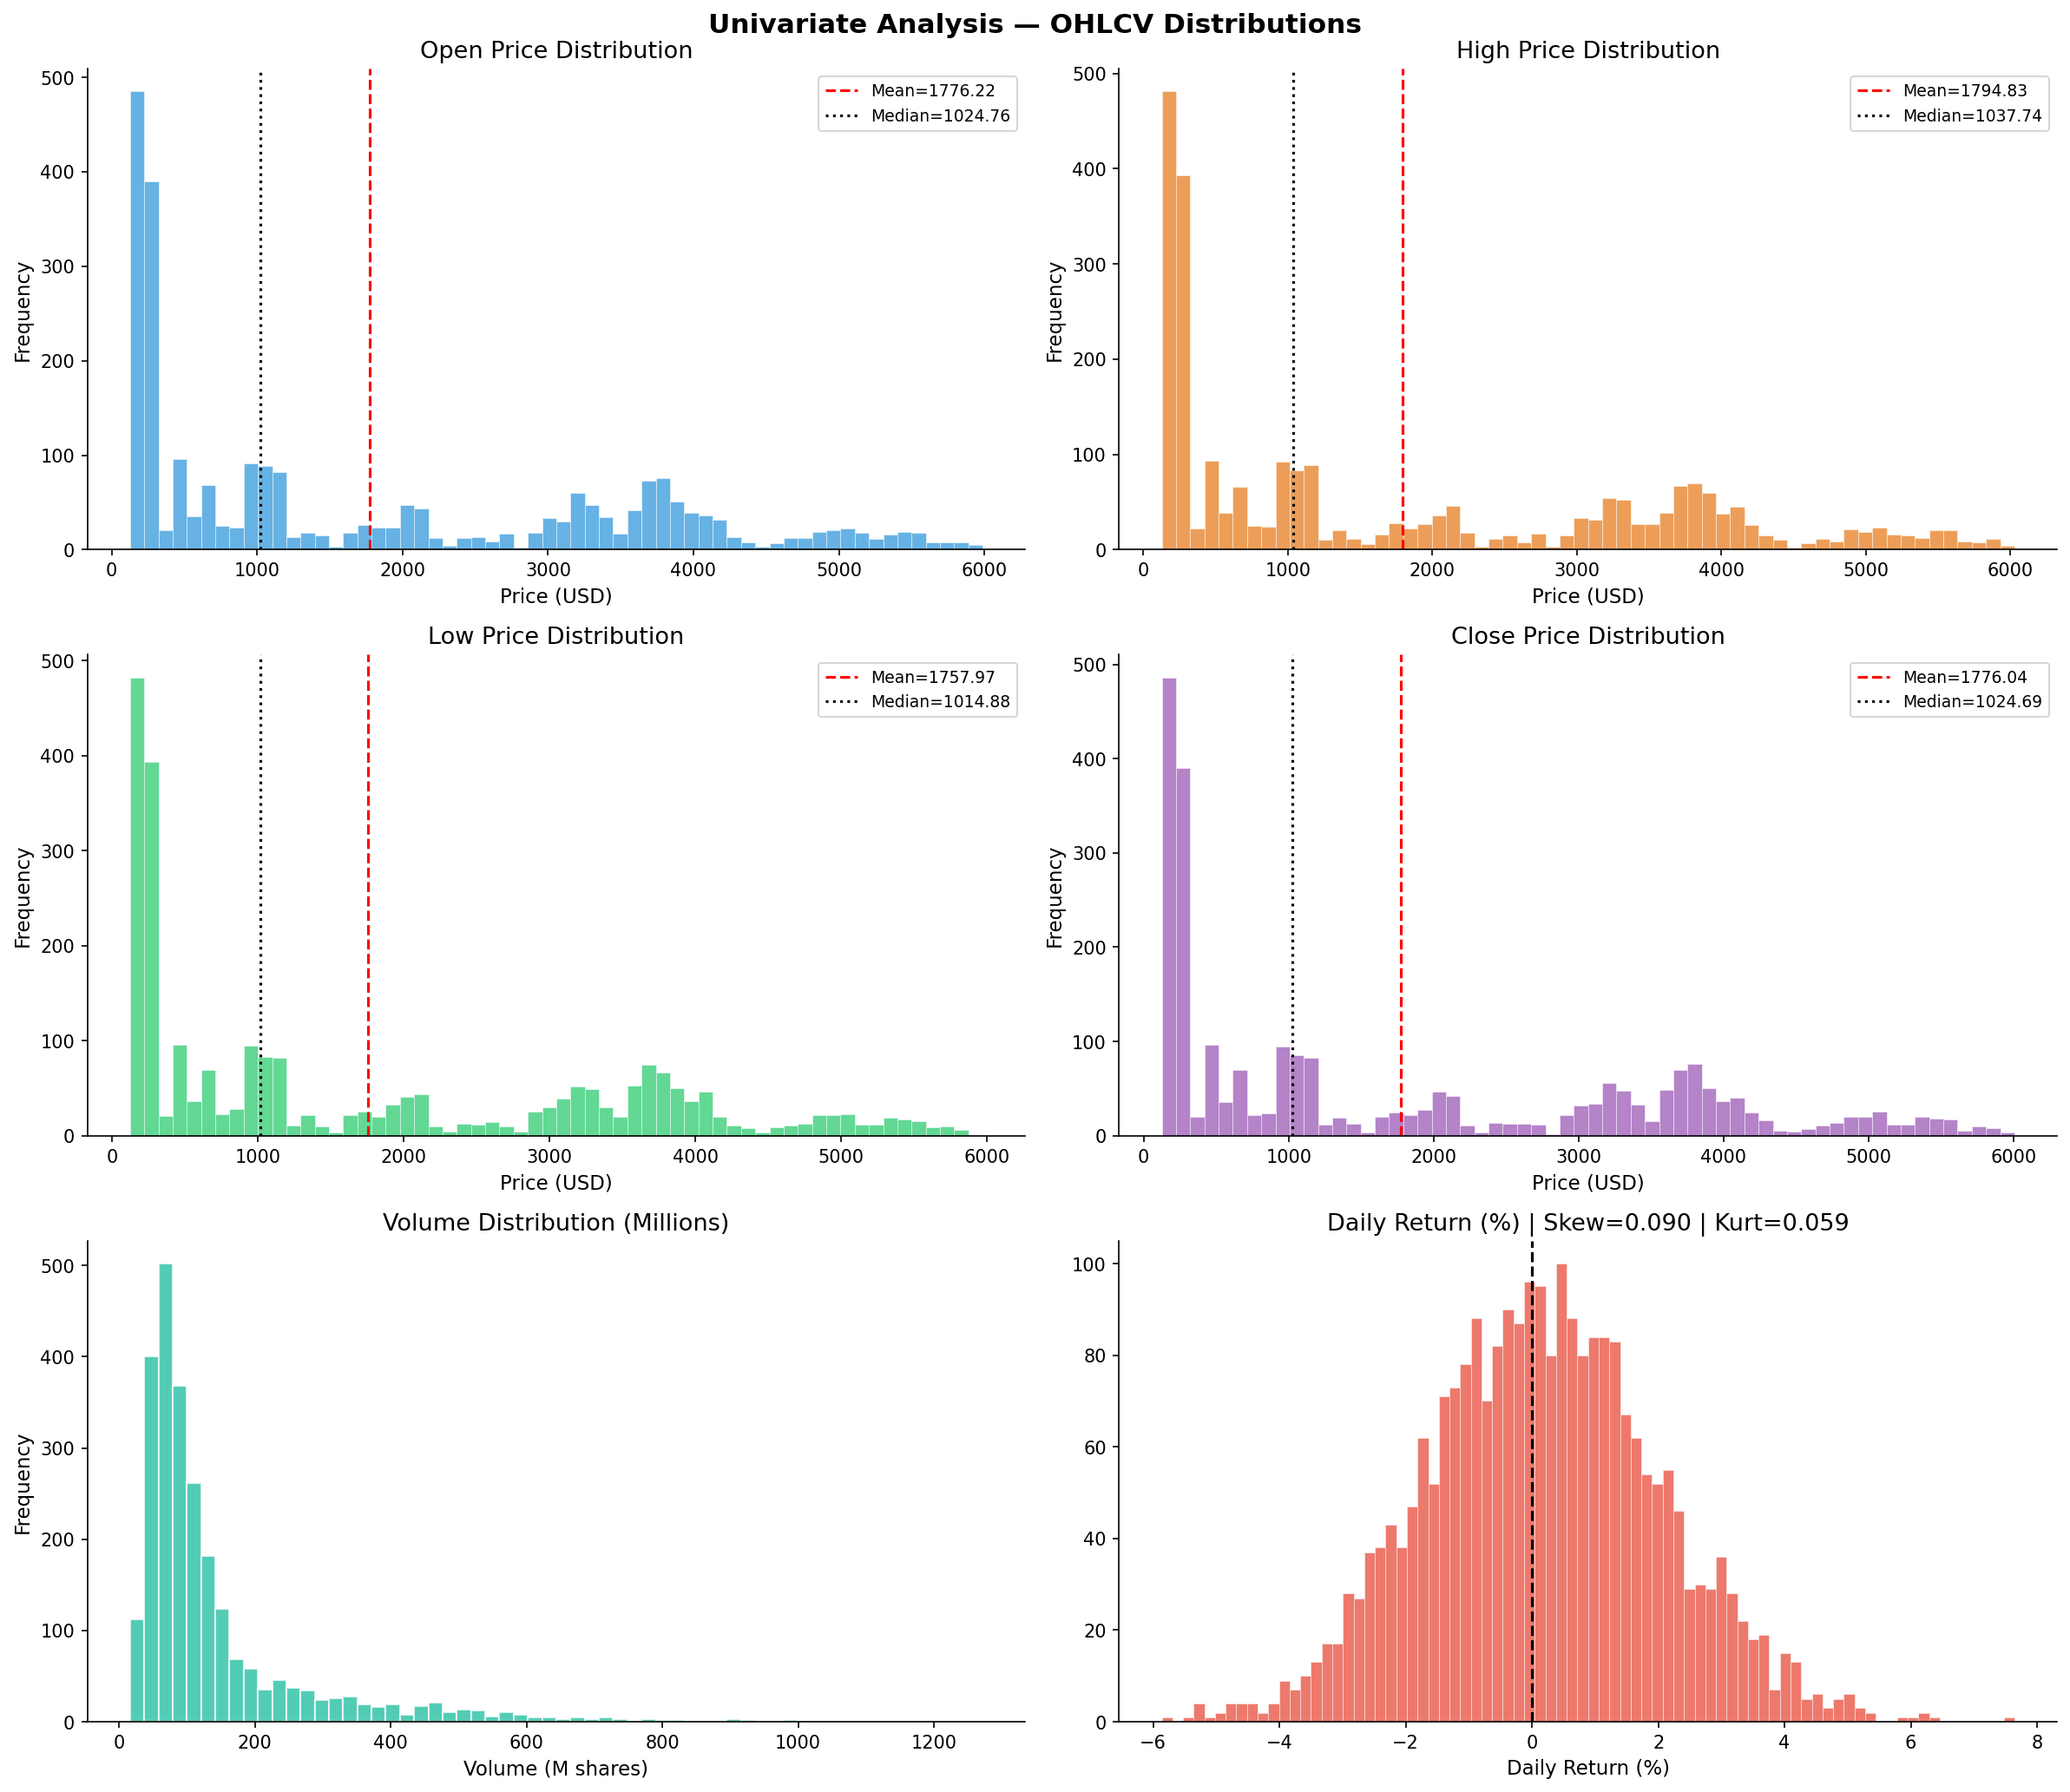

✅ Saved: univariate_distributions.png


In [15]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

price_cols_eda = ['Open', 'High', 'Low', 'Close']
colors_eda     = ['#3498db','#e67e22','#2ecc71','#9b59b6']

# Price distributions
for i, (col, c) in enumerate(zip(price_cols_eda, colors_eda)):
    ax = axes[i//2, i%2]
    ax.hist(df[col], bins=60, color=c, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(df[col].mean(),   color='red',   linestyle='--', linewidth=1.5, label=f'Mean={df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='black', linestyle=':',  linewidth=1.5, label=f'Median={df[col].median():.2f}')
    ax.set_title(f"{col} Price Distribution")
    ax.set_xlabel("Price (USD)")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

# Volume
axes[2,0].hist(df['Volume'] / 1e6, bins=60, color='#1abc9c', alpha=0.75, edgecolor='white')
axes[2,0].set_title("Volume Distribution (Millions)")
axes[2,0].set_xlabel("Volume (M shares)")
axes[2,0].set_ylabel("Frequency")

# Daily Return
ret = df['Daily_Return'].dropna()
axes[2,1].hist(ret, bins=80, color='#e74c3c', alpha=0.75, edgecolor='white', linewidth=0.3)
axes[2,1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[2,1].set_title(f"Daily Return (%) | Skew={ret.skew():.3f} | Kurt={ret.kurt():.3f}")
axes[2,1].set_xlabel("Daily Return (%)")

plt.suptitle("Univariate Analysis — OHLCV Distributions", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['viz_eda']}/univariate_distributions.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: univariate_distributions.png")

| Visualization             | Purpose                                   | Key Observation                           | Interpretation                                       | Conclusion                                          |
| ------------------------- | ----------------------------------------- | ----------------------------------------- | ---------------------------------------------------- | --------------------------------------------------- |
| Open Price Distribution   | Understand distribution of opening prices | Mean > Median (right-skewed); wide spread | Presence of high-value outliers pulling mean up      | Market shows growth phases; non-normal distribution |
| High Price Distribution   | Analyze peak price behavior               | Similar right-skewed pattern; long tail   | Extreme highs occur occasionally                     | Indicates volatility spikes and bullish phases      |
| Low Price Distribution    | Examine lower bounds of price             | Right-skewed; clustered at lower values   | Most prices concentrated in lower range historically | Asset spent longer time in early lower price ranges |
| Close Price Distribution  | Understand final trading price behavior   | Mean > Median; similar to Open            | Consistent skew across OHLC                          | Confirms trend consistency across price metrics     |
| Volume Distribution       | Analyze trading activity distribution     | Highly right-skewed; few extreme spikes   | Large trades are rare but impactful                  | Volume outliers may influence price movements       |
| Daily Return Distribution | Evaluate returns behavior & risk          | Near symmetric; Skew ≈ 0, low kurtosis    | Returns roughly normally distributed                 | Suitable for statistical modeling and forecasting   |


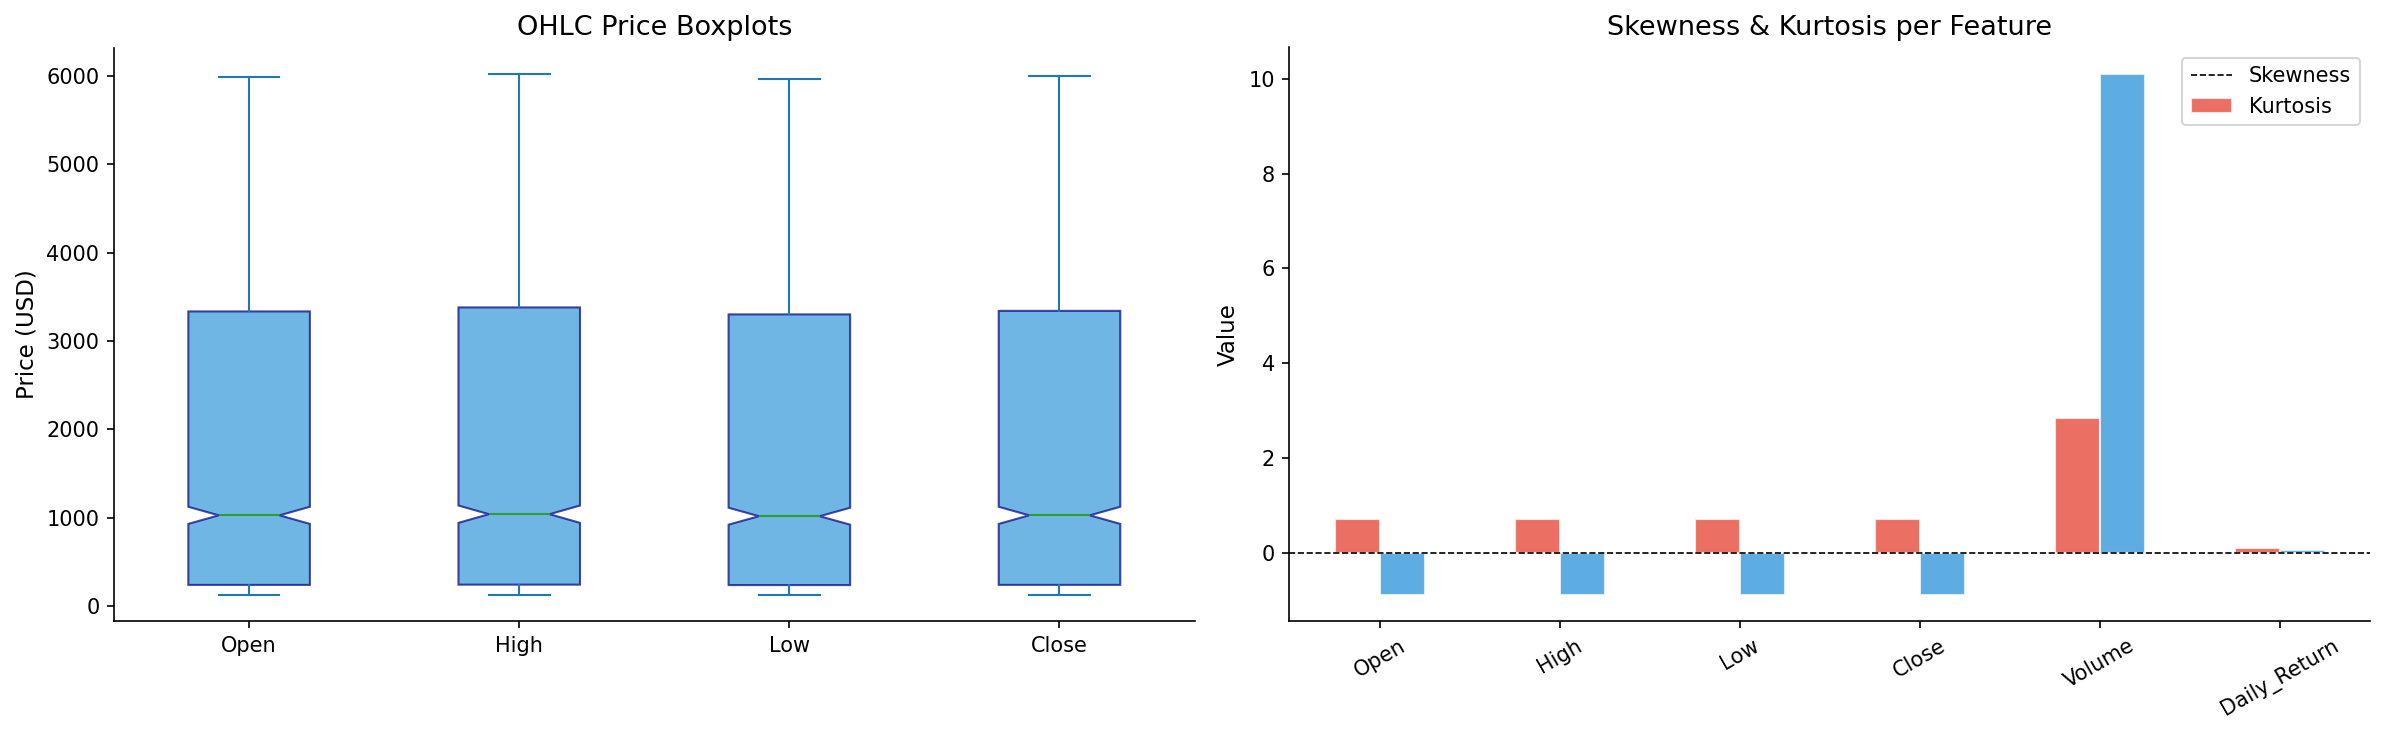

✅ Saved: boxplot_skewness.png


In [16]:
# ─── Box plots + Skewness summary ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Boxplots
df[['Open','High','Low','Close']].plot(kind='box', ax=axes[0],
    patch_artist=True, notch=True,
    boxprops=dict(facecolor='#3498db', color='navy', alpha=0.7))
axes[0].set_title("OHLC Price Boxplots")
axes[0].set_ylabel("Price (USD)")

# Skewness & Kurtosis bar chart
stats_df = df[['Open','High','Low','Close','Volume','Daily_Return']].agg(['skew','kurt']).T
stats_df.plot(kind='bar', ax=axes[1], color=['#e74c3c','#3498db'], alpha=0.8,
              edgecolor='white')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title("Skewness & Kurtosis per Feature")
axes[1].set_ylabel("Value")
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(["Skewness","Kurtosis"])

plt.tight_layout()
plt.savefig(f"{DIRS['viz_eda']}/boxplot_skewness.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: boxplot_skewness.png")

| Visualization                      | Purpose                                            | Key Observation                                             | Interpretation                                       | Conclusion                                            |
| ---------------------------------- | -------------------------------------------------- | ----------------------------------------------------------- | ---------------------------------------------------- | ----------------------------------------------------- |
| OHLC Boxplots                      | Analyze spread, median, and outliers in price data | Wide IQR; many upper outliers; similar patterns across OHLC | Prices are highly dispersed with extreme high values | Strong upward movements and volatility present        |
| Open, High, Low, Close (Skewness)  | Measure distribution asymmetry                     | All features show positive skewness                         | Long right tails due to high price spikes            | Non-normal distribution; influenced by bullish trends |
| Open, High, Low, Close (Kurtosis)  | Measure tail heaviness                             | Moderate kurtosis                                           | Presence of outliers but not extreme                 | Data has controlled tail risk                         |
| Volume (Skewness & Kurtosis)       | Analyze trading activity distribution              | Extremely high skewness & kurtosis                          | Heavy-tailed with extreme spikes                     | Volume is highly irregular; strong outlier impact     |
| Daily Return (Skewness & Kurtosis) | Assess return distribution shape                   | Near-zero skewness & low kurtosis                           | Approximately symmetric and normal-like              | Suitable for statistical and predictive modeling      |


## Section 7 — EDA: Time Series Analysis

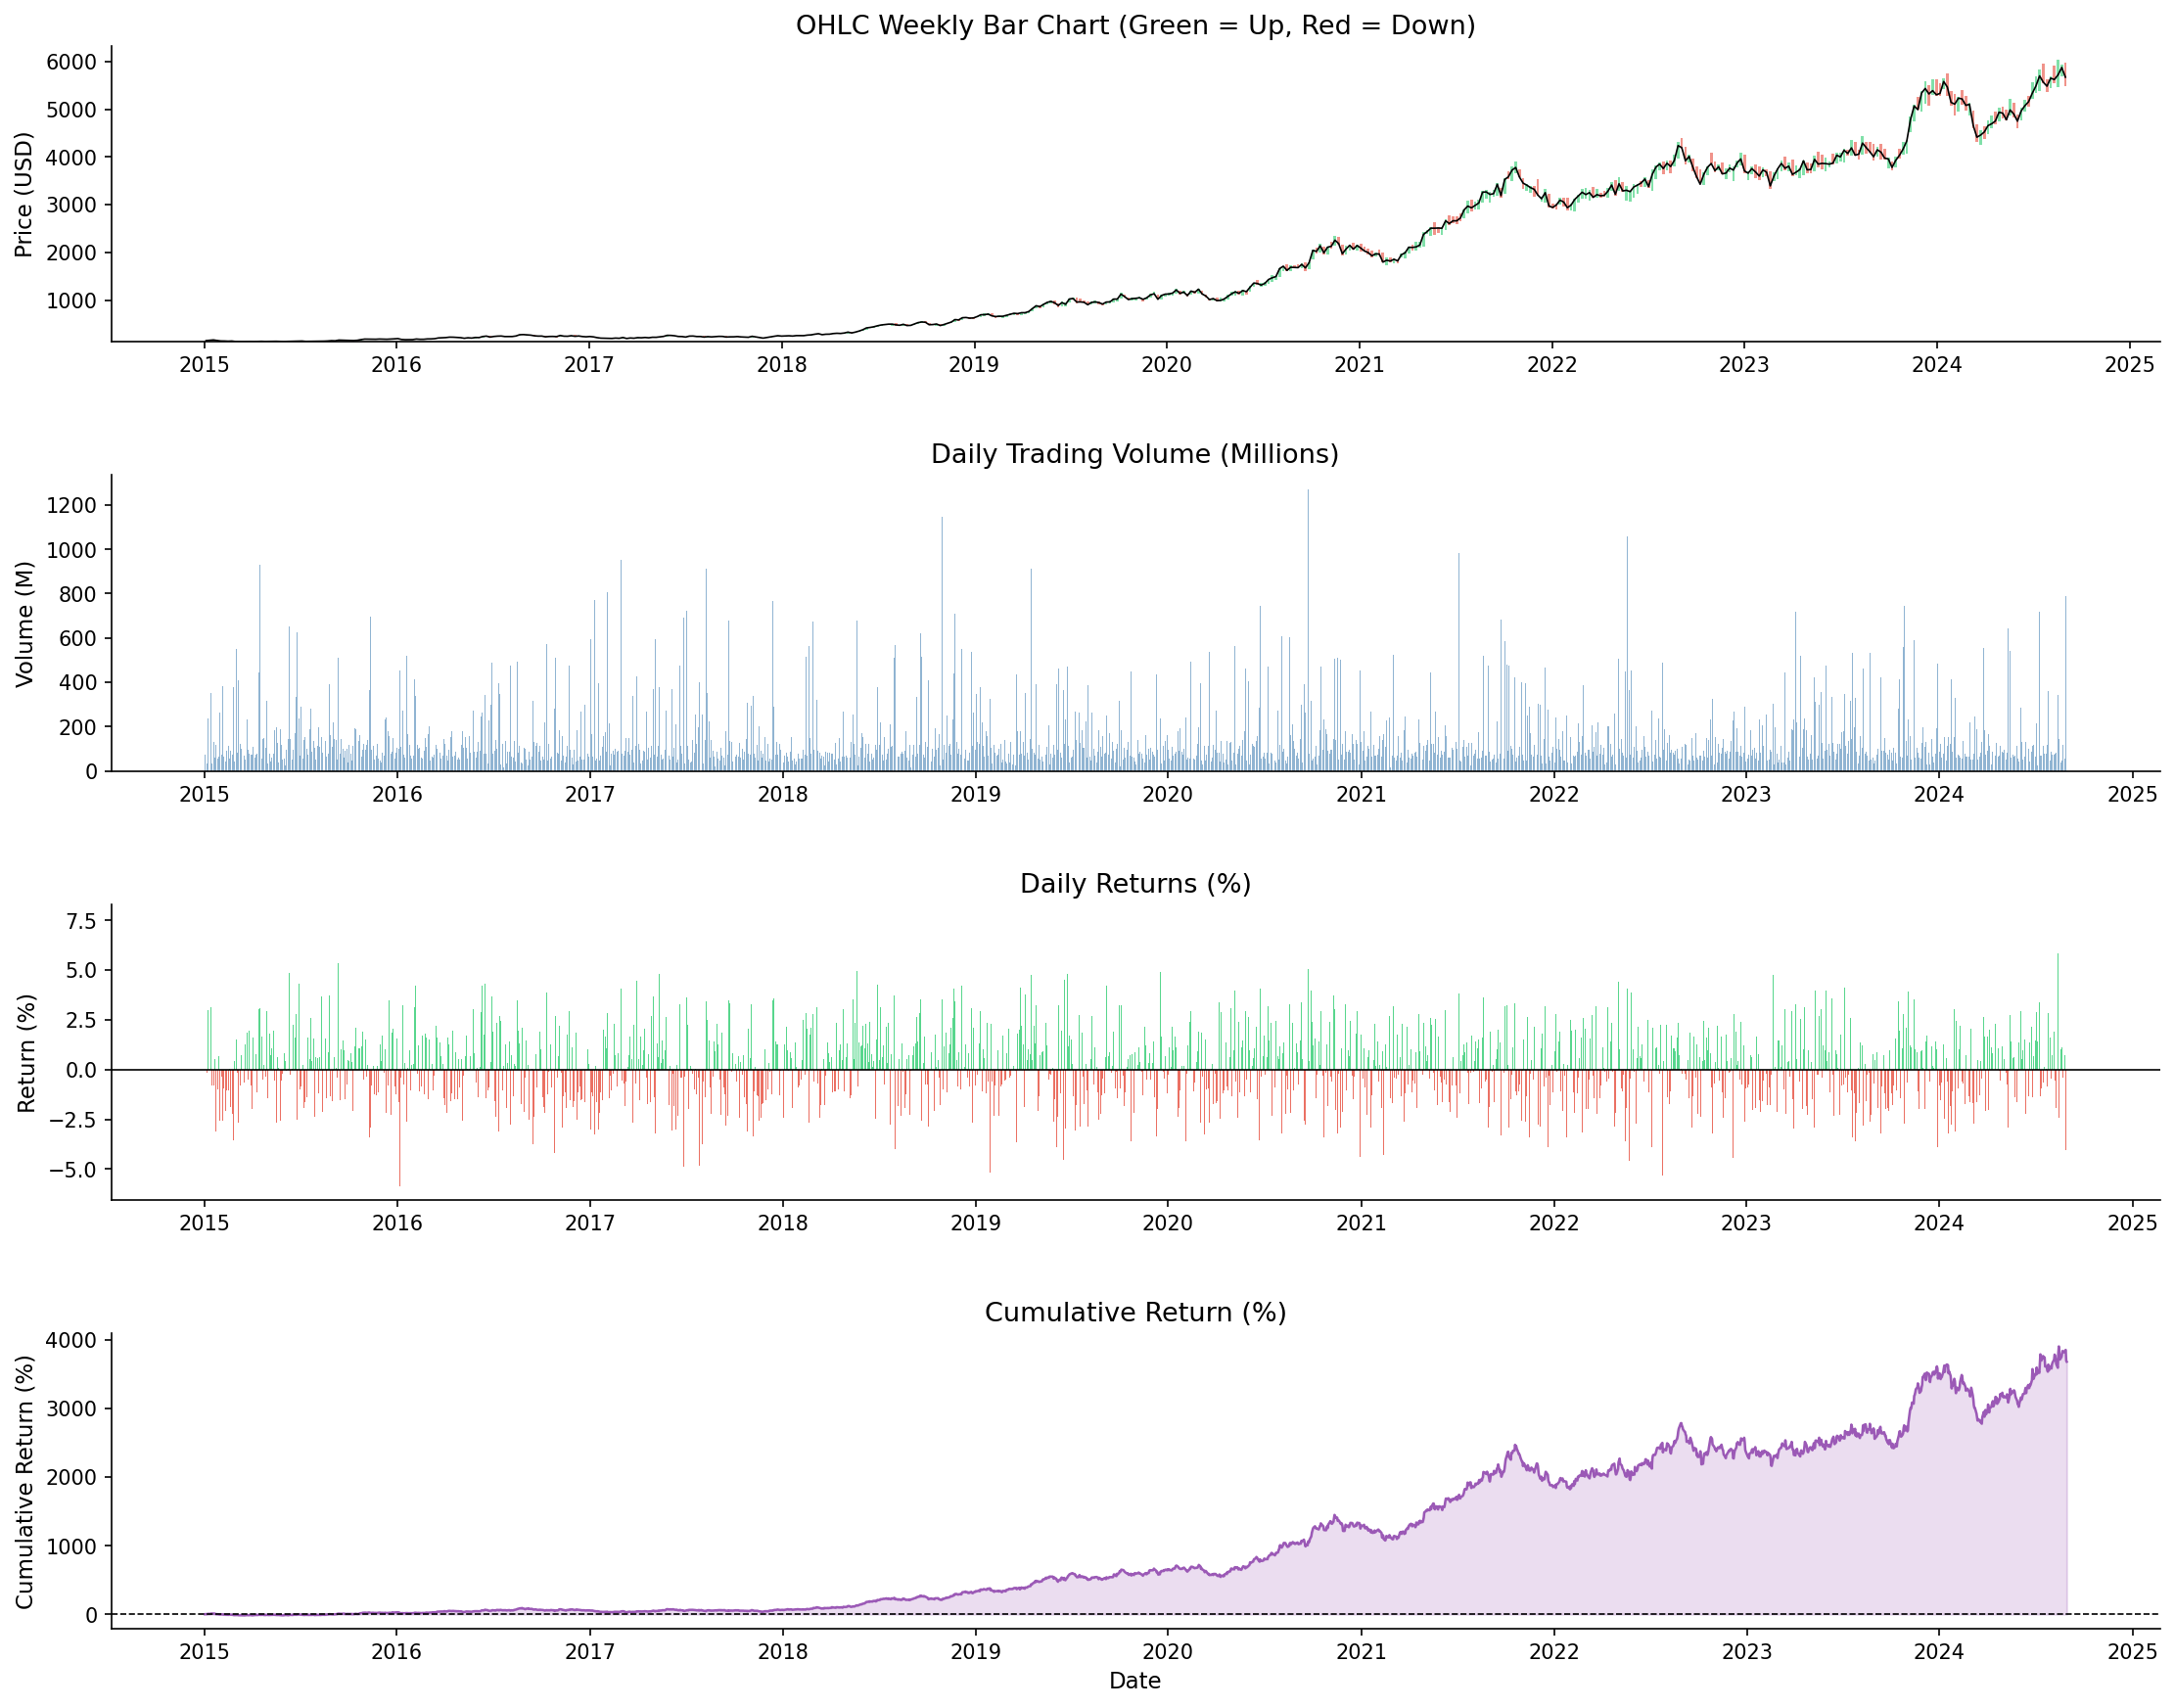

✅ Saved: time_series_analysis.png


In [17]:
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(4, 1, hspace=0.45)

# 1. OHLC Candlestick-style (weekly sampled)
ax1 = fig.add_subplot(gs[0])
weekly = df.set_index('Date').resample('W').agg(
    {'Open':'first','High':'max','Low':'min','Close':'last'})
colors_ = ['#2ecc71' if r['Close'] >= r['Open'] else '#e74c3c'
           for _, r in weekly.iterrows()]
ax1.bar(weekly.index, weekly['High'] - weekly['Low'],
        bottom=weekly['Low'], color=colors_, width=5, alpha=0.6)
ax1.plot(weekly.index, weekly['Close'], color='black', linewidth=0.8)
ax1.set_title("OHLC Weekly Bar Chart (Green = Up, Red = Down)")
ax1.set_ylabel("Price (USD)")

# 2. Volume over time
ax2 = fig.add_subplot(gs[1])
ax2.bar(df['Date'], df['Volume'] / 1e6, color='steelblue', alpha=0.6, width=1)
ax2.set_title("Daily Trading Volume (Millions)")
ax2.set_ylabel("Volume (M)")

# 3. Daily Returns
ax3 = fig.add_subplot(gs[2])
ret_colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in df['Daily_Return'].fillna(0)]
ax3.bar(df['Date'], df['Daily_Return'].fillna(0), color=ret_colors, alpha=0.8, width=1)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.set_title("Daily Returns (%)")
ax3.set_ylabel("Return (%)")

# 4. Cumulative Return
ax4 = fig.add_subplot(gs[3])
cum_ret = (1 + df['Daily_Return'].fillna(0) / 100).cumprod() - 1
ax4.plot(df['Date'], cum_ret * 100, color='#9b59b6', linewidth=1.2)
ax4.fill_between(df['Date'], cum_ret * 100, alpha=0.2, color='#9b59b6')
ax4.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax4.set_title("Cumulative Return (%)")
ax4.set_ylabel("Cumulative Return (%)")
ax4.set_xlabel("Date")

plt.savefig(f"{DIRS['viz_eda']}/time_series_analysis.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: time_series_analysis.png")

| Visualization         | Purpose                                 | Key Observation                                     | Interpretation                                             | Conclusion                                    |
| --------------------- | --------------------------------------- | --------------------------------------------------- | ---------------------------------------------------------- | --------------------------------------------- |
| OHLC Weekly Bar Chart | Analyze price trend & weekly movement   | Strong upward trend with periodic red (down) weeks  | Market shows consistent growth with short-term corrections | Long-term bullish trend with normal pullbacks |
| Daily Trading Volume  | Track trading activity over time        | Irregular spikes in volume; no consistent pattern   | Volume surges linked to major events or volatility         | Volume is event-driven and not stable         |
| Daily Returns (%)     | Measure short-term price changes        | Alternating positive & negative returns around zero | Returns fluctuate frequently with no long bias             | Market is volatile in short term but balanced |
| Cumulative Return (%) | Evaluate overall investment performance | Steady exponential growth over time                 | Compounding effect of returns drives long-term gains       | Strong long-term investment potential         |


#Overall Insight

1. Clear long-term uptrend despite short-term volatility

2. Volume spikes indicate market events or high activity periods

3. Returns fluctuate daily but balance out over time

4. Compounding leads to significant cumulative growth

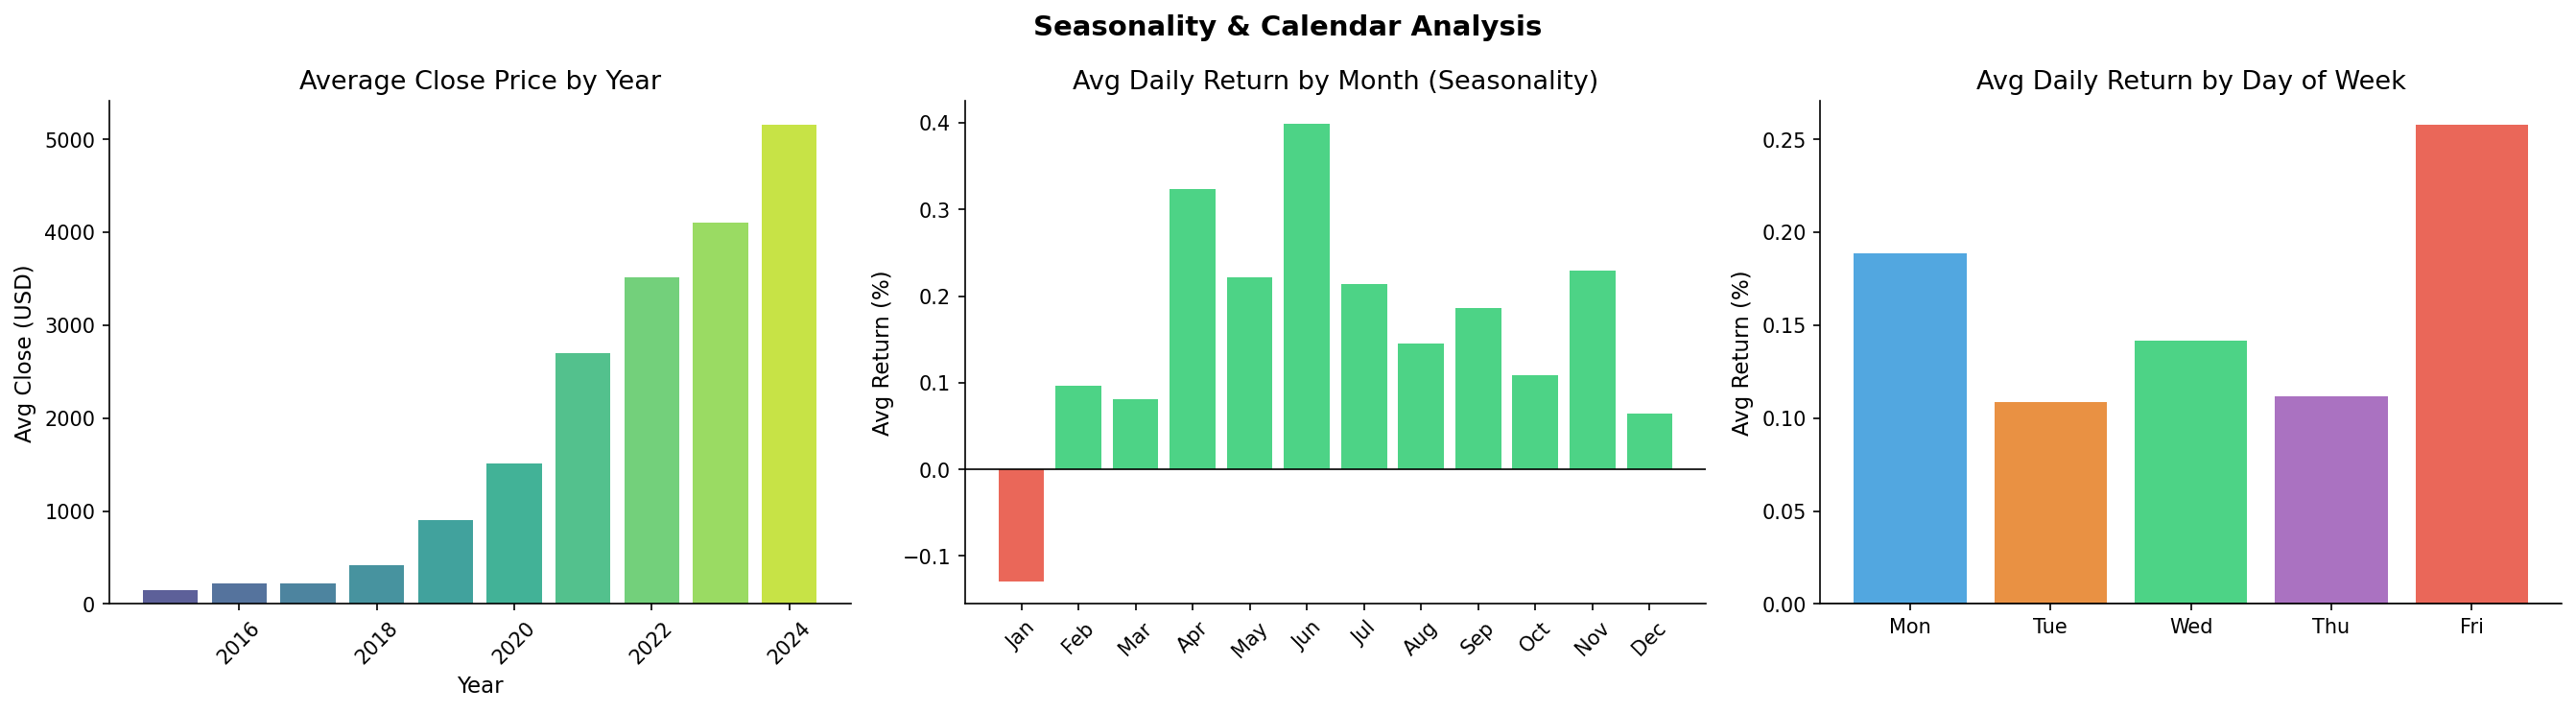

✅ Saved: seasonality_analysis.png


In [18]:
# ─── Yearly & Monthly Seasonality ─────────────────────────────────────────────
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DOW']   = df['Date'].dt.dayofweek   # 0=Mon

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Annual average close
yearly_close = df.groupby('Year')['Close'].mean()
axes[0].bar(yearly_close.index, yearly_close.values,
            color=plt.cm.viridis(np.linspace(0.2, 0.9, len(yearly_close))), alpha=0.85)
axes[0].set_title("Average Close Price by Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Avg Close (USD)")
axes[0].tick_params(axis='x', rotation=45)

# Monthly average return
monthly_ret = df.groupby('Month')['Daily_Return'].mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bar_colors = ['#2ecc71' if r > 0 else '#e74c3c' for r in monthly_ret.values]
axes[1].bar(month_labels, monthly_ret.values, color=bar_colors, alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title("Avg Daily Return by Month (Seasonality)")
axes[1].set_ylabel("Avg Return (%)")
axes[1].tick_params(axis='x', rotation=45)

# Day-of-week average return
dow_ret = df.groupby('DOW')['Daily_Return'].mean()
dow_labels = ['Mon','Tue','Wed','Thu','Fri']
axes[2].bar(dow_labels, dow_ret.values,
            color=['#3498db','#e67e22','#2ecc71','#9b59b6','#e74c3c'], alpha=0.85)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title("Avg Daily Return by Day of Week")
axes[2].set_ylabel("Avg Return (%)")

plt.suptitle("Seasonality & Calendar Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['viz_eda']}/seasonality_analysis.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: seasonality_analysis.png")

| Visualization                   | Purpose                               | Key Observation                                              | Interpretation                         | Conclusion                               |
| ------------------------------- | ------------------------------------- | ------------------------------------------------------------ | -------------------------------------- | ---------------------------------------- |
| Average Close Price by Year     | Analyze long-term yearly trend        | Consistent increase in average prices each year              | Strong upward growth over time         | Confirms long-term bullish market trend  |
| Avg Daily Return by Month       | Identify monthly seasonality patterns | Most months positive; January negative; peaks around Apr–Jun | Certain months yield higher returns    | Presence of seasonal patterns in returns |
| Avg Daily Return by Day of Week | Analyze weekday effect on returns     | Friday highest returns; Tuesday lowest                       | End-of-week shows stronger performance | Weak but noticeable day-of-week effect   |


##  Section 8 — EDA: Rolling Statistics & Volatility Clustering

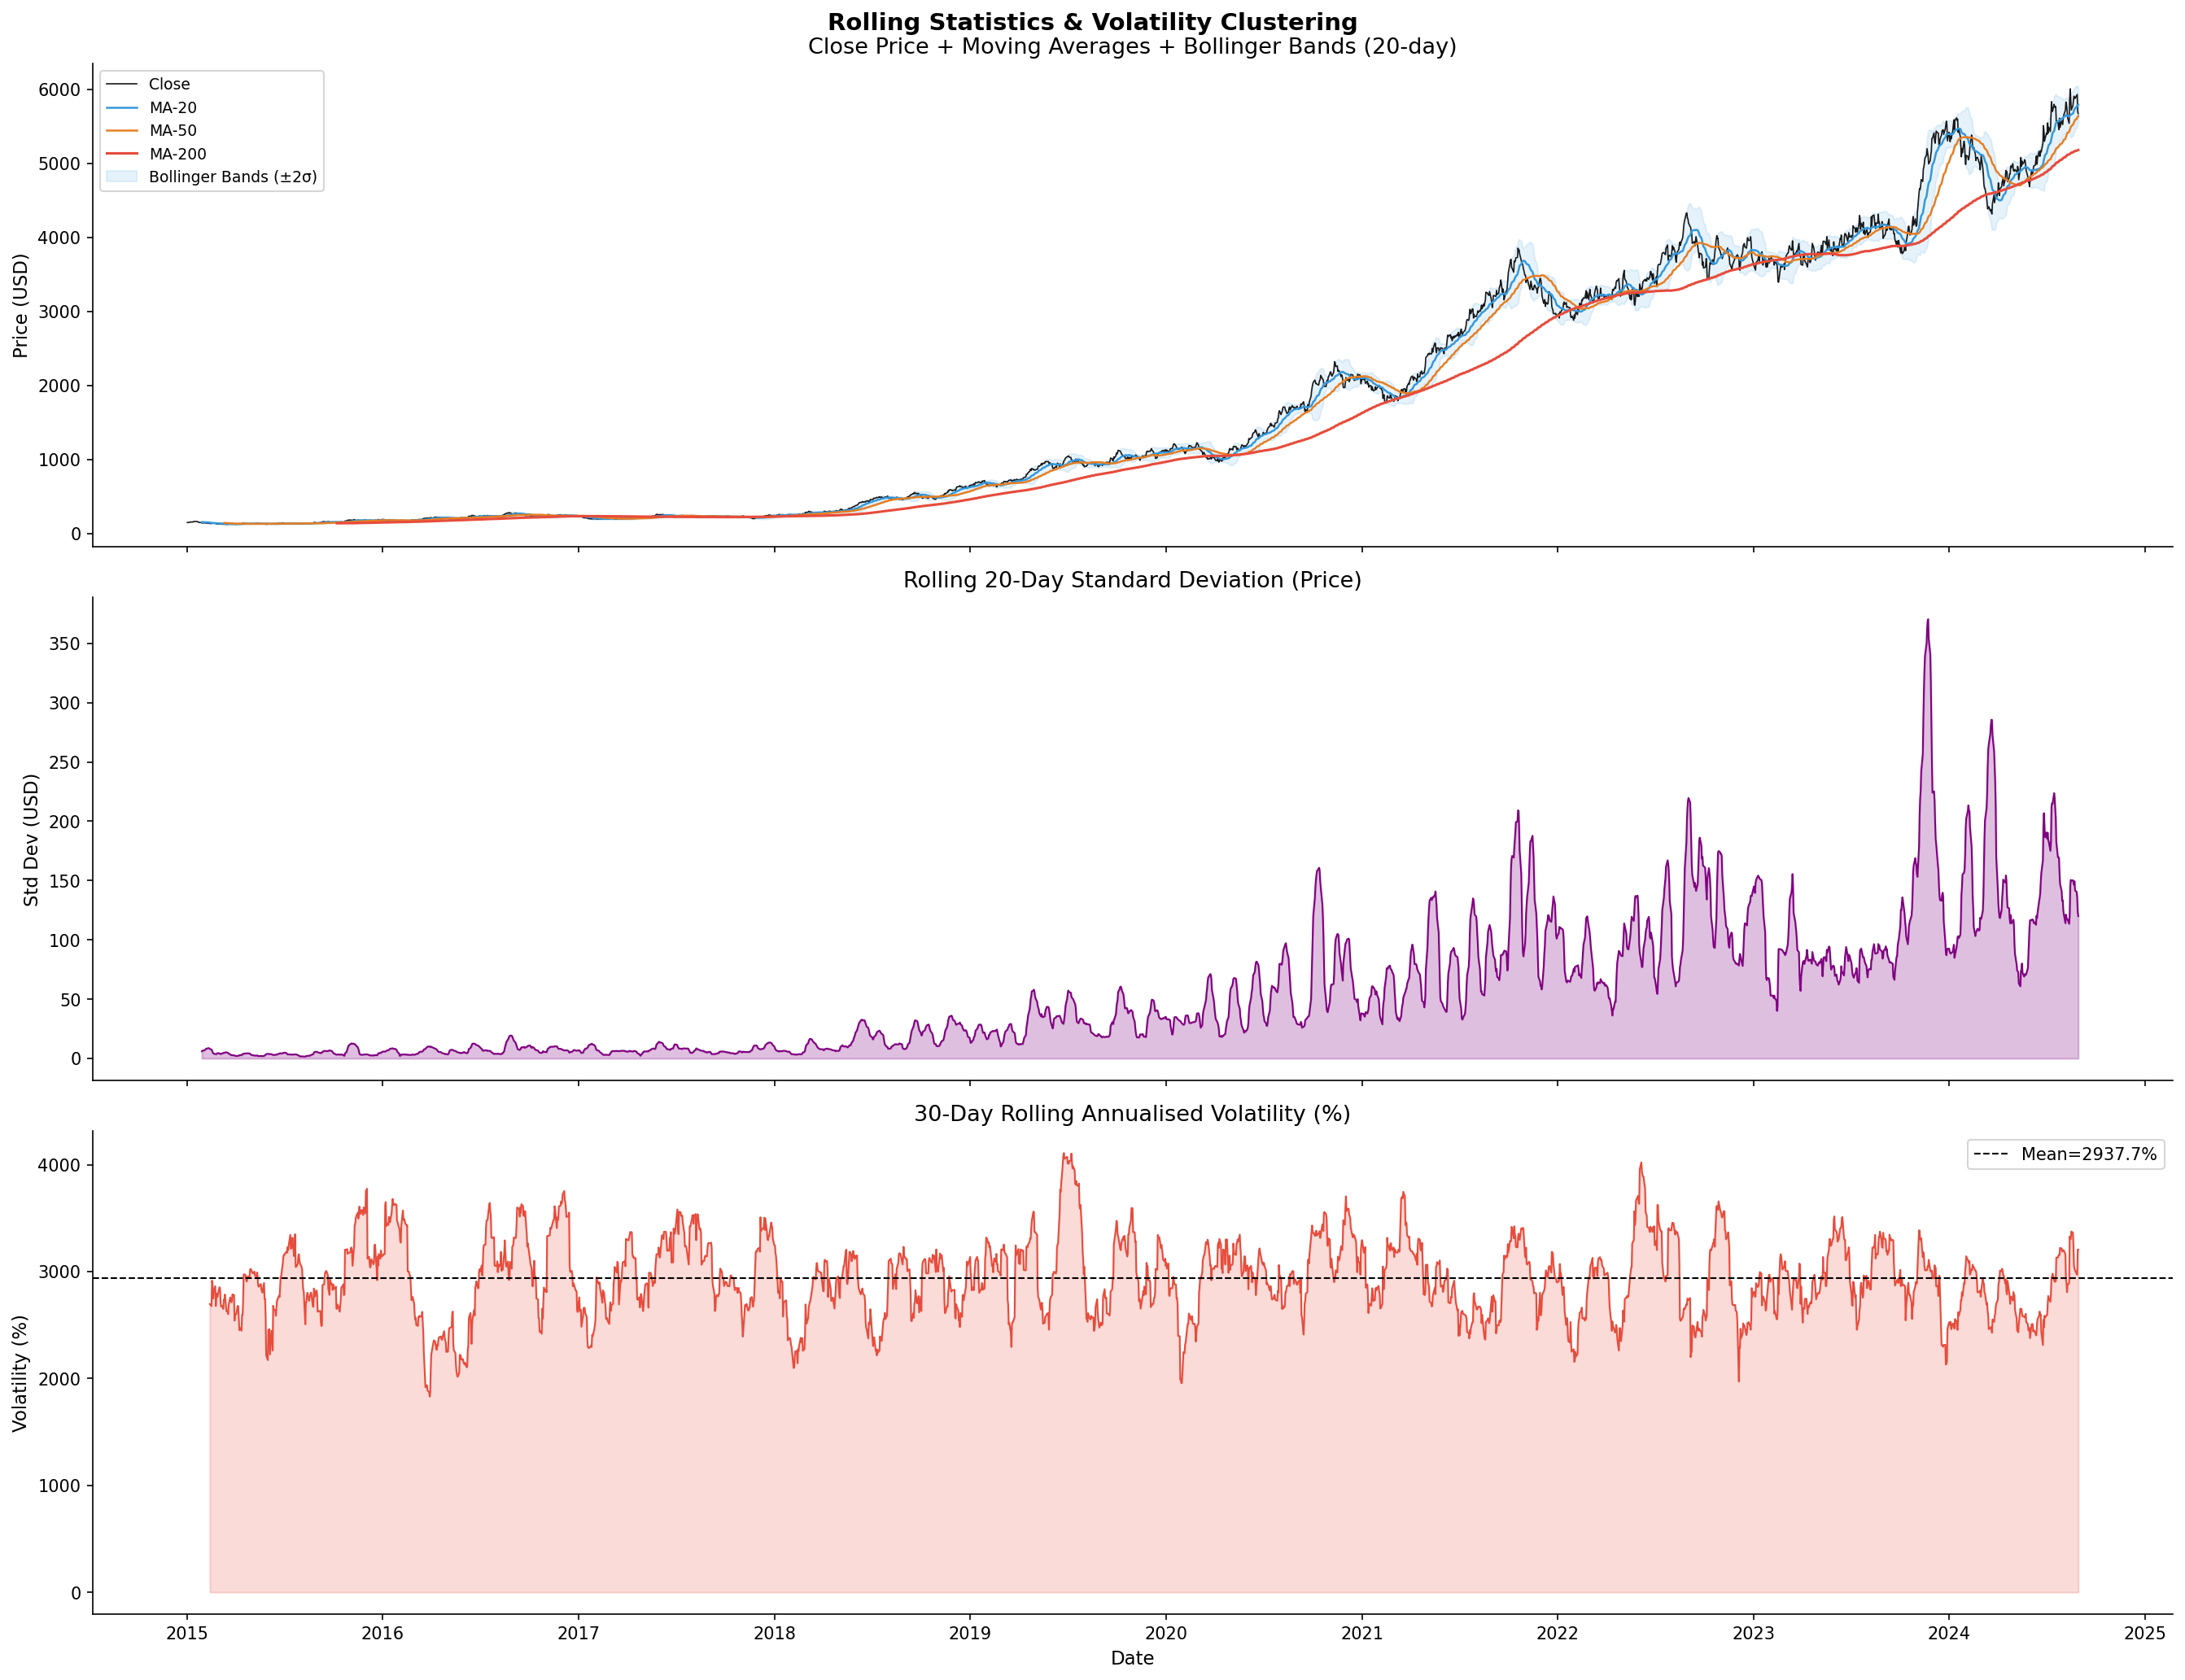

✅ Saved: rolling_stats_volatility.png


In [19]:
# Rolling windows
df['MA_20']   = df['Close'].rolling(20).mean()
df['MA_50']   = df['Close'].rolling(50).mean()
df['MA_200']  = df['Close'].rolling(200).mean()
df['Std_20']  = df['Close'].rolling(20).std()
df['Vol_30d'] = df['Daily_Return'].rolling(30).std() * np.sqrt(252)  # Annualized

fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True)

# 1. Price + Moving Averages
axes[0].plot(df['Date'], df['Close'],  color='black', linewidth=0.8, alpha=0.9, label='Close')
axes[0].plot(df['Date'], df['MA_20'],  color='#3498db', linewidth=1.2, label='MA-20')
axes[0].plot(df['Date'], df['MA_50'],  color='#e67e22', linewidth=1.2, label='MA-50')
axes[0].plot(df['Date'], df['MA_200'], color='#e74c3c', linewidth=1.5, label='MA-200')
axes[0].fill_between(df['Date'],
    df['MA_20'] - 2*df['Std_20'],
    df['MA_20'] + 2*df['Std_20'],
    alpha=0.12, color='#3498db', label='Bollinger Bands (±2σ)')
axes[0].set_title("Close Price + Moving Averages + Bollinger Bands (20-day)")
axes[0].set_ylabel("Price (USD)")
axes[0].legend(fontsize=9)

# 2. Rolling Std (Volatility)
axes[1].plot(df['Date'], df['Std_20'], color='purple', linewidth=1)
axes[1].fill_between(df['Date'], df['Std_20'], alpha=0.25, color='purple')
axes[1].set_title("Rolling 20-Day Standard Deviation (Price)")
axes[1].set_ylabel("Std Dev (USD)")

# 3. Annualised Volatility
axes[2].plot(df['Date'], df['Vol_30d'] * 100, color='#e74c3c', linewidth=1)
axes[2].fill_between(df['Date'], df['Vol_30d'] * 100, alpha=0.2, color='#e74c3c')
axes[2].axhline(df['Vol_30d'].mean() * 100, color='black', linestyle='--',
                linewidth=1, label=f'Mean={df["Vol_30d"].mean()*100:.1f}%')
axes[2].set_title("30-Day Rolling Annualised Volatility (%)")
axes[2].set_ylabel("Volatility (%)")
axes[2].set_xlabel("Date")
axes[2].legend()

plt.suptitle("Rolling Statistics & Volatility Clustering", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['viz_eda']}/rolling_stats_volatility.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: rolling_stats_volatility.png")

| Visualization                                   | Purpose                                                  | Key Observation                                                                        | Interpretation                                                           | Conclusion                                          |
| ----------------------------------------------- | -------------------------------------------------------- | -------------------------------------------------------------------------------------- | ------------------------------------------------------------------------ | --------------------------------------------------- |
| Close Price + Moving Averages + Bollinger Bands | Identify trend, support/resistance, and volatility bands | Price follows upward trend; short-term MAs react faster; bands widen during volatility | MA-200 shows long-term trend; Bollinger Bands expand in volatile periods | Strong bullish trend with dynamic volatility phases |
| Rolling 20-Day Standard Deviation               | Measure short-term price volatility                      | Volatility increases over time with sharp spikes                                       | Periods of high uncertainty cluster together                             | Evidence of volatility clustering in market         |
| 30-Day Annualised Volatility                    | Evaluate risk over time                                  | Volatility fluctuates around mean with frequent spikes                                 | Market risk is time-varying, not constant                                | Suitable for risk modeling and dynamic strategies   |


## Section 9 — EDA: Correlation & Bivariate Analysis

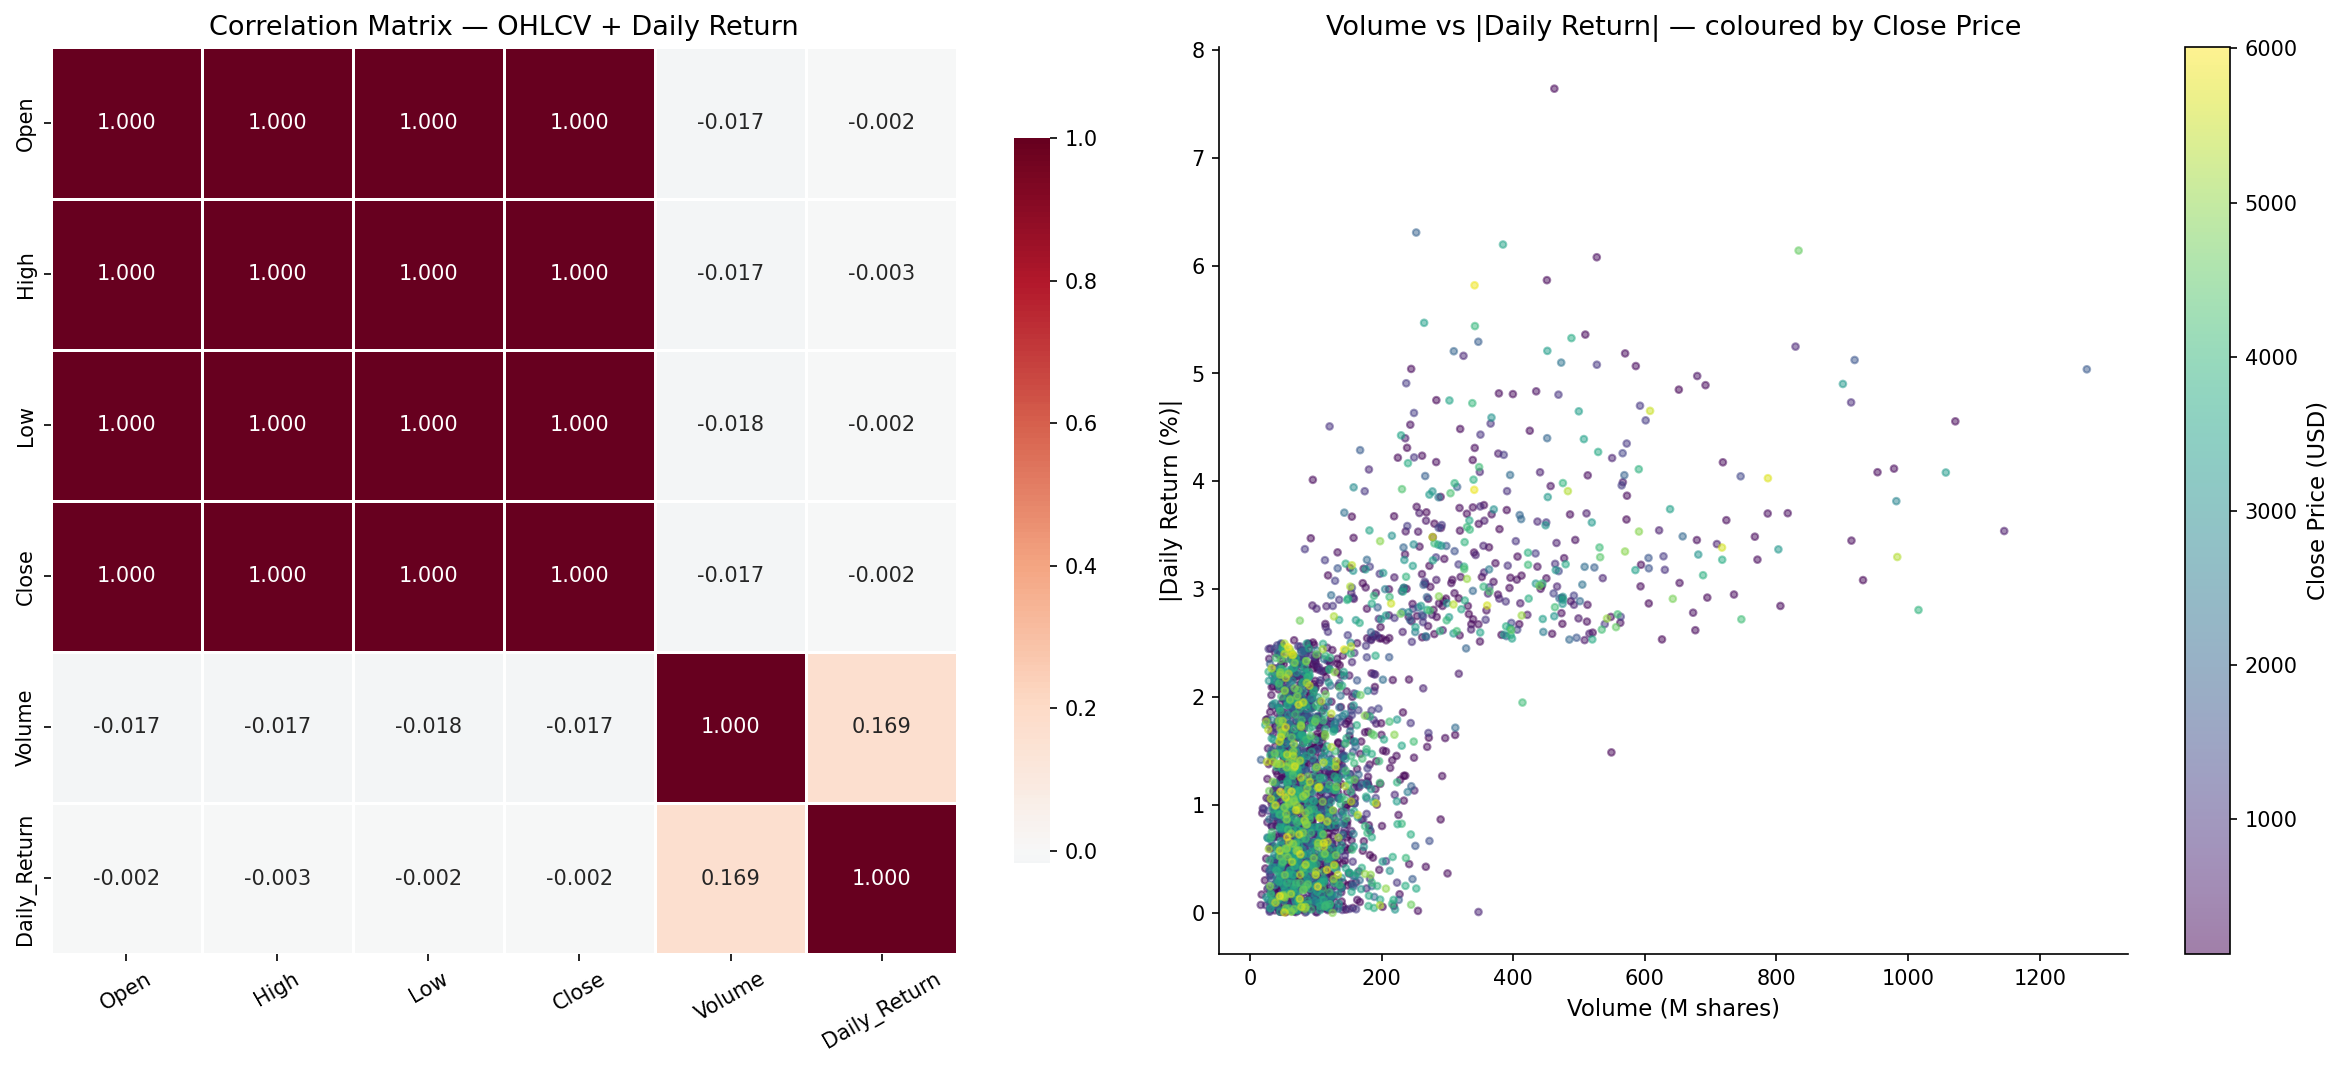

✅ Saved: correlation_bivariate.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Correlation heatmap
corr_cols = ['Open','High','Low','Close','Volume','Daily_Return']
corr_mat  = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=axes[0], mask=False,
            annot_kws={'size': 10}, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
axes[0].set_title("Correlation Matrix — OHLCV + Daily Return")
axes[0].tick_params(axis='x', rotation=30)

# Volume vs Daily Return scatter
sc = axes[1].scatter(df['Volume'] / 1e6, df['Daily_Return'].abs(),
                     c=df['Close'], cmap='viridis', alpha=0.5, s=10)
plt.colorbar(sc, ax=axes[1], label='Close Price (USD)')
axes[1].set_title("Volume vs |Daily Return| — coloured by Close Price")
axes[1].set_xlabel("Volume (M shares)")
axes[1].set_ylabel("|Daily Return (%)|")

plt.tight_layout()
plt.savefig(f"{DIRS['viz_eda']}/correlation_bivariate.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: correlation_bivariate.png")

| Visualization                           | Purpose                                 | Key Observation                                                           | Interpretation                                    | Conclusion                                            |
| --------------------------------------- | --------------------------------------- | ------------------------------------------------------------------------- | ------------------------------------------------- | ----------------------------------------------------- |
| Correlation Matrix (OHLCV + Returns)    | Measure relationships between variables | OHLC highly correlated (~1.0); Volume weak; Returns near zero correlation | Price features move together; returns independent | Multicollinearity in OHLC; returns suitable as target |
| Volume vs Absolute Daily Return Scatter | Analyze volume vs volatility            | Slight positive relation; higher volume → higher return magnitude         | Trading activity linked with volatility spikes    | Volume is a weak indicator of volatility              |


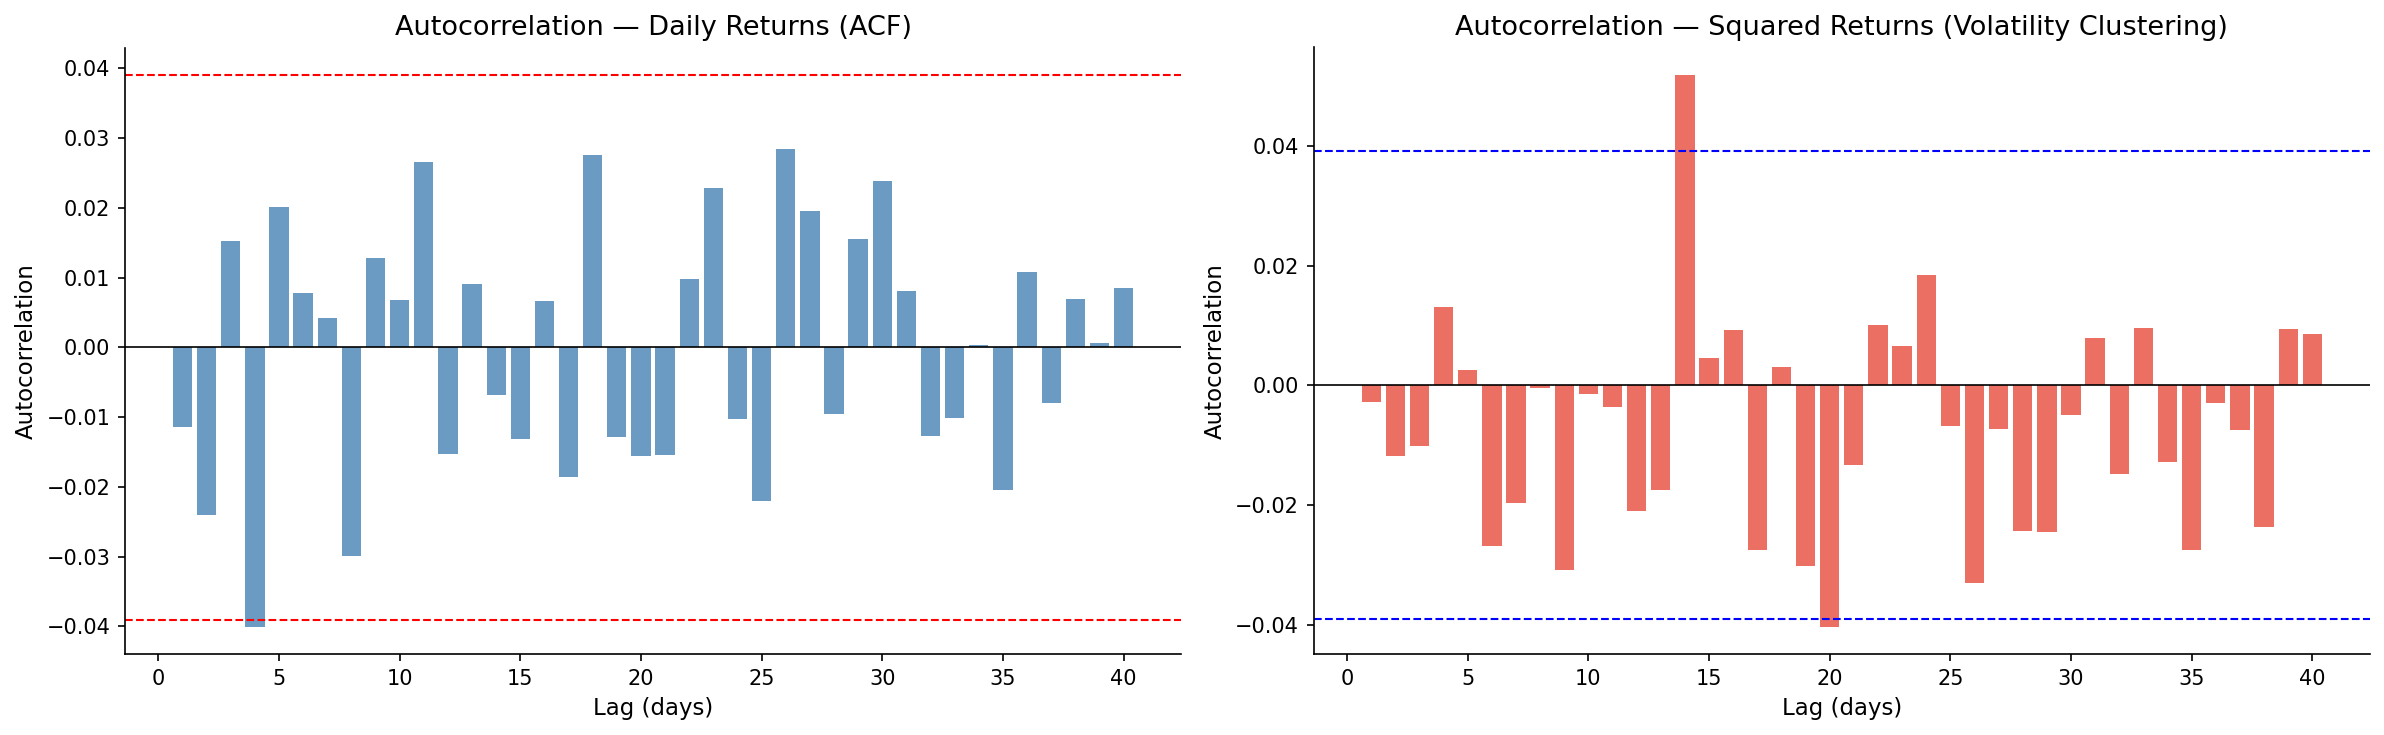

✅ Saved: autocorrelation.png


In [21]:
# ─── Lag autocorrelation ─────────────────────────────────────────────────────
from pandas.plotting import autocorrelation_plot

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ACF manual
lags = 40
ret_clean = df['Daily_Return'].dropna().values
acf_vals  = [np.corrcoef(ret_clean[:-lag], ret_clean[lag:])[0,1] for lag in range(1, lags+1)]
axes[0].bar(range(1, lags+1), acf_vals, color='steelblue', alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].axhline(1.96/np.sqrt(len(ret_clean)),  color='red', linestyle='--', linewidth=1)
axes[0].axhline(-1.96/np.sqrt(len(ret_clean)), color='red', linestyle='--', linewidth=1)
axes[0].set_title("Autocorrelation — Daily Returns (ACF)")
axes[0].set_xlabel("Lag (days)")
axes[0].set_ylabel("Autocorrelation")

# Squared returns (volatility clustering proxy)
acf_sq = [np.corrcoef(ret_clean[:-lag]**2, ret_clean[lag:]**2)[0,1] for lag in range(1, lags+1)]
axes[1].bar(range(1, lags+1), acf_sq, color='#e74c3c', alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].axhline(1.96/np.sqrt(len(ret_clean)),  color='blue', linestyle='--', linewidth=1)
axes[1].axhline(-1.96/np.sqrt(len(ret_clean)), color='blue', linestyle='--', linewidth=1)
axes[1].set_title("Autocorrelation — Squared Returns (Volatility Clustering)")
axes[1].set_xlabel("Lag (days)")
axes[1].set_ylabel("Autocorrelation")

plt.tight_layout()
plt.savefig(f"{DIRS['viz_eda']}/autocorrelation.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: autocorrelation.png")

| Visualization         | Purpose                         | Key Observation                                 | Interpretation                            | Conclusion                             |
| --------------------- | ------------------------------- | ----------------------------------------------- | ----------------------------------------- | -------------------------------------- |
| ACF — Daily Returns   | Check predictability in returns | Most values near zero; within confidence bounds | No significant autocorrelation in returns | Returns are random (no predictability) |
| ACF — Squared Returns | Detect volatility clustering    | Some spikes beyond confidence limits            | Volatility shows persistence over time    | Presence of volatility clustering      |


##  Section 10 — Interactive EDA Dashboard (Plotly)

In [22]:
fig_eda = make_subplots(
    rows=3, cols=2,
    subplot_titles=[
        "Close Price + MA-20 + MA-50 + MA-200",
        "Daily Volume (Millions)",
        "Daily Returns (%)",
        "Cumulative Return (%)",
        "30-Day Annualised Volatility (%)",
        "Return Distribution (Histogram)",
    ],
    vertical_spacing=0.10,
    horizontal_spacing=0.08,
)

# 1. Close + MAs
fig_eda.add_trace(go.Scatter(x=df['Date'], y=df['Close'],   name='Close',  line=dict(color='black',   width=1)), row=1, col=1)
fig_eda.add_trace(go.Scatter(x=df['Date'], y=df['MA_20'],   name='MA-20',  line=dict(color='blue',    width=1, dash='dot')), row=1, col=1)
fig_eda.add_trace(go.Scatter(x=df['Date'], y=df['MA_50'],   name='MA-50',  line=dict(color='orange',  width=1, dash='dash')), row=1, col=1)
fig_eda.add_trace(go.Scatter(x=df['Date'], y=df['MA_200'],  name='MA-200', line=dict(color='red',     width=1.5)), row=1, col=1)

# 2. Volume
fig_eda.add_trace(go.Bar(x=df['Date'], y=df['Volume']/1e6, name='Volume', marker_color='steelblue', opacity=0.6), row=1, col=2)

# 3. Daily Returns
ret_c = ['green' if r > 0 else 'red' for r in df['Daily_Return'].fillna(0)]
fig_eda.add_trace(go.Bar(x=df['Date'], y=df['Daily_Return'].fillna(0), name='Return', marker_color=ret_c, opacity=0.7), row=2, col=1)

# 4. Cumulative Return
cum_r = (1 + df['Daily_Return'].fillna(0)/100).cumprod() - 1
fig_eda.add_trace(go.Scatter(x=df['Date'], y=cum_r*100, name='Cum Return', fill='tozeroy',
                              line=dict(color='purple', width=1.5)), row=2, col=2)

# 5. Annualised Vol
fig_eda.add_trace(go.Scatter(x=df['Date'], y=df['Vol_30d']*100, name='Ann. Vol',
                              line=dict(color='crimson', width=1), fill='tozeroy'), row=3, col=1)

# 6. Return histogram
fig_eda.add_trace(go.Histogram(x=df['Daily_Return'].dropna(), name='Return Dist',
                                nbinsx=80, marker_color='#3498db', opacity=0.75), row=3, col=2)

fig_eda.update_layout(
    height=1000, width=1200,
    title_text="<b>AAPL Synthesized Data — EDA Dashboard</b>",
    title_font_size=18,
    showlegend=True,
    template='plotly_white',
)
fig_eda.write_html(f"{DIRS['viz_dashboard']}/eda_dashboard.html")
fig_eda.show()
print("✅ EDA dashboard saved as HTML")

✅ EDA dashboard saved as HTML


| Component               | Purpose                         | Key Observation                        | Interpretation                     | Conclusion                            |
| ----------------------- | ------------------------------- | -------------------------------------- | ---------------------------------- | ------------------------------------- |
| Close + Moving Averages | Visualize trend & momentum      | Price above MA-200; MAs aligned upward | Strong bullish trend with momentum | Trend-following behavior confirmed    |
| Volume (Bar)            | Track trading activity          | Irregular spikes across timeline       | Event-driven trading behavior      | Volume not consistent but impactful   |
| Daily Returns           | Observe short-term fluctuations | Frequent ups & downs around zero       | High short-term volatility         | Market is noisy in short term         |
| Cumulative Return       | Measure overall performance     | Exponential growth over time           | Compounding drives returns         | Strong long-term investment potential |
| Annualised Volatility   | Assess risk dynamics            | Fluctuating volatility with spikes     | Risk varies over time              | Market risk is dynamic                |
| Return Distribution     | Understand return behavior      | Approximately normal distribution      | Balanced gains & losses            | Suitable for statistical modeling     |


#Overall Insight

1. Strong long-term uptrend with consistent momentum

2. Short-term volatility present but balanced

3. Risk and volume are dynamic (event-driven)

4. Returns distribution supports predictive modeling

##  Section 11 — Feature Engineering: Technical Indicators
**12 features total:** OHLCV (5) + RSI-14 · MACD · BB_Width · EMA-20 · ATR-14 · OBV · Stoch_%K

In [23]:
# ─── RSI-14 ─────────────────────────────────────────────────────────────────
df['RSI_14'] = ta.momentum.RSIIndicator(close=df['Close'], window=14).rsi()

# ─── MACD ────────────────────────────────────────────────────────────────────
macd_obj    = ta.trend.MACD(close=df['Close'], window_slow=26, window_fast=12, window_sign=9)
df['MACD']  = macd_obj.macd()

# ─── Bollinger Band Width ─────────────────────────────────────────────────────
bb_obj        = ta.volatility.BollingerBands(close=df['Close'], window=20, window_dev=2)
df['BB_Width'] = bb_obj.bollinger_wband()

# ─── EMA-20 ──────────────────────────────────────────────────────────────────
df['EMA_20'] = ta.trend.EMAIndicator(close=df['Close'], window=20).ema_indicator()

# ─── ATR-14 (Average True Range — volatility) ────────────────────────────────
df['ATR_14'] = ta.volatility.AverageTrueRange(
    high=df['High'], low=df['Low'], close=df['Close'], window=14).average_true_range()

# ─── OBV (On-Balance Volume — volume trend) ───────────────────────────────────
df['OBV'] = ta.volume.OnBalanceVolumeIndicator(
    close=df['Close'], volume=df['Volume']).on_balance_volume()

# ─── Stochastic %K ───────────────────────────────────────────────────────────
df['Stoch_K'] = ta.momentum.StochasticOscillator(
    high=df['High'], low=df['Low'], close=df['Close'], window=14, smooth_window=3).stoch()

# ─── Drop NaN rows from indicator look-back windows ──────────────────────────
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Features added | Dataset shape: {df.shape}")
print(f"   Technical indicators : RSI_14, MACD, BB_Width, EMA_20, ATR_14, OBV, Stoch_K")

✅ Features added | Dataset shape: (2321, 23)
   Technical indicators : RSI_14, MACD, BB_Width, EMA_20, ATR_14, OBV, Stoch_K


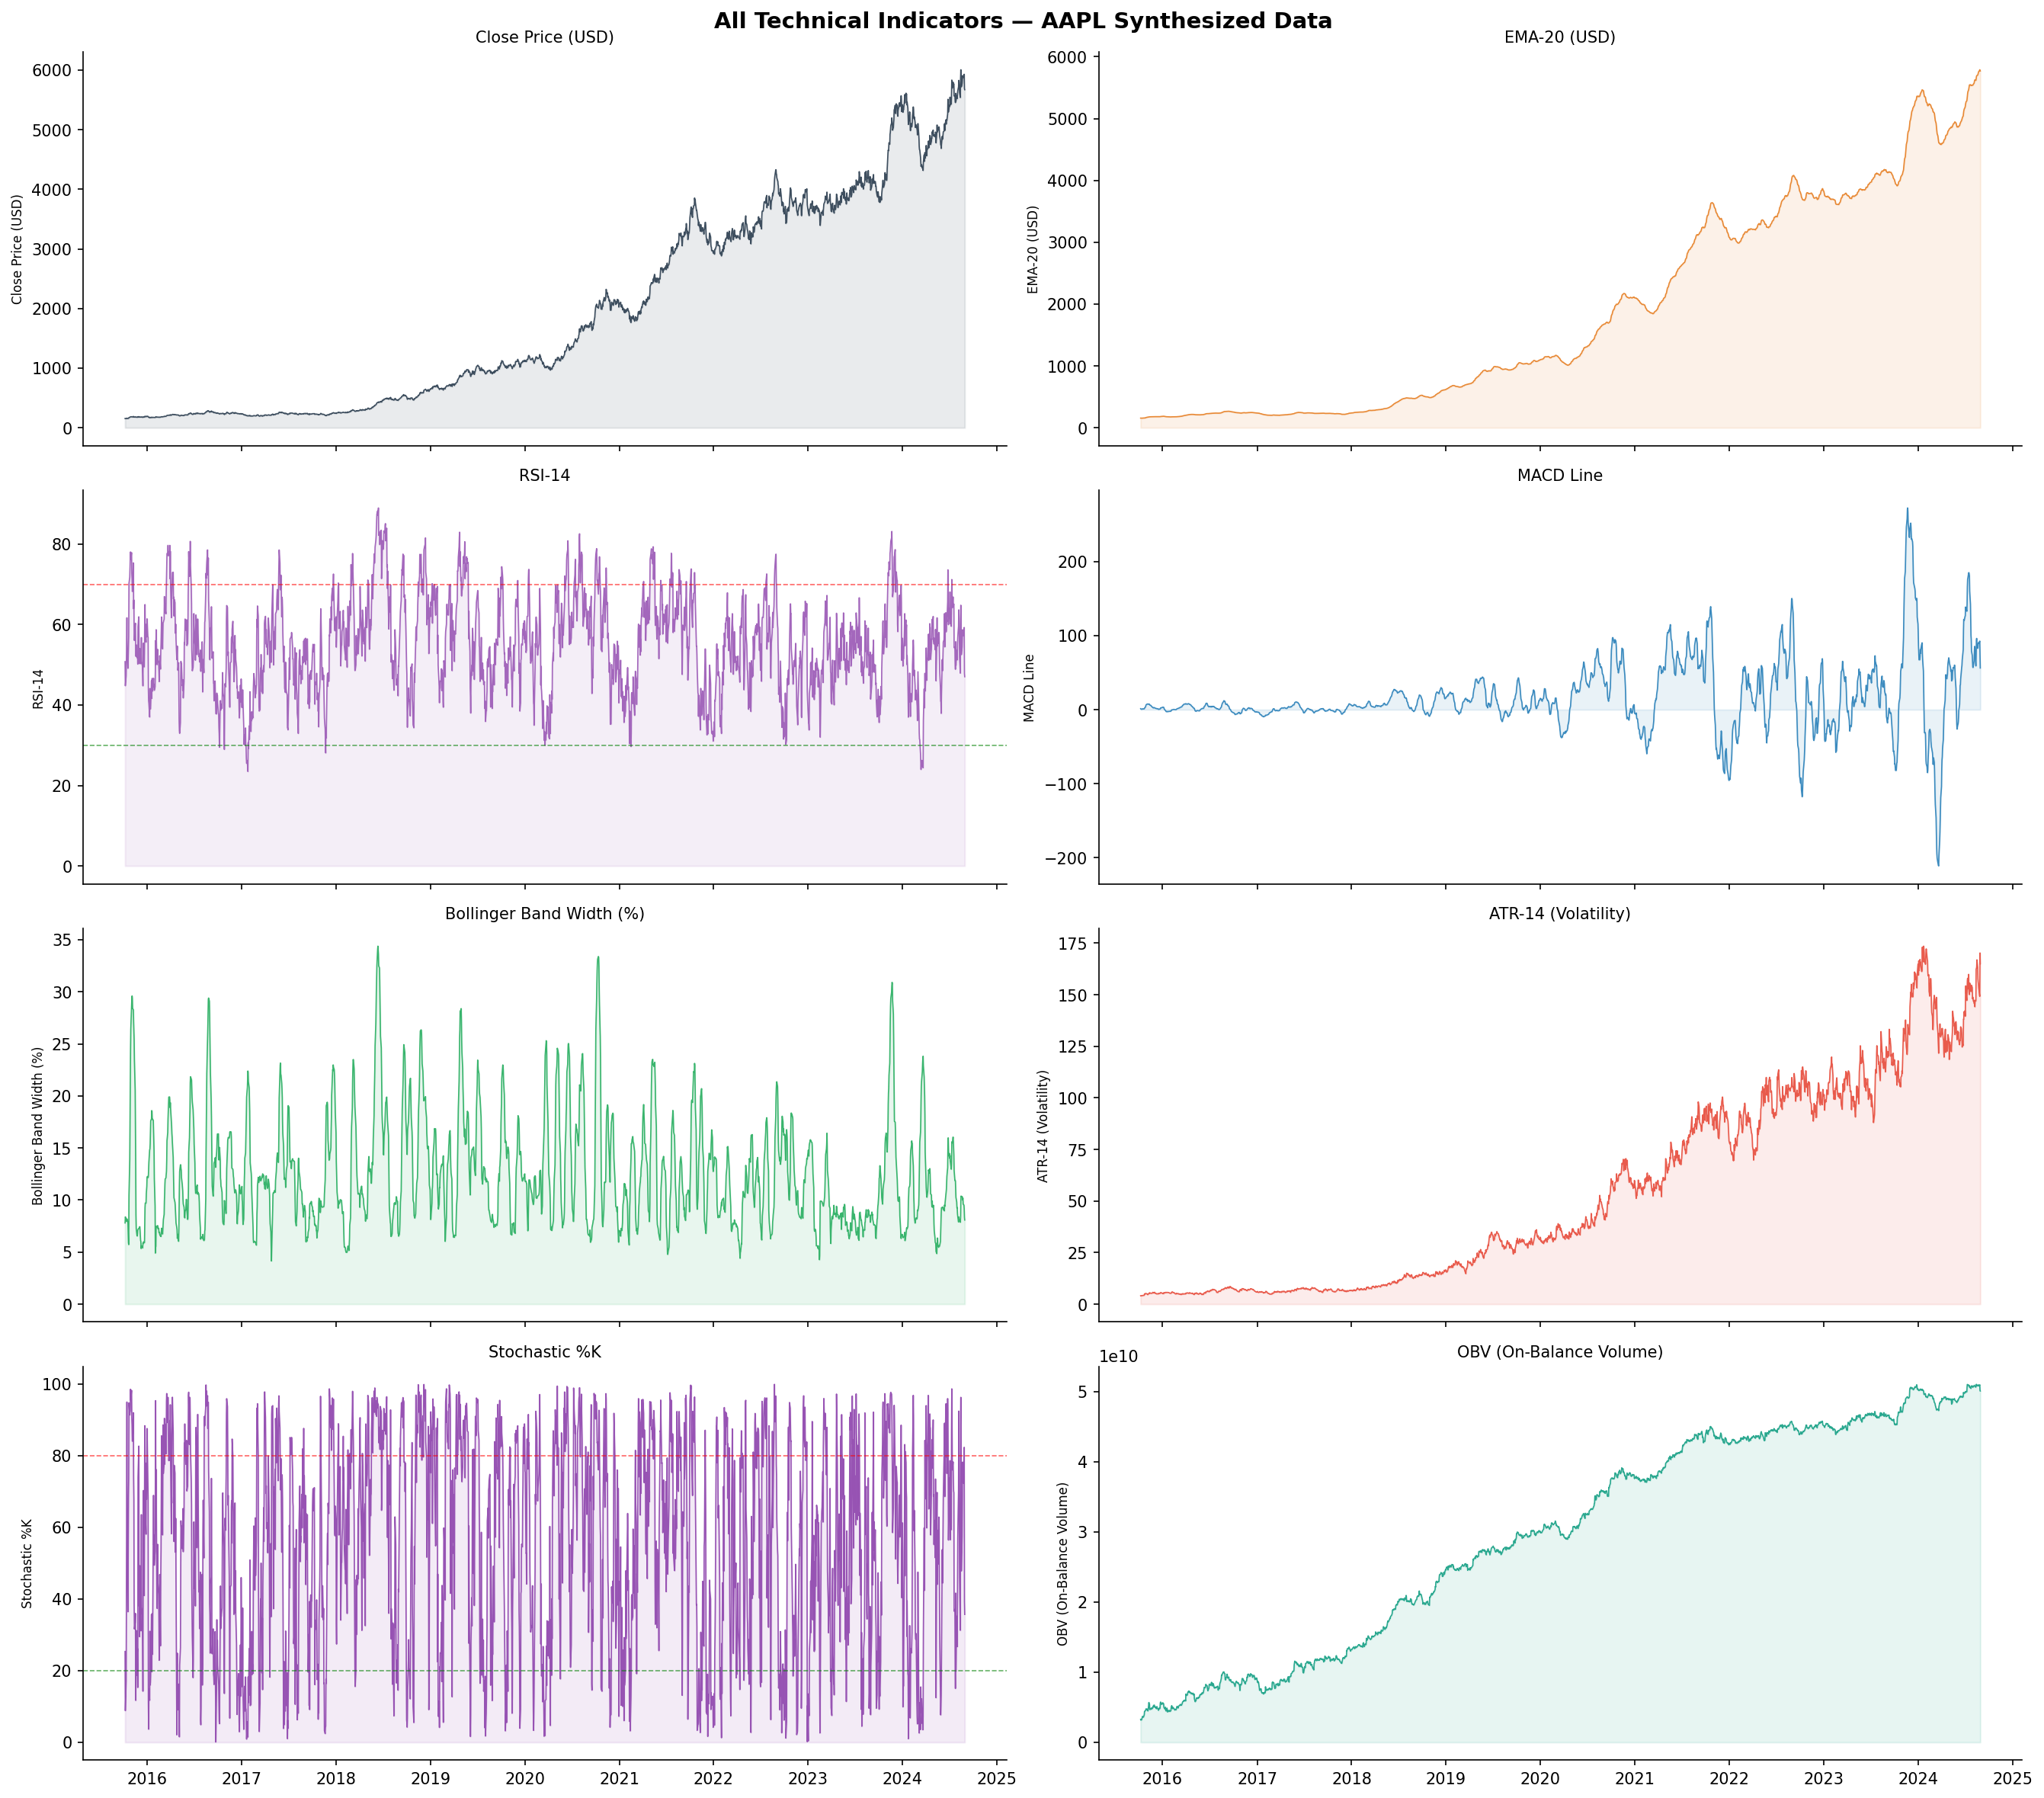

✅ Saved: technical_indicators.png


In [24]:
# ─── Indicator Visualisations ─────────────────────────────────────────────────
fig, axes = plt.subplots(4, 2, figsize=(18, 16), sharex=True)

plot_cfg = [
    ('Close',    '#2c3e50',  'Close Price (USD)',         False),
    ('EMA_20',   '#e67e22',  'EMA-20 (USD)',              False),
    ('RSI_14',   '#9b59b6',  'RSI-14',                   True),
    ('MACD',     '#2980b9',  'MACD Line',                False),
    ('BB_Width', '#27ae60',  'Bollinger Band Width (%)', False),
    ('ATR_14',   '#e74c3c',  'ATR-14 (Volatility)',      False),
    ('Stoch_K',  '#8e44ad',  'Stochastic %K',            True),
    ('OBV',      '#16a085',  'OBV (On-Balance Volume)',  False),
]

for ax, (col, color, ylabel, ref_lines) in zip(axes.flatten(), plot_cfg):
    ax.plot(df['Date'], df[col], color=color, linewidth=0.8, alpha=0.9)
    ax.fill_between(df['Date'], df[col], alpha=0.1, color=color)
    ax.set_title(ylabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=8)
    if ref_lines and col == 'RSI_14':
        ax.axhline(70, color='red',   linestyle='--', alpha=0.6, linewidth=0.8)
        ax.axhline(30, color='green', linestyle='--', alpha=0.6, linewidth=0.8)
    if ref_lines and col == 'Stoch_K':
        ax.axhline(80, color='red',   linestyle='--', alpha=0.6, linewidth=0.8)
        ax.axhline(20, color='green', linestyle='--', alpha=0.6, linewidth=0.8)

plt.suptitle("All Technical Indicators — AAPL Synthesized Data", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['viz_eda']}/technical_indicators.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: technical_indicators.png")

| Indicator               | Purpose                                  | Key Observation                                      | Interpretation                              | Conclusion                              |
| ----------------------- | ---------------------------------------- | ---------------------------------------------------- | ------------------------------------------- | --------------------------------------- |
| Close Price             | Baseline price trend                     | Strong upward movement over time                     | Consistent long-term growth                 | Confirms bullish market                 |
| EMA-20                  | Short-term trend indicator               | Closely follows price movements                      | Captures short-term momentum shifts         | Useful for trend-following signals      |
| RSI-14                  | Identify overbought/oversold             | Frequent movement between 30–70; occasional extremes | Market cycles between momentum phases       | Good for entry/exit timing              |
| MACD                    | Detect trend reversals & momentum        | Oscillates around zero with spikes                   | Indicates momentum shifts and trend changes | Useful for crossover strategies         |
| Bollinger Band Width    | Measure volatility expansion/contraction | Periodic spikes in width                             | Volatility increases during major moves     | Confirms volatility clustering          |
| ATR-14                  | Quantify market volatility               | Increasing trend with spikes                         | Rising volatility over time                 | Market risk is increasing               |
| Stochastic %K           | Identify overbought/oversold zones       | Frequent crossings of 20 & 80 levels                 | High short-term price fluctuations          | Suitable for short-term trading signals |
| OBV (On-Balance Volume) | Track volume flow with price             | Strong upward trend                                  | Volume supports price increase              | Confirms bullish strength               |


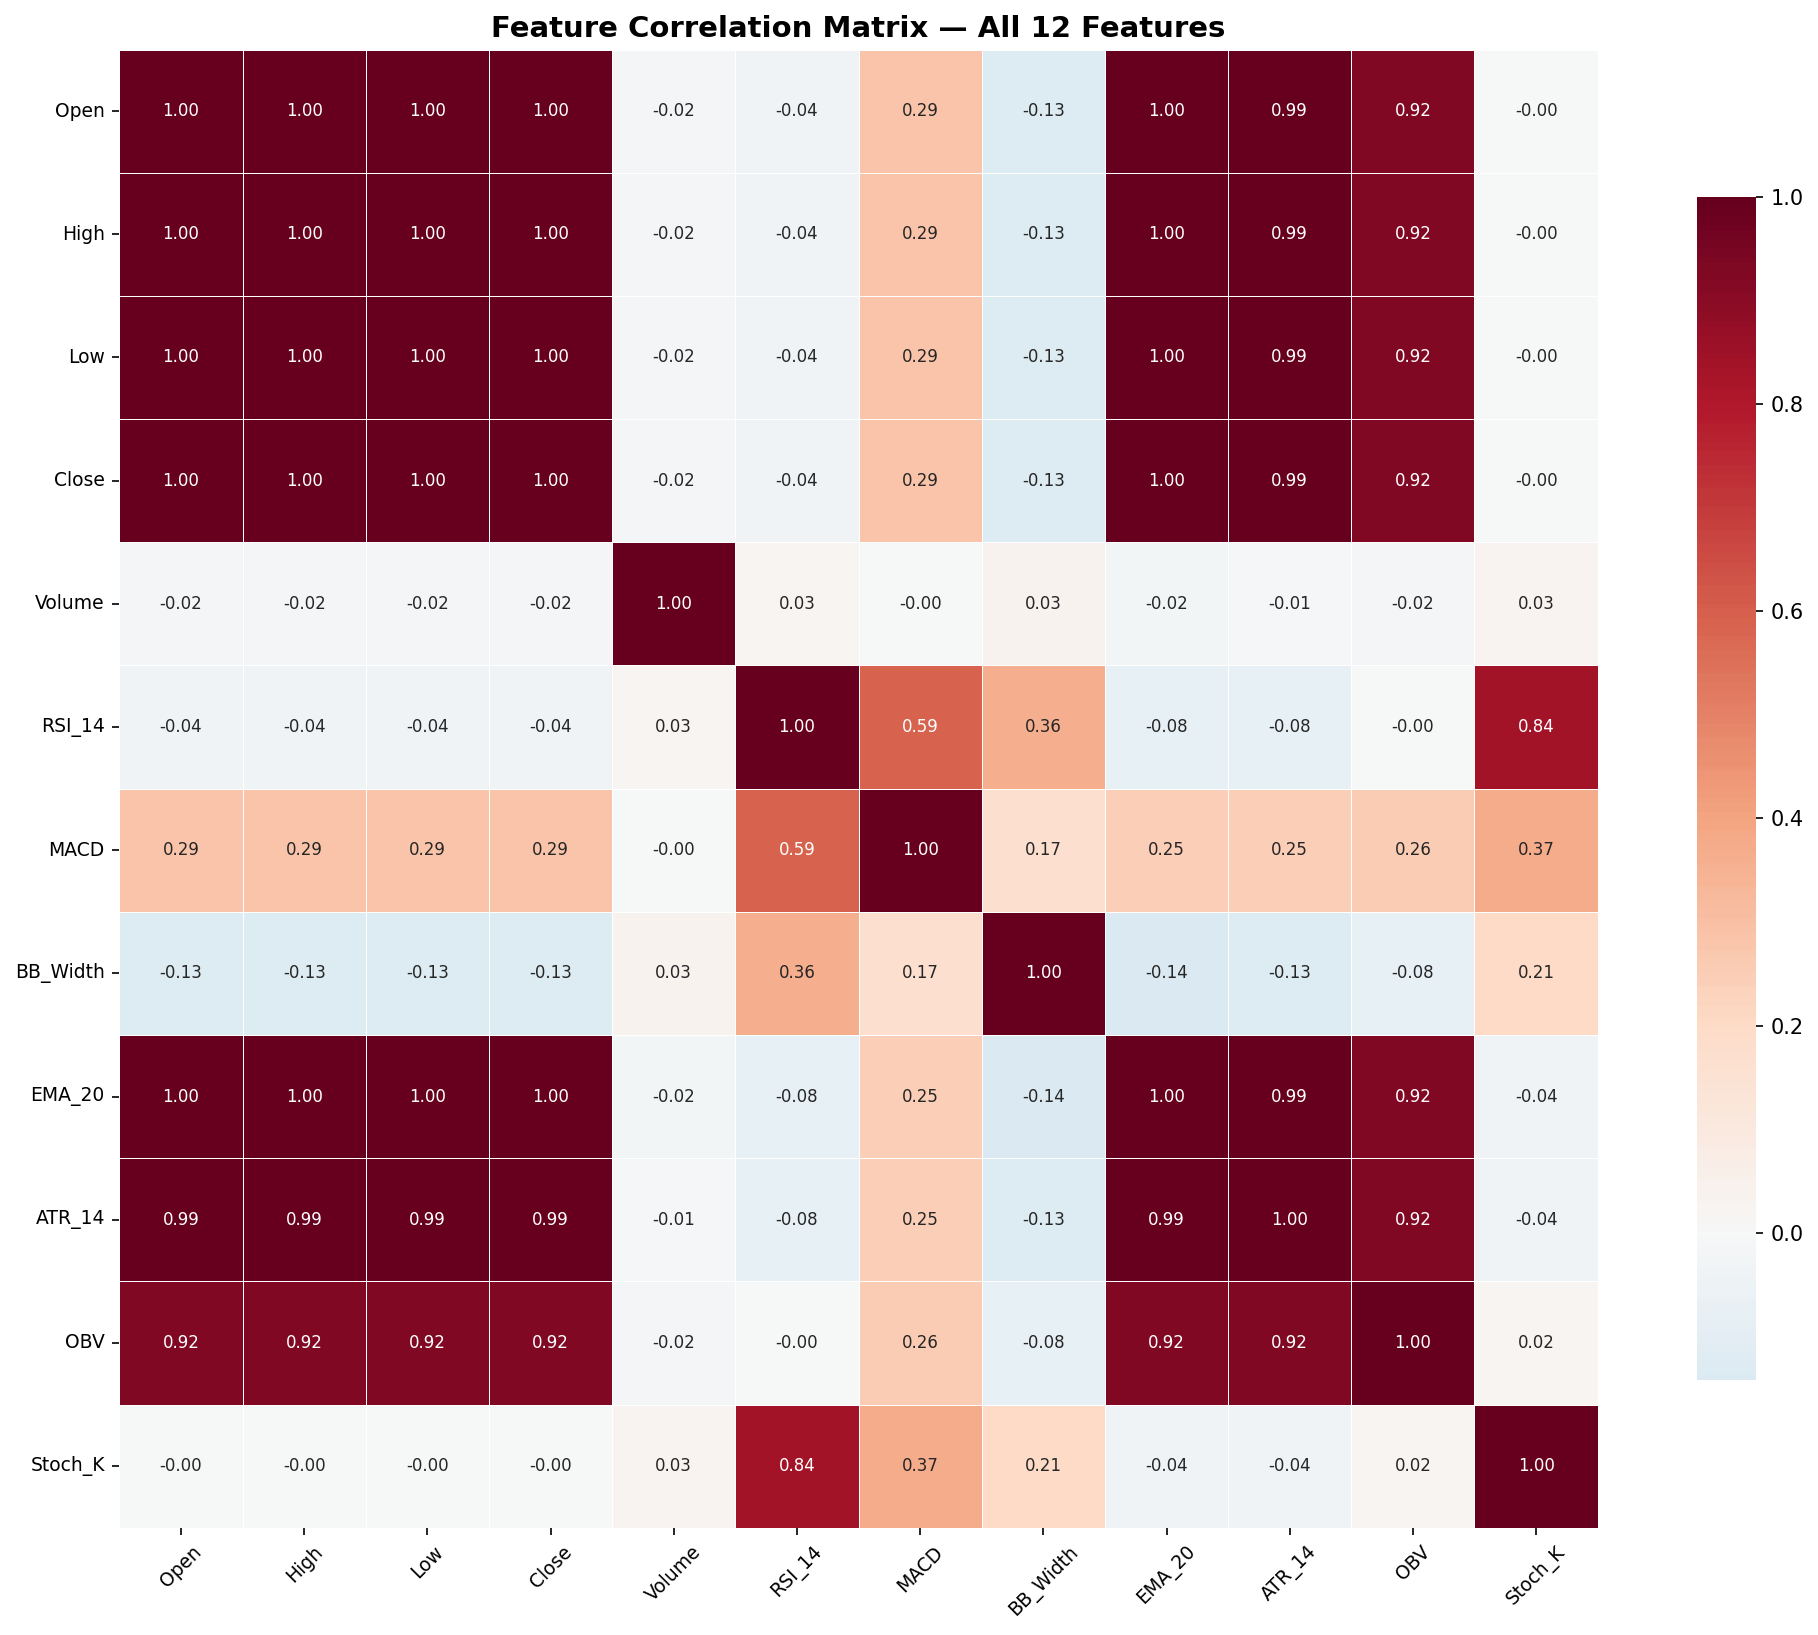

✅ Saved: feature_correlation_full.png | Total features: 12


In [25]:
# ─── Post-Engineering Correlation Heatmap ─────────────────────────────────────
FEATURE_NAMES = ['Open','High','Low','Close','Volume',
                 'RSI_14','MACD','BB_Width','EMA_20','ATR_14','OBV','Stoch_K']
N_FEATURES   = len(FEATURE_NAMES)
CLOSE_IDX    = FEATURE_NAMES.index('Close')
WINDOW_SIZE  = 60

fig, ax = plt.subplots(figsize=(14, 11))
corr_full = df[FEATURE_NAMES].corr()
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True,
            linewidths=0.4, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
ax.set_title("Feature Correlation Matrix — All 12 Features", fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig(f"{DIRS['viz_eda']}/feature_correlation_full.png", bbox_inches='tight', dpi=150)
plt.show()
print(f"✅ Saved: feature_correlation_full.png | Total features: {N_FEATURES}")

In [26]:
# ─── Save processed dataset ───────────────────────────────────────────────────
df[['Date'] + FEATURE_NAMES].to_csv(
    f"{DIRS['data_processed']}/AAPL_processed.csv", index=False)
print("✅ Processed dataset saved to data/processed/")

✅ Processed dataset saved to data/processed/


##  Section 12 — Scaling & Sequence Creation

In [27]:
features_df     = df[FEATURE_NAMES].copy()
scaler          = MinMaxScaler()
features_scaled = scaler.fit_transform(features_df)
df_scaled       = pd.DataFrame(features_scaled, columns=FEATURE_NAMES)

# ─── Sequences ────────────────────────────────────────────────────────────────
X, y = [], []
for i in range(WINDOW_SIZE, len(df_scaled)):
    X.append(df_scaled.iloc[i - WINDOW_SIZE:i].values)
    y.append(df_scaled.iloc[i, CLOSE_IDX])

X = np.array(X)
y = np.array(y)

print(f"✅ Sequence shape : X={X.shape}  y={y.shape}")
print(f"   Window size    : {WINDOW_SIZE} days")
print(f"   Feature count  : {N_FEATURES}")

✅ Sequence shape : X=(2261, 60, 12)  y=(2261,)
   Window size    : 60 days
   Feature count  : 12


In [28]:
# ─── Train / Test Split (80/20, time-ordered) ────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0],  -1)

split_idx = len(X_train) + WINDOW_SIZE
train_dates = df['Date'].iloc[WINDOW_SIZE : split_idx].values
test_dates  = df['Date'].iloc[split_idx:].values

print(f"  Train: {X_train.shape}  ({len(train_dates)} days)")
print(f"  Test : {X_test.shape}   ({len(test_dates)} days)")
print(f"  Train period: {pd.to_datetime(train_dates[0]).date()} → {pd.to_datetime(train_dates[-1]).date()}")
print(f"  Test  period: {pd.to_datetime(test_dates[0]).date()}  → {pd.to_datetime(test_dates[-1]).date()}")

  Train: (1808, 60, 12)  (1808 days)
  Test : (453, 60, 12)   (453 days)
  Train period: 2015-12-31 → 2022-12-05
  Test  period: 2022-12-06  → 2024-08-29


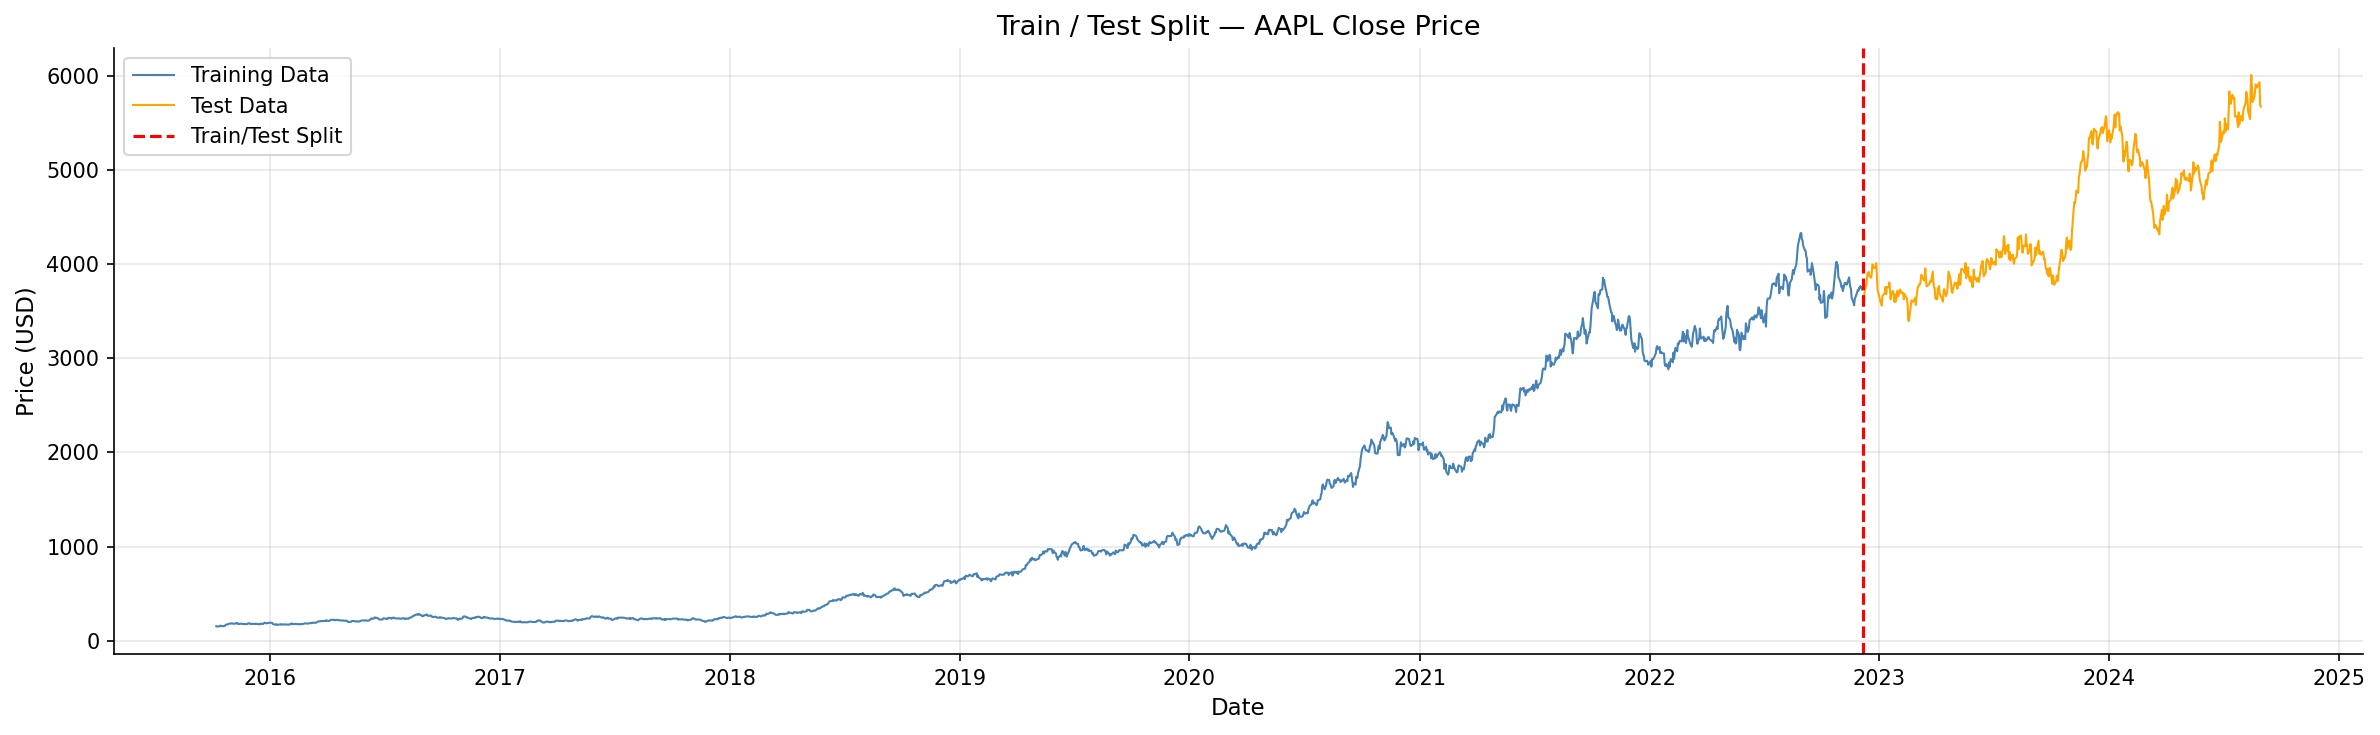

✅ Saved: train_test_split.png


In [29]:
# ─── Train/Test Split Visualisation ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df['Date'].iloc[:split_idx], df['Close'].iloc[:split_idx],
        color='steelblue', linewidth=1, label='Training Data')
ax.plot(df['Date'].iloc[split_idx:], df['Close'].iloc[split_idx:],
        color='orange', linewidth=1, label='Test Data')
ax.axvline(df['Date'].iloc[split_idx], color='red', linestyle='--',
           linewidth=1.5, label='Train/Test Split')
ax.set_title("Train / Test Split — AAPL Close Price", fontsize=13)
ax.set_ylabel("Price (USD)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DIRS['viz_models']}/train_test_split.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: train_test_split.png")

##  Section 13 — Model 1: Stacked LSTM + Temporal Attention
Architecture: Input → LSTM(128) → Dropout → LSTM(64) → Dropout → TimeAttention → Dense(64) → Dense(32) → Output

In [30]:
class TimeAttention(Layer):
    """Trainable soft-attention over the time dimension.
    Assigns a learned importance weight to each of the 60 timesteps."""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(
            name='att_weight', shape=(input_shape[-1], 1),
            initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(
            name='att_bias', shape=(input_shape[1], 1),
            initializer='zeros', trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        e       = K.tanh(K.dot(inputs, self.W) + self.b)   # (batch, T, 1)
        a       = K.softmax(e, axis=1)                      # attention weights
        context = K.sum(inputs * a, axis=1)                 # (batch, features)
        return context, a


def build_lstm_attention(window, n_features):
    inp       = Input(shape=(window, n_features))
    x         = LSTM(128, return_sequences=True)(inp)
    x         = Dropout(0.2)(x)
    x         = LSTM(64,  return_sequences=True)(x)
    x         = Dropout(0.2)(x)
    context, att_w = TimeAttention()(x)
    x         = Dense(64, activation='relu')(context)
    x         = Dropout(0.1)(x)
    x         = Dense(32, activation='relu')(x)
    out       = Dense(1)(x)
    m         = Model(inputs=inp, outputs=out)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
    return m, att_w

lstm_model, att_weights_tensor = build_lstm_attention(WINDOW_SIZE, N_FEATURES)
lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 60, 128)        │        72,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_attention (TimeAttention)  │ [(None, 64), (None,    │           124 │
│                                 │ 60, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,997 (499.99 KB)

 Trainable params: 127,997 (499.99 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
CB = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1),
]

lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=80, batch_size=32,
    callbacks=CB, verbose=1,
)

Epoch 1/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 96ms/step - loss: 0.0038 - val_loss: 0.0264 - learning_rate: 0.0010
Epoch 2/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 7.3052e-04 - val_loss: 0.0134 - learning_rate: 0.0010
Epoch 3/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - loss: 5.9059e-04 - val_loss: 0.0168 - learning_rate: 0.0010
Epoch 4/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 6.6319e-04 - val_loss: 0.0224 - learning_rate: 0.0010
Epoch 5/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - loss: 6.3251e-04 - val_loss: 0.0188 - learning_rate: 0.0010
Epoch 6/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 5.4547e-04 - val_loss: 0.0228 - learning_rate: 0.0010
Epoch 7/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - loss: 4.8879e-04 - val_loss: 0.0158 - learning_rate: 0.0010
Epoch 8/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - loss: 4.4154e-04 - val_loss: 0.0090 - learning_rate: 0.0010
Epoch 9/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - loss: 4.1774e-04 - val_loss: 0.0150 - learni

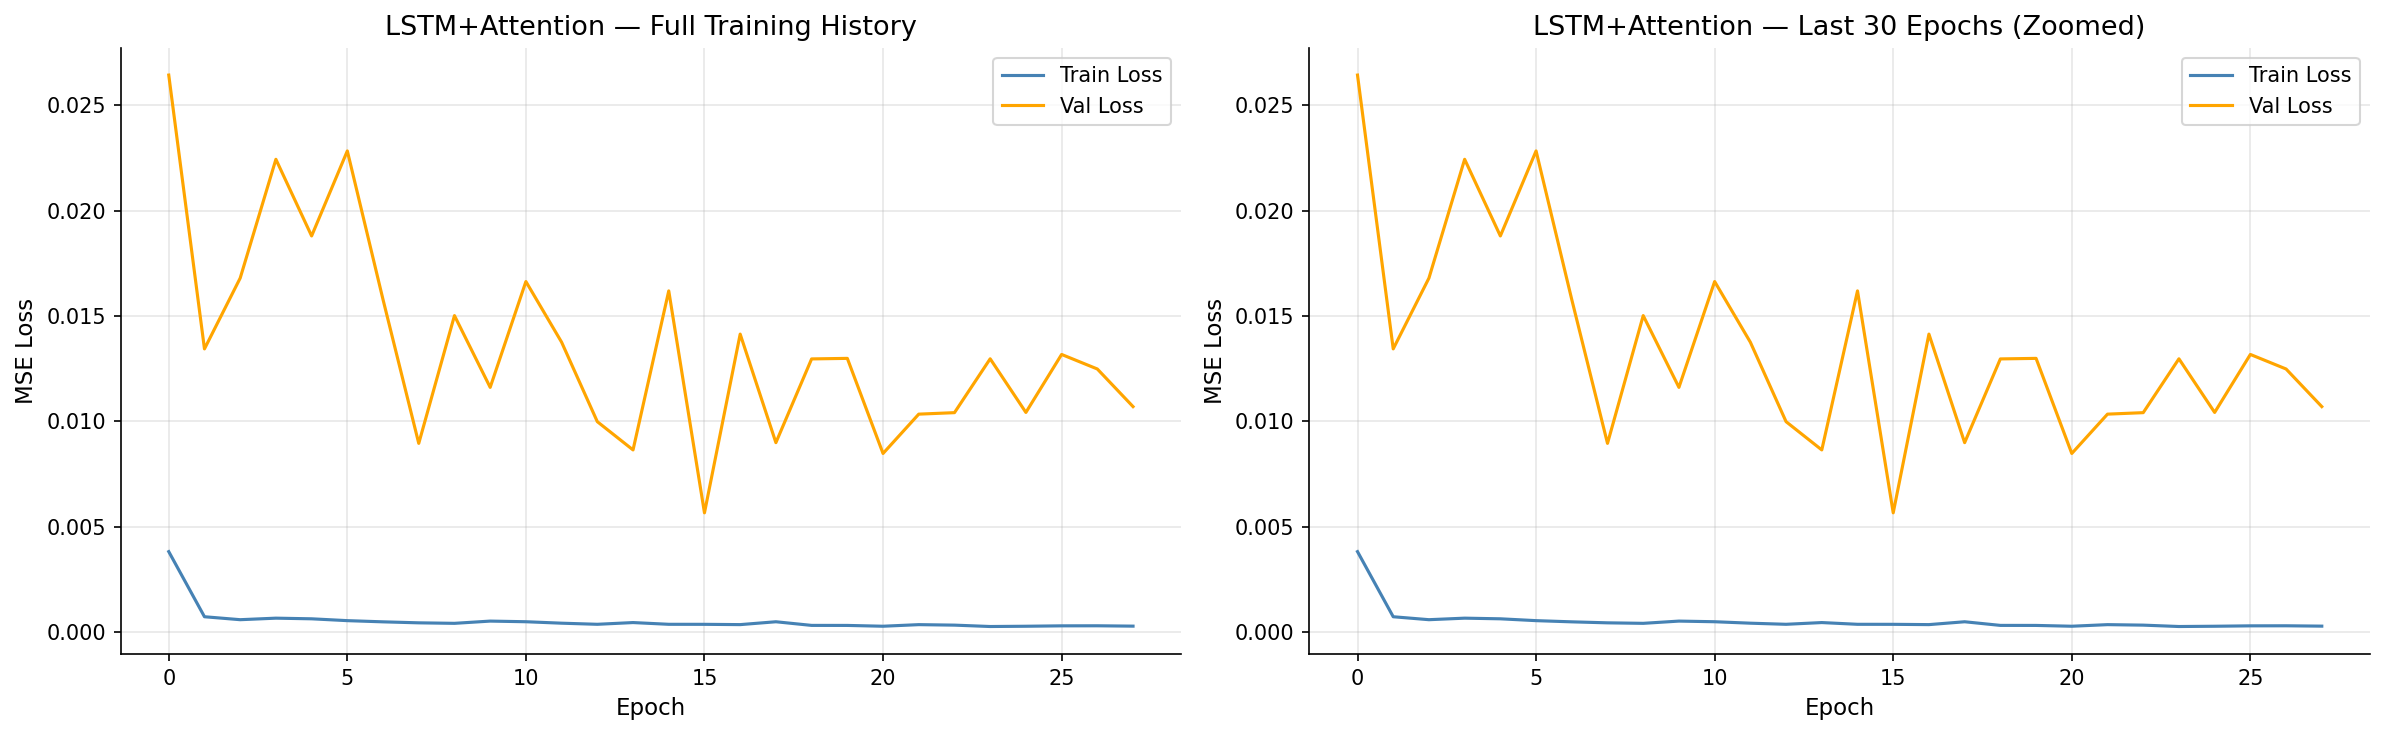

✅ Saved: lstm_training_curves.png


In [32]:
# ─── Training Curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, key, title in zip(axes,
    [('loss','val_loss'), ('loss','val_loss')],
    ['Full Training History', 'Last 30 Epochs (Zoomed)']):
    n = len(lstm_history.history['loss'])
    s = 0 if ax == axes[0] else max(0, n-30)
    ax.plot(lstm_history.history['loss'][s:],     label='Train Loss', color='steelblue')
    ax.plot(lstm_history.history['val_loss'][s:], label='Val Loss',   color='orange')
    ax.set_title(f"LSTM+Attention — {title}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{DIRS['viz_models']}/lstm_training_curves.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: lstm_training_curves.png")

## Section 14 — Model 2: Stacked GRU

In [33]:
def build_gru(window, n_features):
    m = Sequential([
        Input(shape=(window, n_features)),
        GRU(128, return_sequences=True),
        Dropout(0.2),
        GRU(64,  return_sequences=False),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1),
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

gru_model = build_gru(WINDOW_SIZE, N_FEATURES)

gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=80, batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
               ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)],
    verbose=1,
)

Epoch 1/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - loss: 0.0053 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 2/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.0011 - val_loss: 0.0091 - learning_rate: 0.0010
Epoch 3/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 91ms/step - loss: 9.1307e-04 - val_loss: 0.0022 - learning_rate: 0.0010
Epoch 4/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - loss: 8.4958e-04 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 5/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 6.0696e-04 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 6/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - loss: 5.5187e-04 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 7/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 5.2125e-04 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 8/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - loss: 4.7993e-04 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 9/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 3.6623e-04
Epoch 9: ReduceLROnPlateau reducin

##  Section 15 — Model 3: Bidirectional LSTM

In [34]:
def build_bilstm(window, n_features):
    m = Sequential([
        Input(shape=(window, n_features)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.2),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1),
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

bilstm_model = build_bilstm(WINDOW_SIZE, N_FEATURES)

bilstm_history = bilstm_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=80, batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True, verbose=1),
               ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1)],
    verbose=1,
)

Epoch 1/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 15s 173ms/step - loss: 0.0040 - val_loss: 0.0135 - learning_rate: 0.0010
Epoch 2/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - loss: 0.0011 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 3/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 182ms/step - loss: 7.7929e-04 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 4/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 182ms/step - loss: 5.4844e-04 - val_loss: 0.0109 - learning_rate: 0.0010
Epoch 5/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 183ms/step - loss: 4.5806e-04 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 6/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 20s 166ms/step - loss: 4.9706e-04 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 7/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 11s 182ms/step - loss: 5.6455e-04 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 8/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 184ms/step - loss: 4.6978e-04 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 9/80
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 178ms/step - loss: 3.1895e-04 - val_loss: 0.00

## Section 16 — Model 4: XGBoost

In [35]:
xgb_model = XGBRegressor(
    n_estimators    = 500,
    learning_rate   = 0.03,
    max_depth       = 5,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    reg_alpha       = 0.1,
    reg_lambda      = 1.0,
    random_state    = 42,
    n_jobs          = -1,
    verbosity       = 0,
)
xgb_model.fit(X_train_flat, y_train,
              eval_set=[(X_test_flat, y_test)],
              verbose=100)
print("✅ XGBoost training complete.")

[0]	validation_0-rmse:0.54171
[100]	validation_0-rmse:0.16296
[200]	validation_0-rmse:0.14106
[300]	validation_0-rmse:0.13964
[400]	validation_0-rmse:0.13930
[499]	validation_0-rmse:0.13916
✅ XGBoost training complete.


##  Section 17 — Predictions & Evaluation Metrics

In [36]:
def inverse_close(scaled_preds, scaled_actuals):
    dp = np.zeros((len(scaled_preds),  N_FEATURES))
    da = np.zeros((len(scaled_actuals), N_FEATURES))
    dp[:, CLOSE_IDX] = scaled_preds.flatten()
    da[:, CLOSE_IDX] = scaled_actuals.flatten()
    return (scaler.inverse_transform(dp)[:, CLOSE_IDX],
            scaler.inverse_transform(da)[:, CLOSE_IDX])


def metrics(actual, pred, name):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    r2   = 1 - np.sum((actual-pred)**2) / np.sum((actual-np.mean(actual))**2)
    da   = np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(pred))) * 100
    return {'Model': name, 'RMSE': round(rmse,4), 'MAE': round(mae,4),
            'MAPE(%)': round(mape,4), 'R²': round(r2,4), 'Dir.Acc(%)': round(da,2)}

# ─── Generate predictions ────────────────────────────────────────────────────
lstm_pred_s   = lstm_model.predict(X_test,  verbose=0)
gru_pred_s    = gru_model.predict(X_test,   verbose=0)
bilstm_pred_s = bilstm_model.predict(X_test,verbose=0)
xgb_pred_s    = xgb_model.predict(X_test_flat).reshape(-1, 1)

lstm_pred,   y_test_inv = inverse_close(lstm_pred_s,   y_test)
gru_pred,    _          = inverse_close(gru_pred_s,    y_test)
bilstm_pred, _          = inverse_close(bilstm_pred_s, y_test)
xgb_pred,    _          = inverse_close(xgb_pred_s,    y_test)

print("✅ All predictions generated")

✅ All predictions generated


In [37]:
# ─── Metrics Table ────────────────────────────────────────────────────────────
metrics_list = [
    metrics(y_test_inv, lstm_pred,   'LSTM + Attention'),
    metrics(y_test_inv, gru_pred,    'GRU'),
    metrics(y_test_inv, bilstm_pred, 'Bi-LSTM'),
    metrics(y_test_inv, xgb_pred,    'XGBoost'),
]
metrics_df = pd.DataFrame(metrics_list).set_index('Model')

print("=" * 70)
print("  MODEL PERFORMANCE COMPARISON")
print("=" * 70)
print(metrics_df.to_string())
print("=" * 70)
metrics_df

  MODEL PERFORMANCE COMPARISON
                      RMSE       MAE  MAPE(%)      R²  Dir.Acc(%)
Model                                                            
LSTM + Attention  440.4633  313.2473   6.2972  0.6046       46.68
GRU               274.2030  214.4727   4.4484  0.8468       44.47
Bi-LSTM           219.5152  177.8191   3.8452  0.9018       46.24
XGBoost           814.7012  566.9433  11.0168 -0.3527       49.12


,RMSE,MAE,MAPE(%),R²,Dir.Acc(%)
Model,,,,,
LSTM + Attention,440.4633,313.2473,6.2972,0.6046,46.68
GRU,274.2030,214.4727,4.4484,0.8468,44.47
Bi-LSTM,219.5152,177.8191,3.8452,0.9018,46.24
XGBoost,814.7012,566.9433,11.0168,-0.3527,49.12


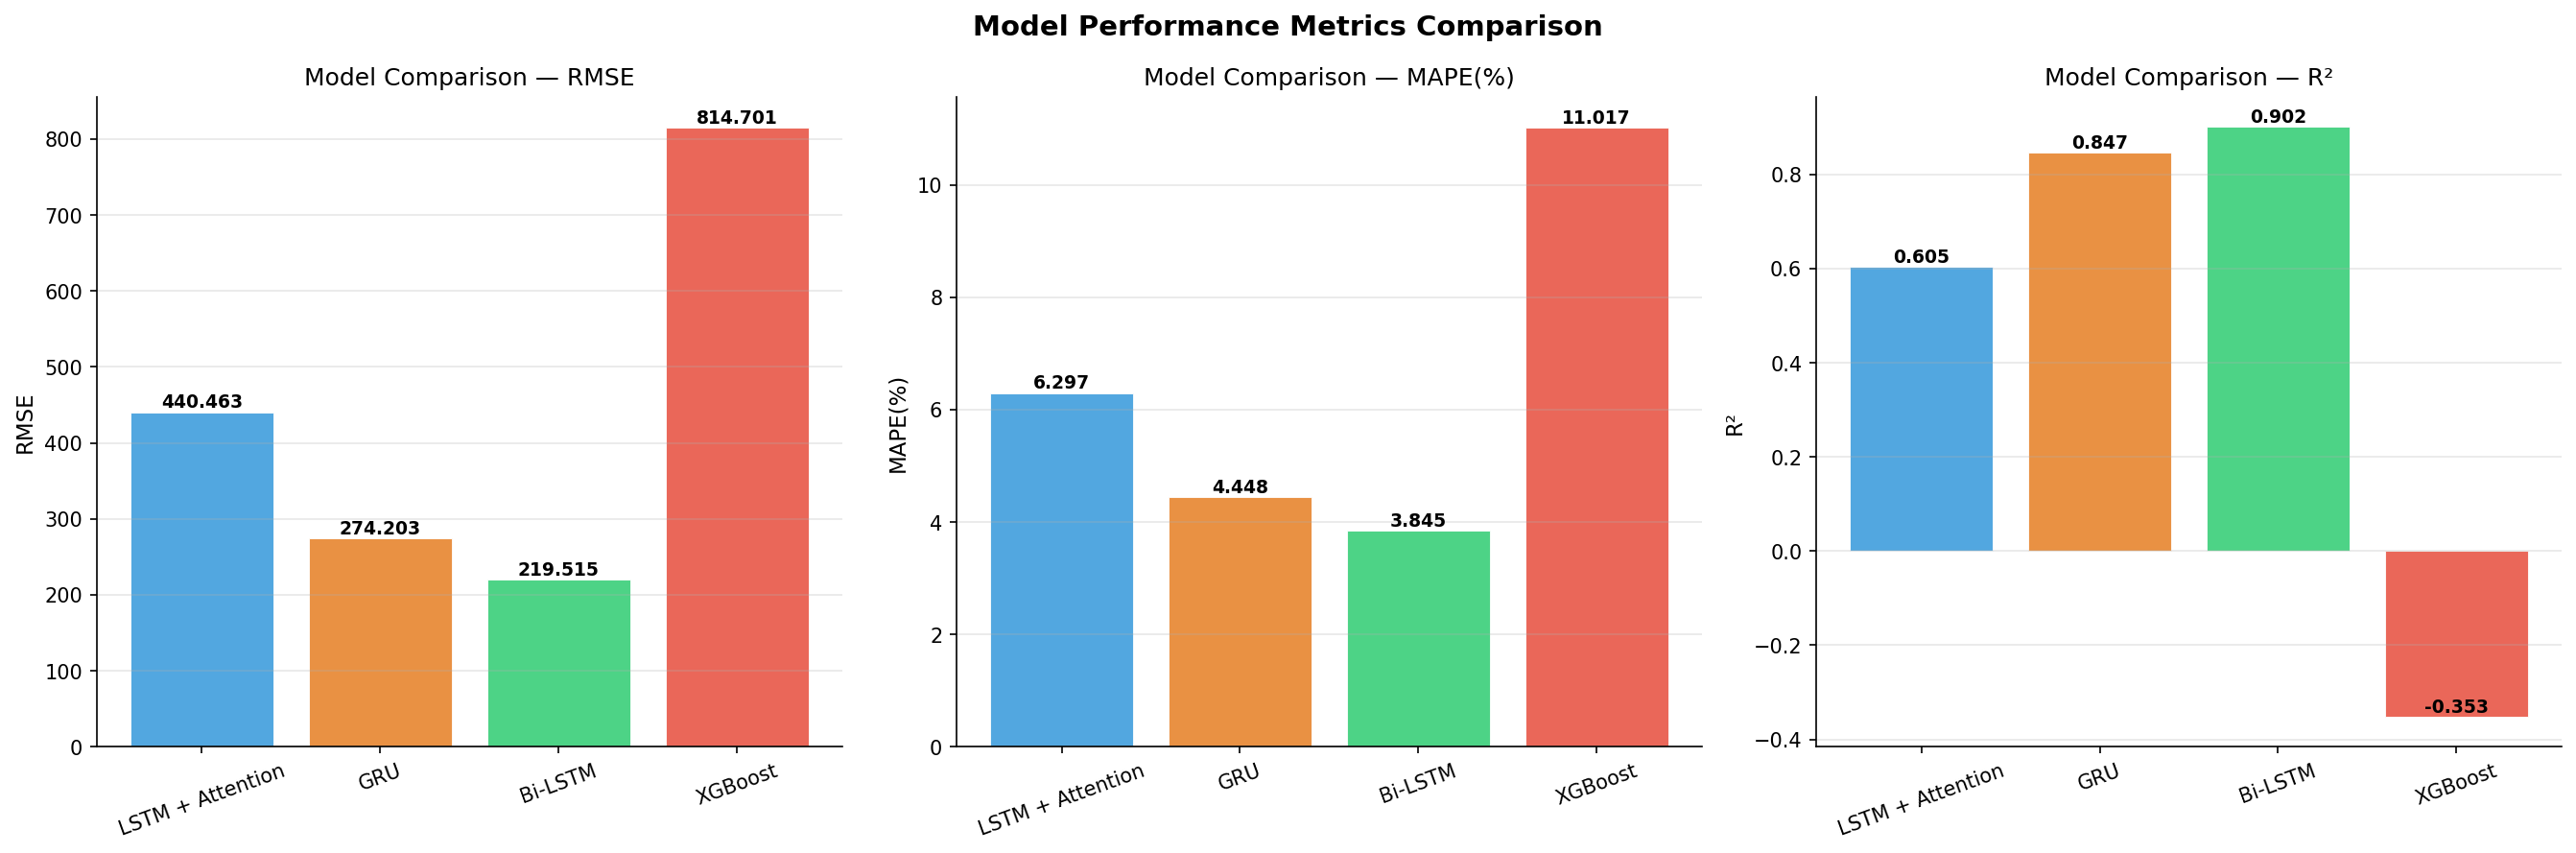

✅ Saved: metrics_comparison.png


In [38]:
# ─── Metrics Bar Chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
model_names = metrics_df.index.tolist()
colors_m    = ['#3498db','#e67e22','#2ecc71','#e74c3c']

for ax, metric in zip(axes, ['RMSE', 'MAPE(%)', 'R²']):
    vals = metrics_df[metric].values
    bars = ax.bar(model_names, vals, color=colors_m, alpha=0.85, edgecolor='white', linewidth=0.5)
    ax.set_title(f"Model Comparison — {metric}", fontsize=12)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001 * max(vals),
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle("Model Performance Metrics Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['viz_models']}/metrics_comparison.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: metrics_comparison.png")

## Section 18 — Prediction Visualizations

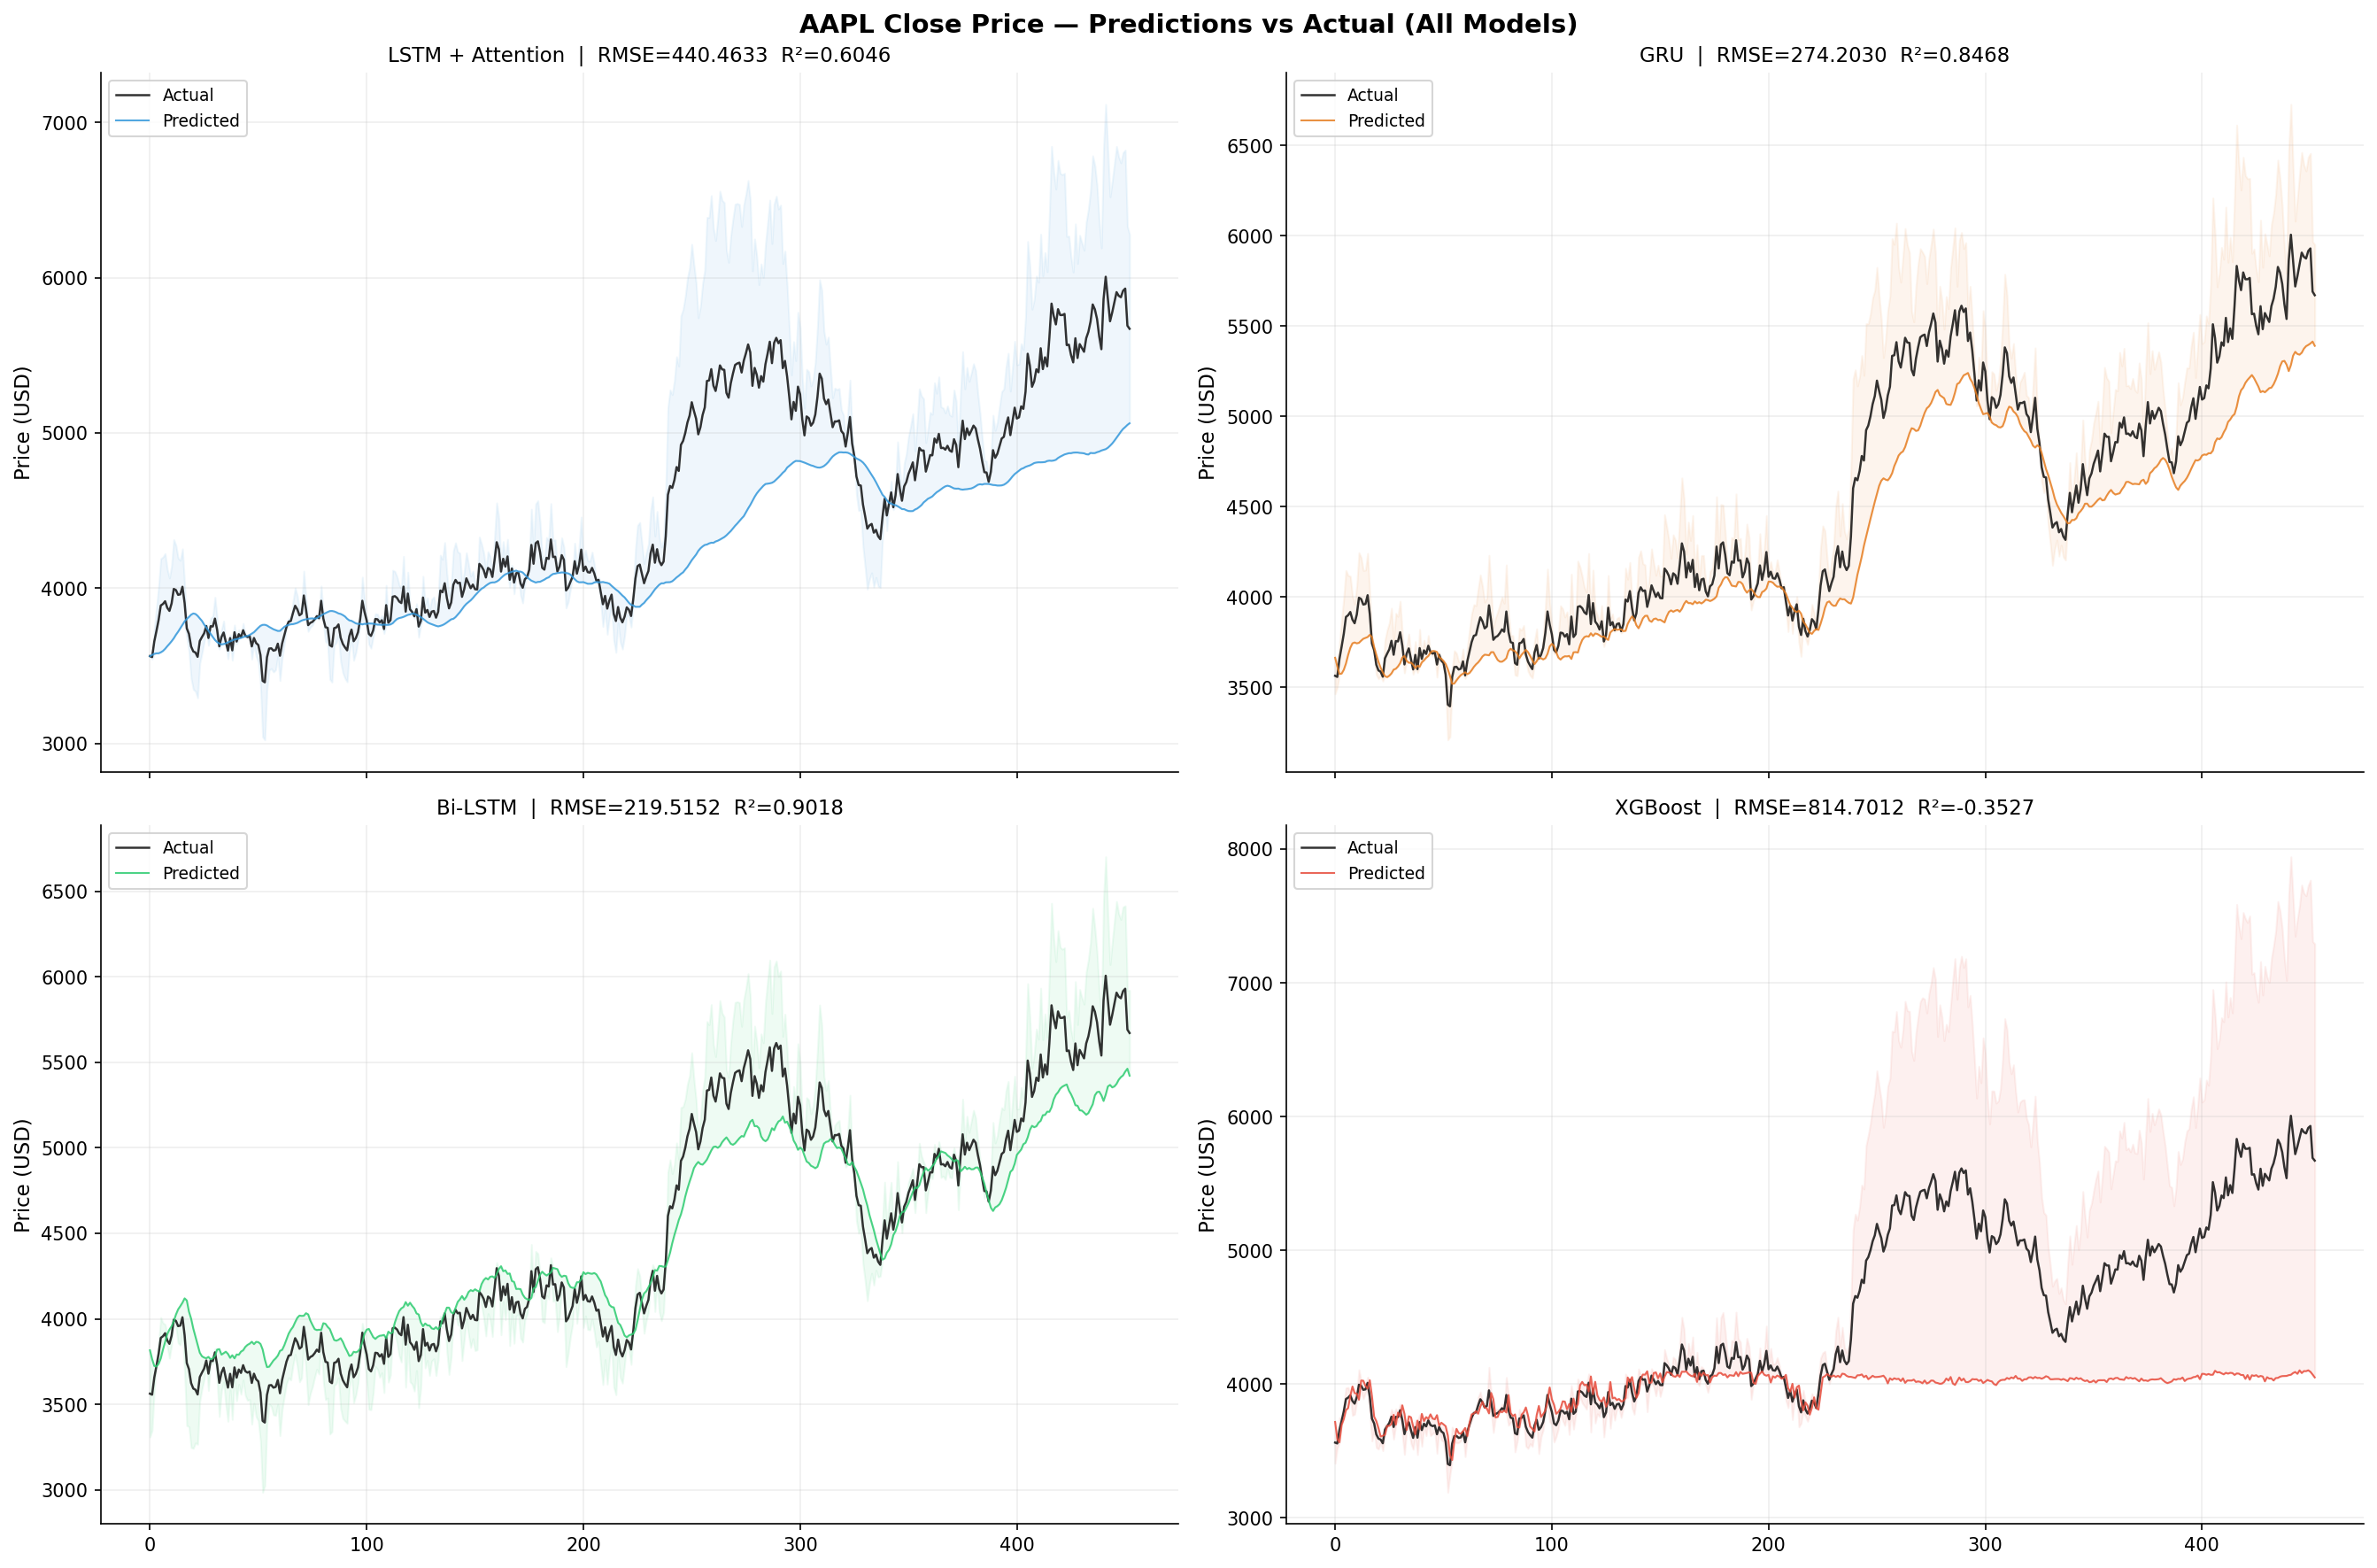

✅ Saved: all_model_predictions.png


In [40]:
MODEL_PREDS = [
    ('LSTM + Attention', lstm_pred,   '#3498db'),
    ('GRU',              gru_pred,    '#e67e22'),
    ('Bi-LSTM',          bilstm_pred, '#2ecc71'),
    ('XGBoost',          xgb_pred,    '#e74c3c'),
]

fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharex=True)
for ax, (name, pred, color) in zip(axes.flatten(), MODEL_PREDS):
    ax.plot(y_test_inv, color='black', linewidth=1.2, alpha=0.8, label='Actual')
    ax.plot(pred,       color=color,   linewidth=1,   alpha=0.85, label='Predicted')
    rmse_ = metrics_df.loc[name, 'RMSE']
    r2_   = metrics_df.loc[name, 'R²']
    ax.set_title(f"{name}  |  RMSE={rmse_:.4f}  R²={r2_:.4f}", fontsize=11)
    ax.set_ylabel("Price (USD)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    # Shaded error band
    errors = np.abs(np.array(y_test_inv) - np.array(pred))
    ax.fill_between(range(len(y_test_inv)),
                    np.array(y_test_inv) - errors,
                    np.array(y_test_inv) + errors,
                    alpha=0.08, color=color)

plt.suptitle("AAPL Close Price — Predictions vs Actual (All Models)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['viz_models']}/all_model_predictions.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: all_model_predictions.png")

| Model            | What Happened                               | Why It Happened                                                     | Evidence from Metrics                     | Conclusion                           |
| ---------------- | ------------------------------------------- | ------------------------------------------------------------------- | ----------------------------------------- | ------------------------------------ |
| LSTM + Attention | Struggles in later high-price region        | Attention helps, but still limited in capturing sharp regime shifts | Higher RMSE (440), moderate R² (0.60)     | Good but unstable in volatile trends |
| GRU              | Tracks trend well with smoother predictions | Simpler architecture → better generalization, less overfitting      | Low RMSE (274), high R² (0.84)            | Strong and stable performance        |
| Bi-LSTM          | Best alignment with actual prices           | Uses past + future context → better temporal understanding          | Lowest RMSE (219), highest R² (0.90)      | Best model overall                   |
| XGBoost          | Flat predictions; fails after trend shift   | Cannot capture time dependency or compounding trend                 | Very high RMSE (814), negative R² (-0.35) | Fails for time-series forecasting    |


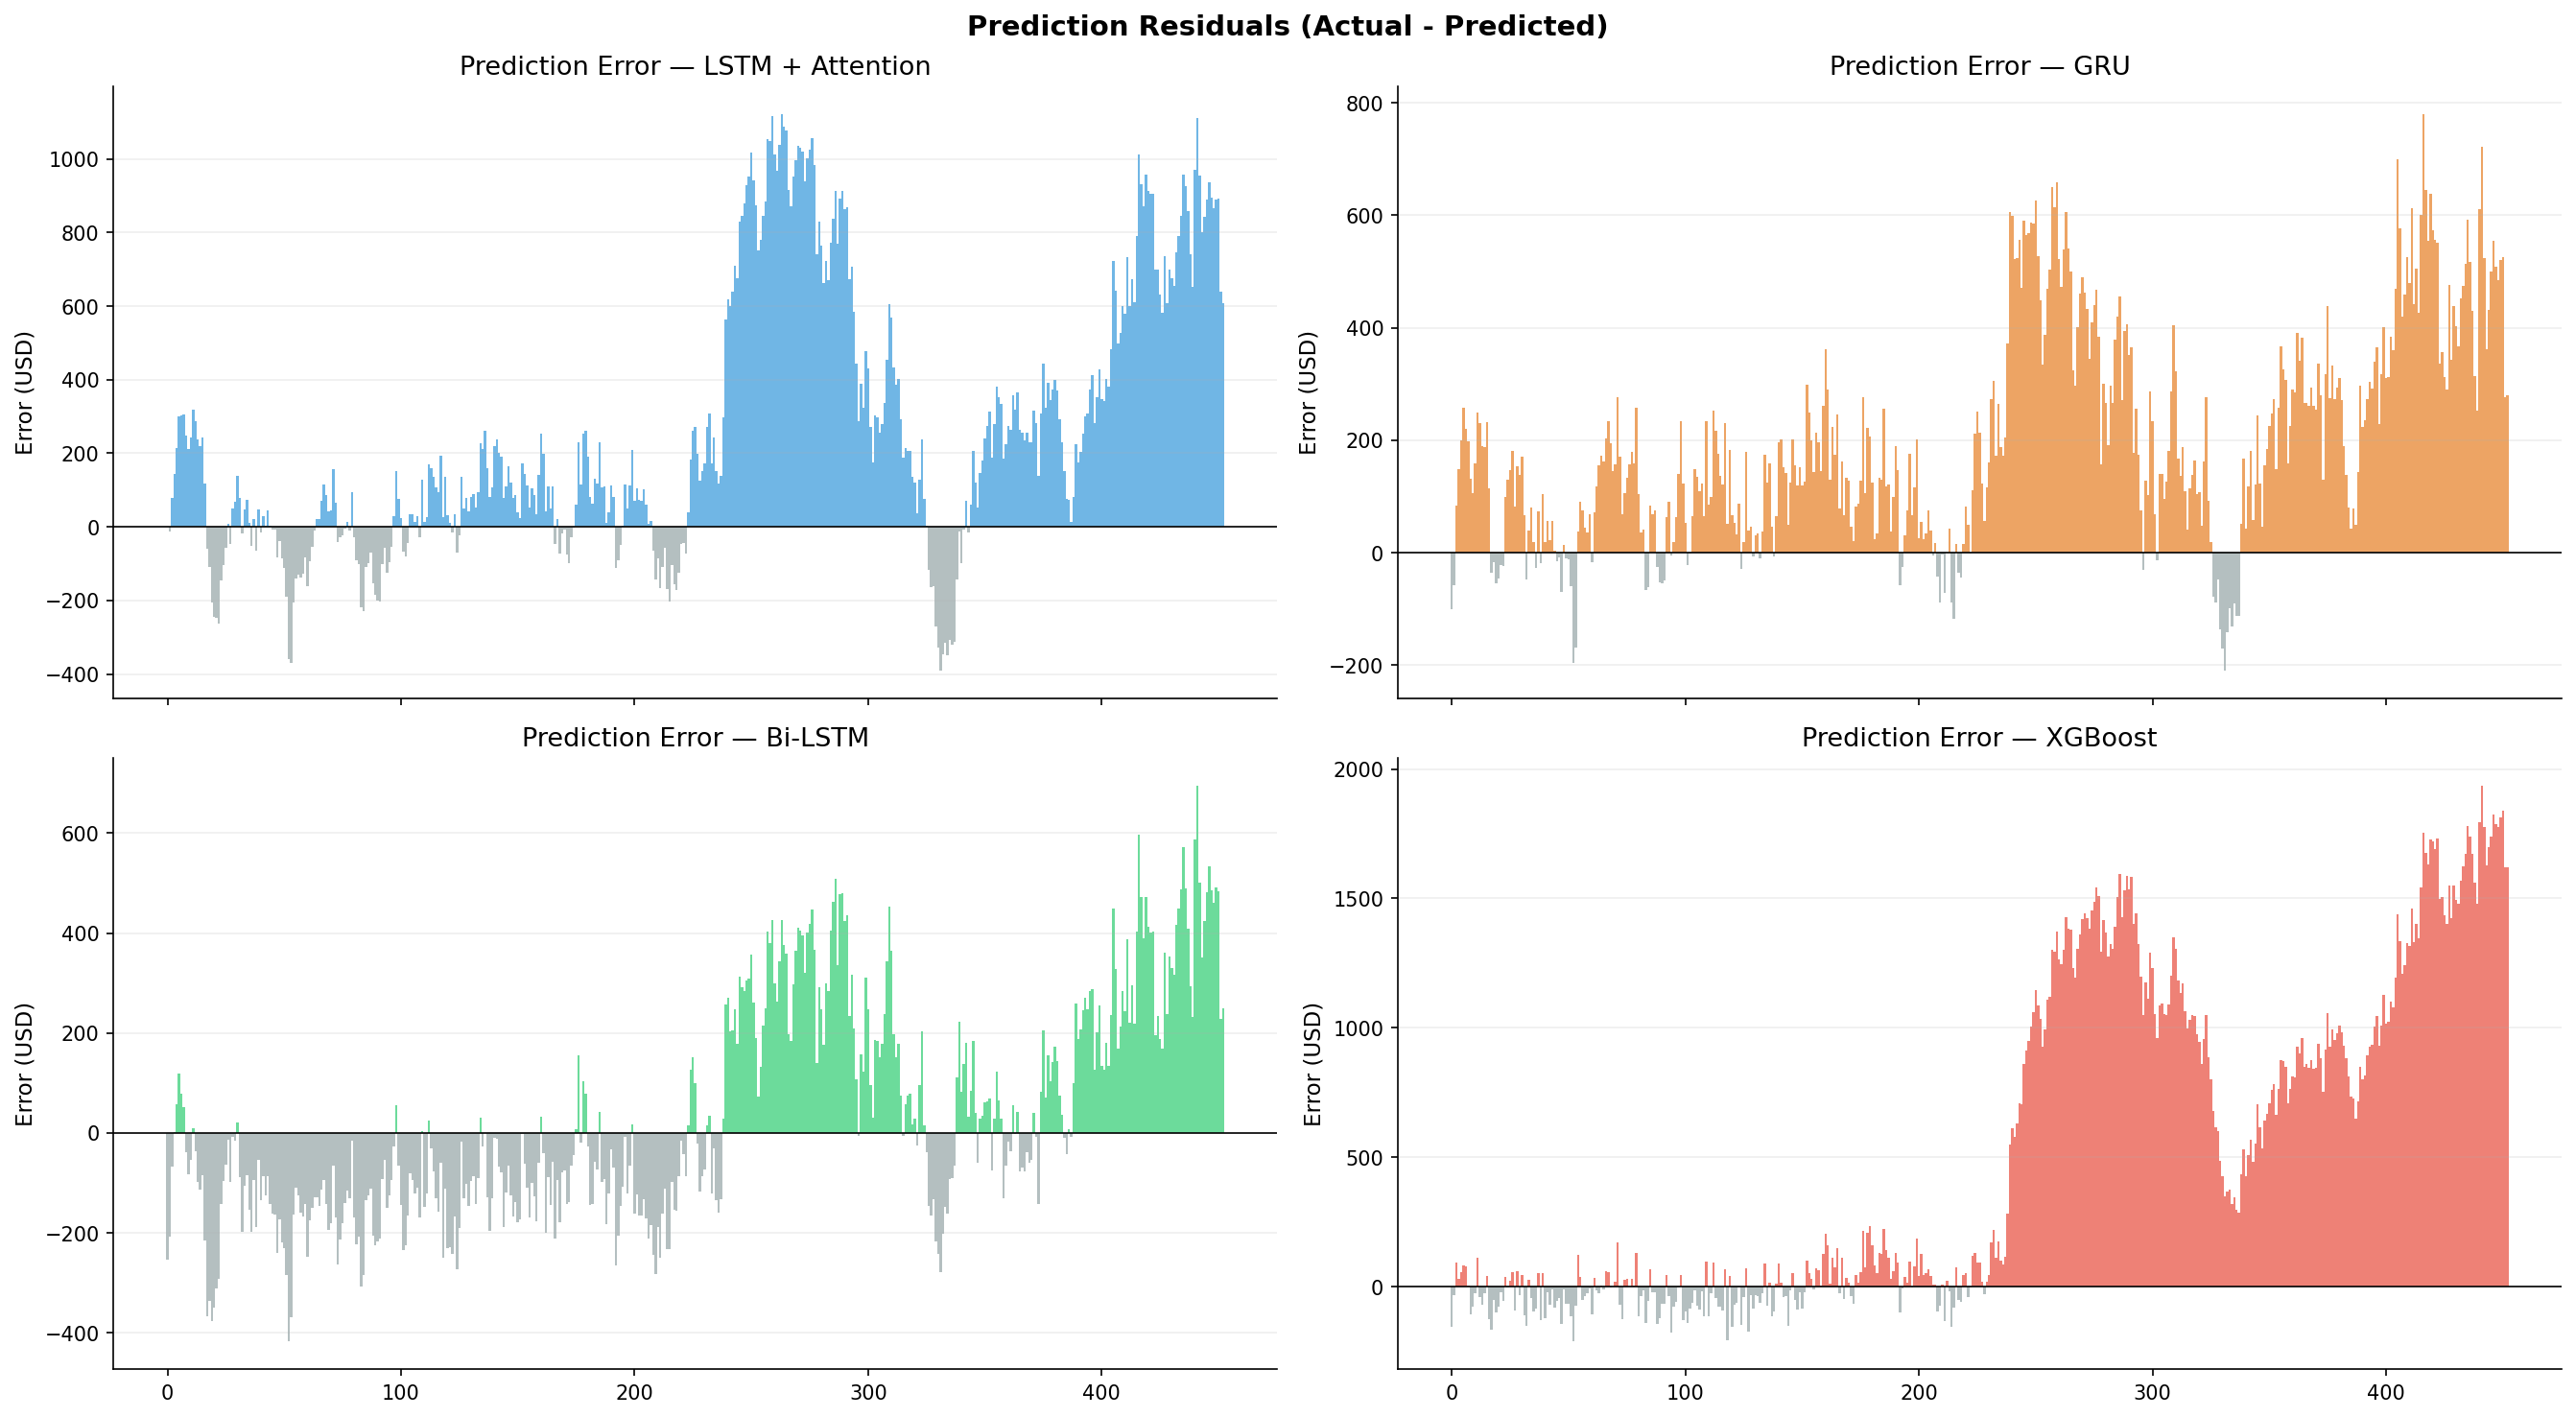

✅ Saved: prediction_errors.png


In [41]:
# ─── Error Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharex=True)
for ax, (name, pred, color) in zip(axes.flatten(), MODEL_PREDS):
    errors = y_test_inv - pred
    ax.bar(range(len(errors)), errors, color=[color if e >= 0 else '#95a5a6' for e in errors],
           alpha=0.7, width=1)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f"Prediction Error — {name}")
    ax.set_ylabel("Error (USD)")
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle("Prediction Residuals (Actual - Predicted)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['viz_models']}/prediction_errors.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: prediction_errors.png")

##  Section 19 — Temporal Attention Visualisation

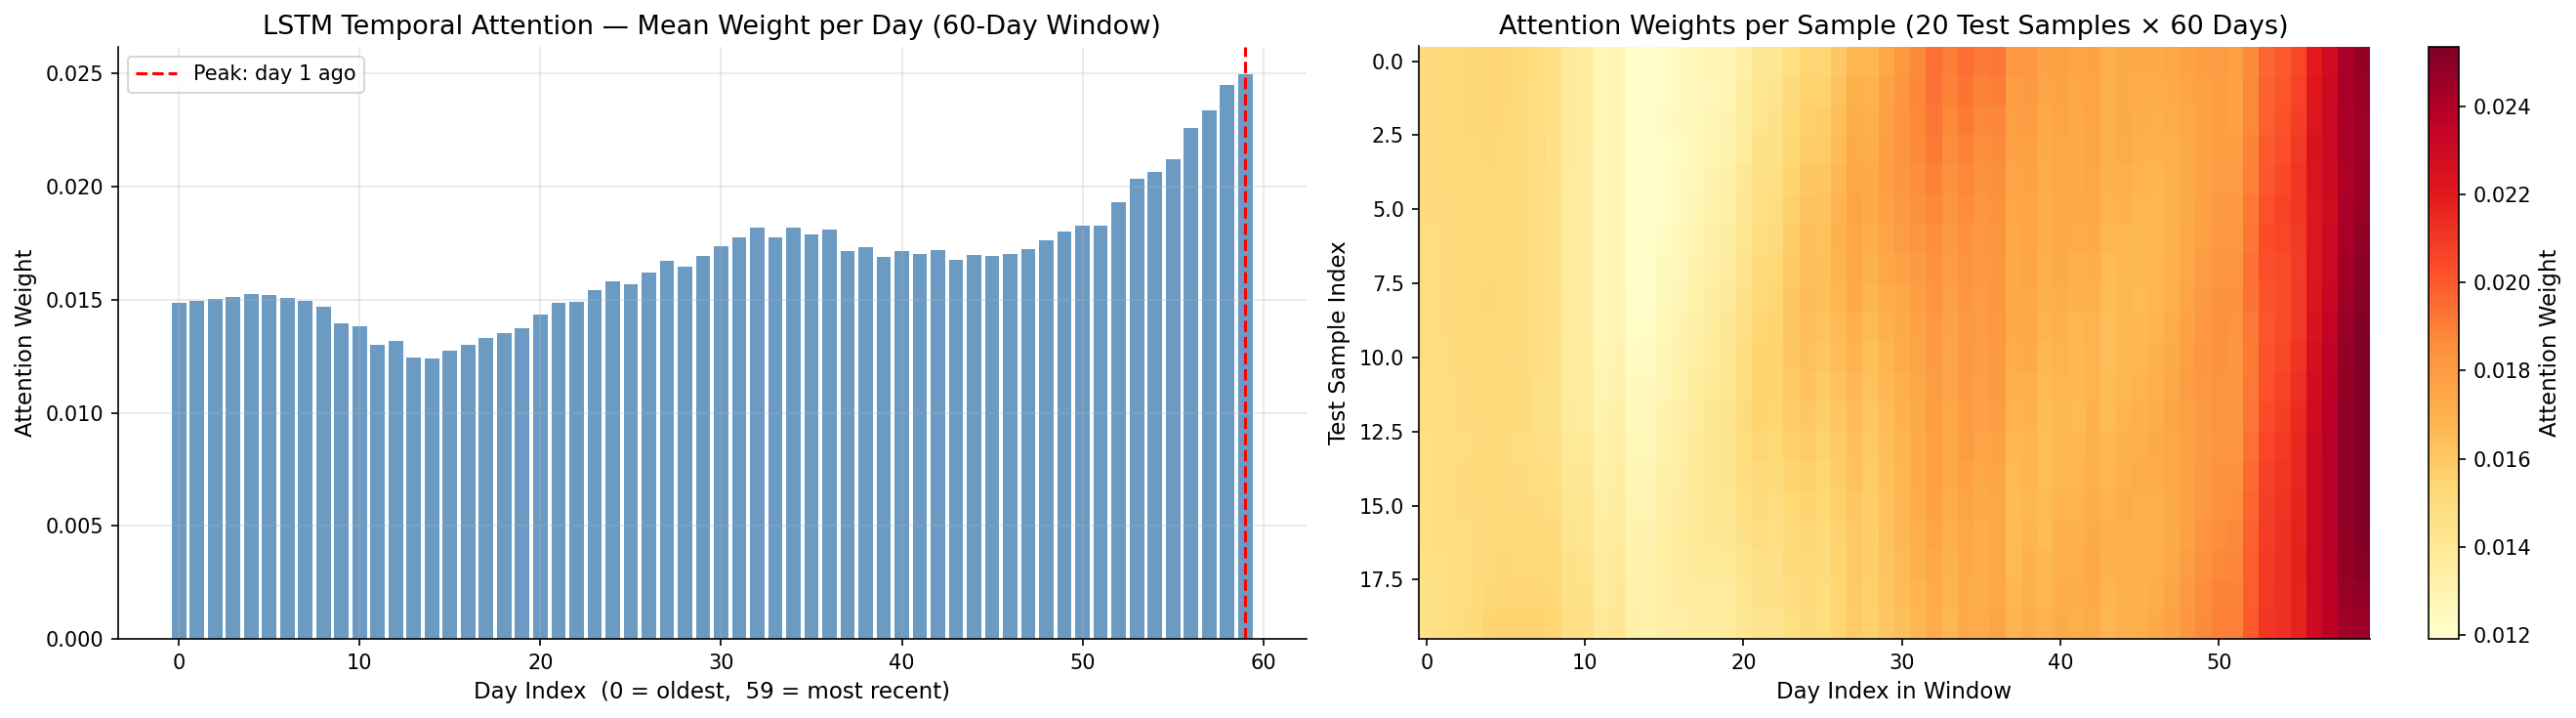

✅ Saved: attention_matrix.png
   Most influential time step: 1 days ago


In [42]:
att_extractor = Model(inputs=lstm_model.input, outputs=att_weights_tensor)
att_scores    = att_extractor.predict(X_test[:20], verbose=0)   # (20, 60, 1)
mean_att      = att_scores.mean(axis=0).flatten()                # (60,)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Bar chart
axes[0].bar(range(WINDOW_SIZE), mean_att, color='steelblue', alpha=0.8)
axes[0].axvline(np.argmax(mean_att), color='red', linestyle='--', linewidth=1.5,
                label=f'Peak: day {WINDOW_SIZE - np.argmax(mean_att)} ago')
axes[0].set_title("LSTM Temporal Attention — Mean Weight per Day (60-Day Window)")
axes[0].set_xlabel("Day Index  (0 = oldest,  59 = most recent)")
axes[0].set_ylabel("Attention Weight")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Heatmap across 20 samples
axes[1].imshow(att_scores[:, :, 0], aspect='auto', cmap='YlOrRd')
plt.colorbar(axes[1].images[0], ax=axes[1], label='Attention Weight')
axes[1].set_title("Attention Weights per Sample (20 Test Samples × 60 Days)")
axes[1].set_xlabel("Day Index in Window")
axes[1].set_ylabel("Test Sample Index")

plt.tight_layout()
plt.savefig(f"{DIRS['viz_models']}/attention_matrix.png", bbox_inches='tight', dpi=150)
plt.show()
print(f"✅ Saved: attention_matrix.png")
print(f"   Most influential time step: {WINDOW_SIZE - np.argmax(mean_att)} days ago")

##  Section 20 — XAI: SHAP GradientExplainer (LSTM + Attention)
`GradientExplainer` uses backpropagation to compute exact Shapley values for neural networks —
preserving the full `(samples × timesteps × features)` 3D shape for temporal analysis.

In [43]:
N_BG      = 200
N_EXPLAIN = 50

shap_bg   = X_train[:N_BG]
shap_test = X_test[:N_EXPLAIN]

grad_explainer = shap.GradientExplainer(lstm_model, shap_bg)
print(f"✅ GradientExplainer ready | Background: {N_BG} samples | Explaining: {N_EXPLAIN} samples")

✅ GradientExplainer ready | Background: 200 samples | Explaining: 50 samples


In [44]:
shap_vals_raw = grad_explainer.shap_values(shap_test)

if isinstance(shap_vals_raw, list):
    shap_3d = np.array(shap_vals_raw[0])
else:
    shap_3d = np.array(shap_vals_raw)

if shap_3d.ndim == 4:
    shap_3d = shap_3d.squeeze(-1)

print(f"✅ SHAP 3D tensor shape: {shap_3d.shape}")   # (50, 60, 12)

shap_feat   = shap_3d.mean(axis=1)         # (50, 12) — avg over time
X_test_mean = shap_test.mean(axis=1)       # (50, 12)

✅ SHAP 3D tensor shape: (50, 60, 12)


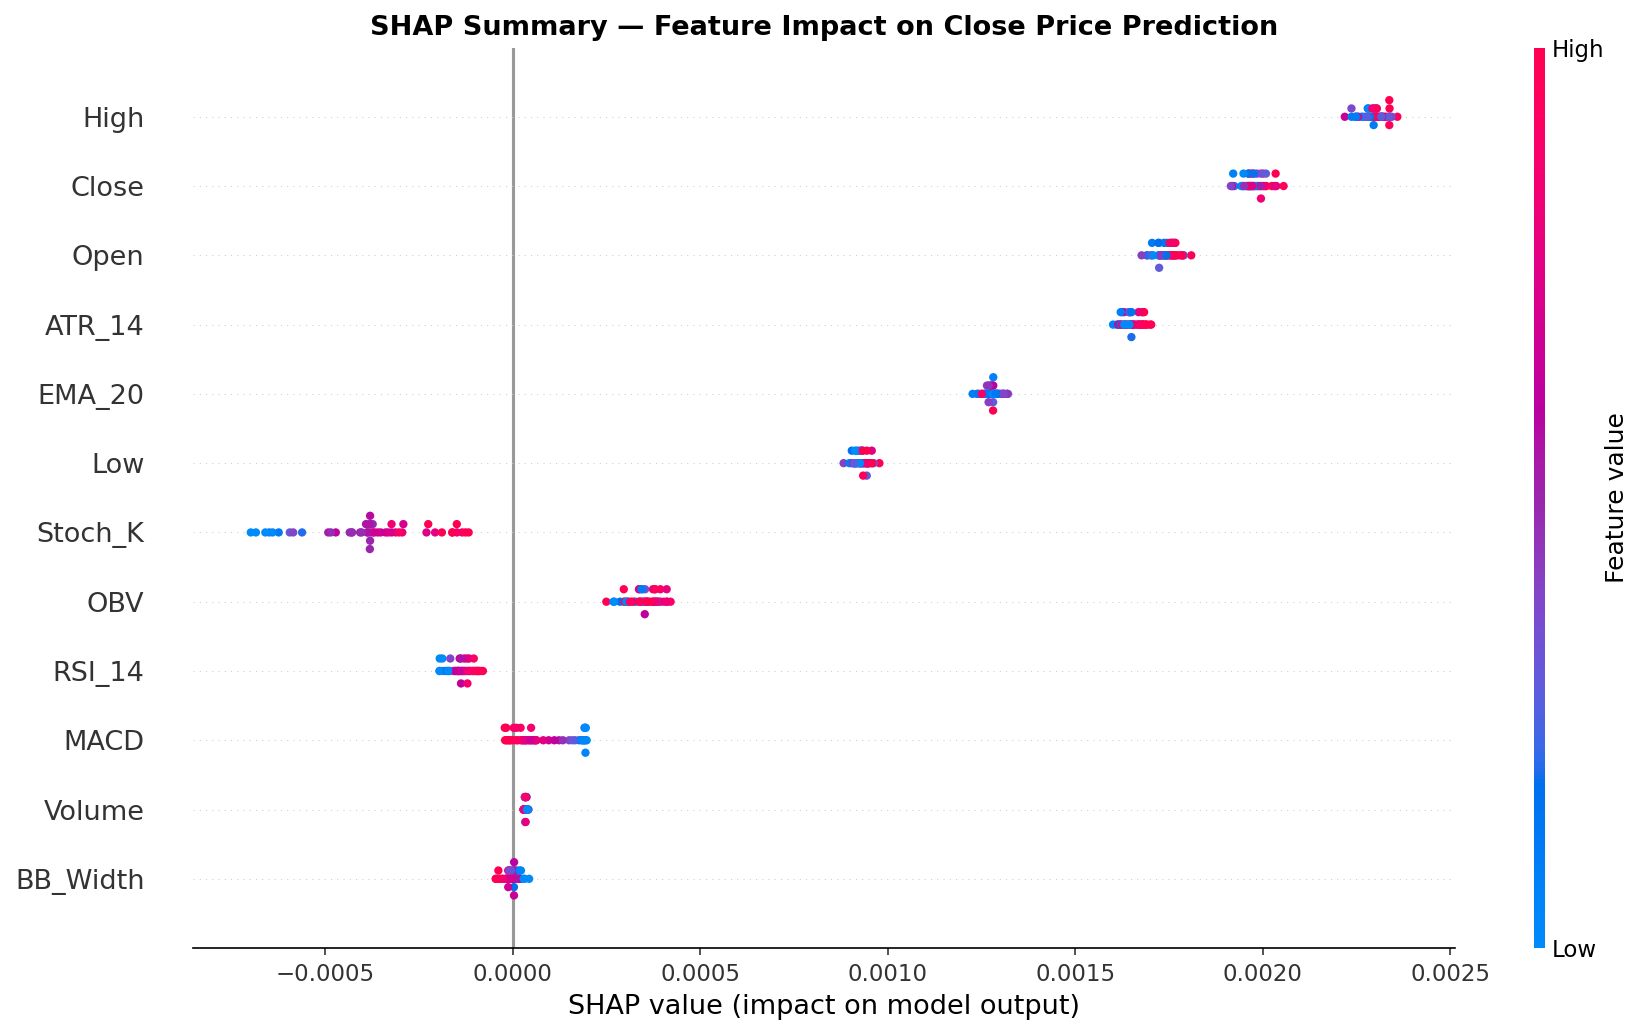

✅ Saved: shap_summary_beeswarm.png


In [45]:
# ─── SHAP Plot 1: Summary (Beeswarm) ─────────────────────────────────────────
plt.figure()
shap.summary_plot(shap_feat, X_test_mean, feature_names=FEATURE_NAMES,
                  show=False, plot_size=(12, 7))
plt.title("SHAP Summary — Feature Impact on Close Price Prediction", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['viz_shap']}/shap_summary_beeswarm.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: shap_summary_beeswarm.png")

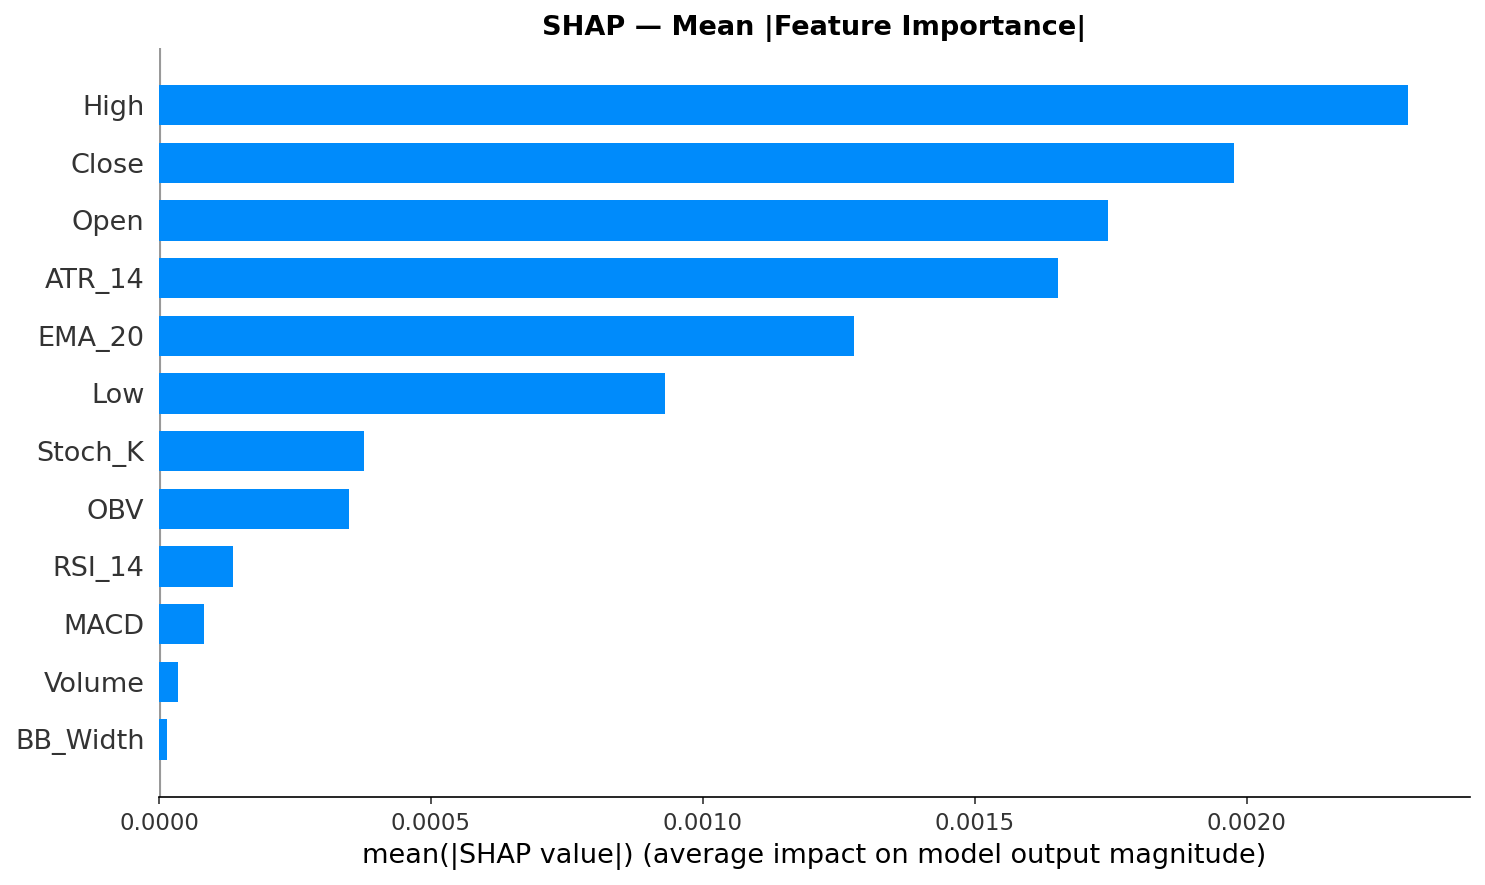

✅ Saved: shap_bar_importance.png


In [46]:
# ─── SHAP Plot 2: Mean Absolute Bar ──────────────────────────────────────────
plt.figure()
shap.summary_plot(shap_feat, X_test_mean, feature_names=FEATURE_NAMES,
                  plot_type='bar', show=False, plot_size=(10, 6))
plt.title("SHAP — Mean |Feature Importance|", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['viz_shap']}/shap_bar_importance.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: shap_bar_importance.png")

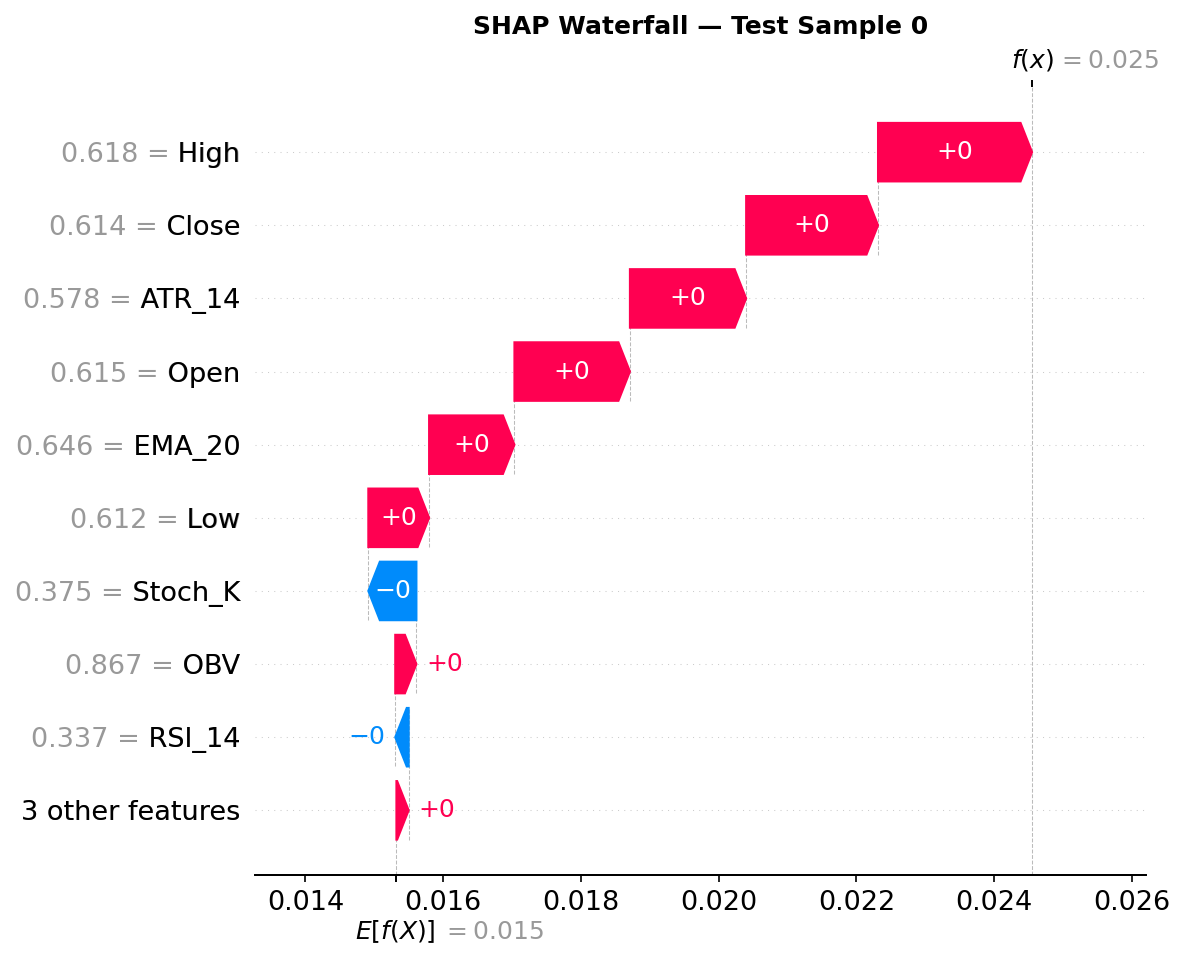

✅ Saved: shap_waterfall.png


In [48]:
# ─── SHAP Plot 3: Waterfall (single sample) ──────────────────────────────────
sample_idx = 0

# GradientExplainer has no .expected_value — compute it as mean prediction on background
base_val = float(lstm_model.predict(shap_bg, verbose=0).mean())

exp = shap.Explanation(
    values=shap_feat[sample_idx],
    base_values=base_val,
    data=X_test_mean[sample_idx],
    feature_names=FEATURE_NAMES,
)
plt.figure()
shap.plots.waterfall(exp, show=False)
plt.title(f"SHAP Waterfall — Test Sample {sample_idx}", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['viz_shap']}/shap_waterfall.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: shap_waterfall.png")

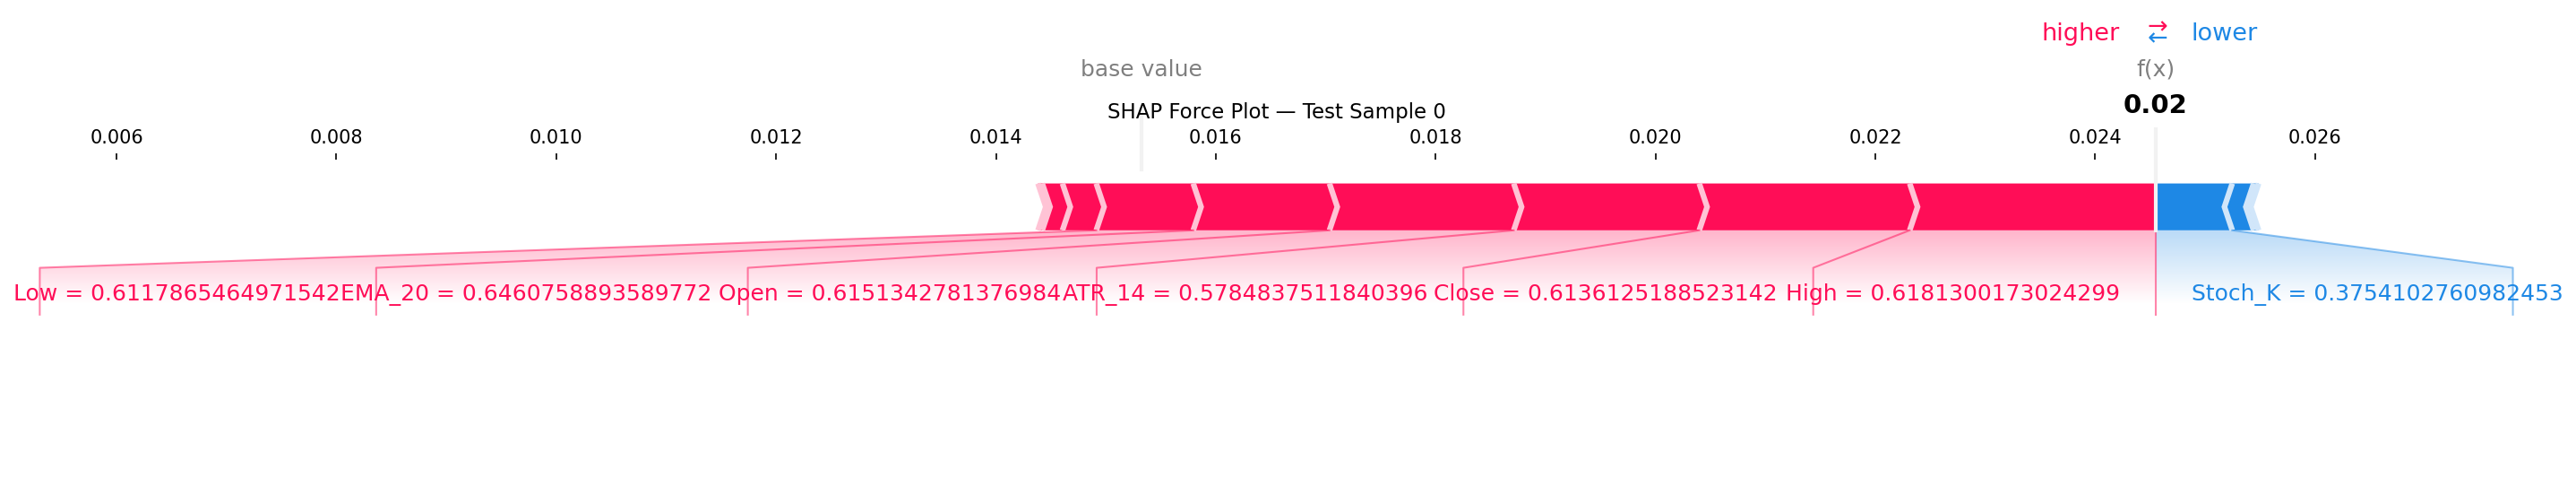

✅ Saved: shap_force_plot.png


In [49]:
# ─── SHAP Plot 4: Force Plot ─────────────────────────────────────────────────
shap.initjs()
shap.force_plot(base_val, shap_feat[sample_idx], X_test_mean[sample_idx],
                feature_names=FEATURE_NAMES, matplotlib=True, show=False, figsize=(20, 4))
plt.title(f"SHAP Force Plot — Test Sample {sample_idx}", fontsize=11)
plt.tight_layout()
plt.savefig(f"{DIRS['viz_shap']}/shap_force_plot.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: shap_force_plot.png")

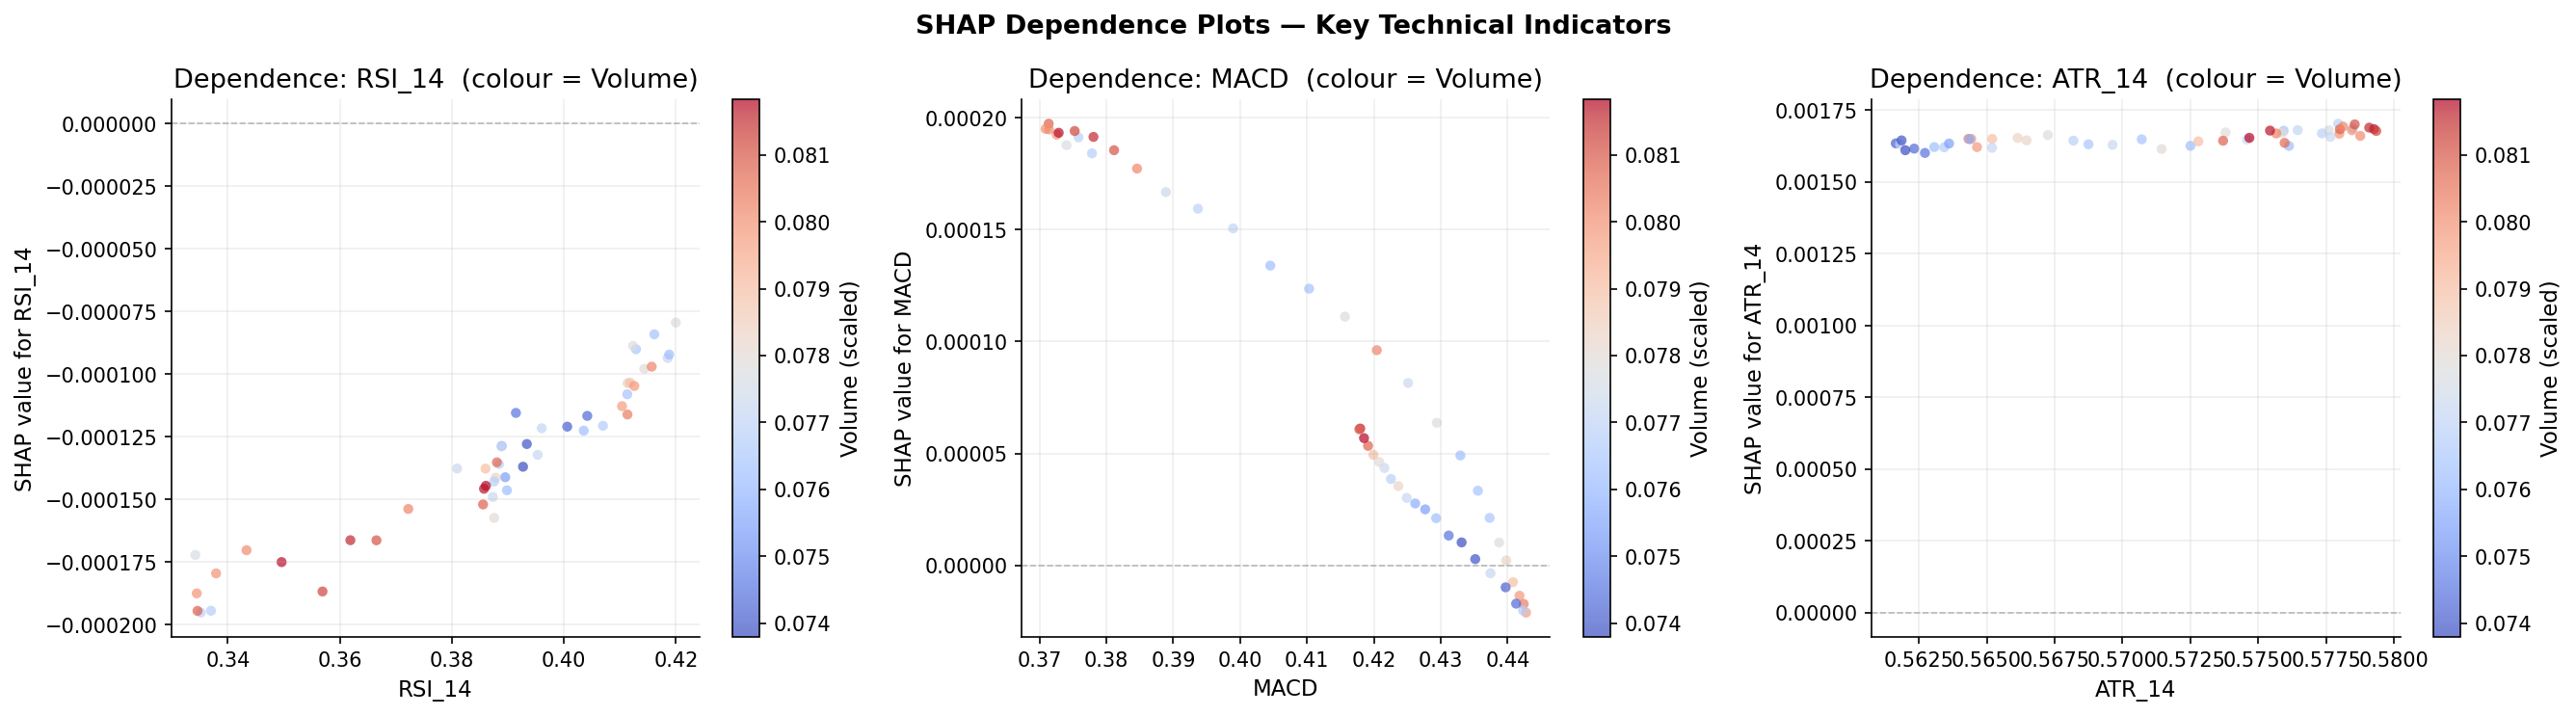

✅ Saved: shap_dependence.png


In [50]:
# ─── SHAP Plot 5: Dependence Plots (3 key features) ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
vol_idx = FEATURE_NAMES.index('Volume')

for ax, feat in zip(axes, ['RSI_14', 'MACD', 'ATR_14']):
    fi   = FEATURE_NAMES.index(feat)
    sc   = ax.scatter(X_test_mean[:, fi], shap_feat[:, fi],
                      c=X_test_mean[:, vol_idx], cmap='coolwarm',
                      alpha=0.7, s=25, edgecolors='none')
    plt.colorbar(sc, ax=ax, label='Volume (scaled)')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)
    ax.set_xlabel(feat)
    ax.set_ylabel(f"SHAP value for {feat}")
    ax.set_title(f"Dependence: {feat}  (colour = Volume)")
    ax.grid(True, alpha=0.2)

plt.suptitle("SHAP Dependence Plots — Key Technical Indicators", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['viz_shap']}/shap_dependence.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: shap_dependence.png")

## Section 21 — SHAP: Time-Step Importance & Feature×Time Heatmap

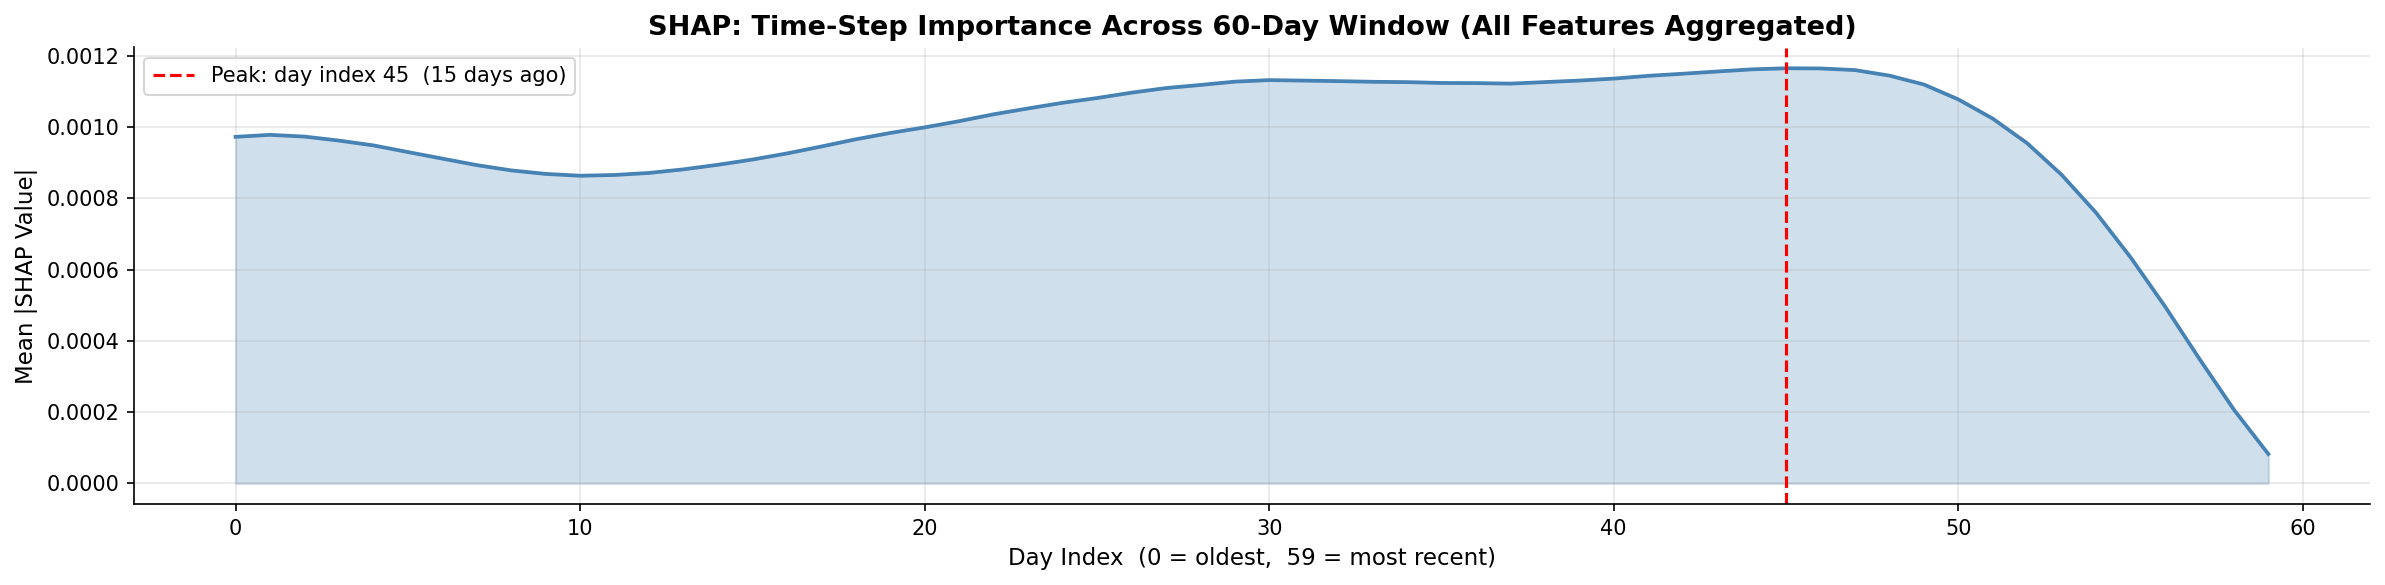

✅ Saved: shap_timestep_importance.png  |  Peak at index 45


In [51]:
# ─── Time-step importance ─────────────────────────────────────────────────────
mean_shap_time = np.abs(shap_3d).mean(axis=(0, 2))   # (60,)
peak_day       = np.argmax(mean_shap_time)

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(range(WINDOW_SIZE), mean_shap_time, color='steelblue', linewidth=1.8)
ax.fill_between(range(WINDOW_SIZE), mean_shap_time, alpha=0.25, color='steelblue')
ax.axvline(peak_day, color='red', linestyle='--', linewidth=1.5,
           label=f'Peak: day index {peak_day}  ({WINDOW_SIZE - peak_day} days ago)')
ax.set_title("SHAP: Time-Step Importance Across 60-Day Window (All Features Aggregated)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Day Index  (0 = oldest,  59 = most recent)")
ax.set_ylabel("Mean |SHAP Value|")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{DIRS['viz_shap']}/shap_timestep_importance.png", bbox_inches='tight', dpi=150)
plt.show()
print(f"✅ Saved: shap_timestep_importance.png  |  Peak at index {peak_day}")

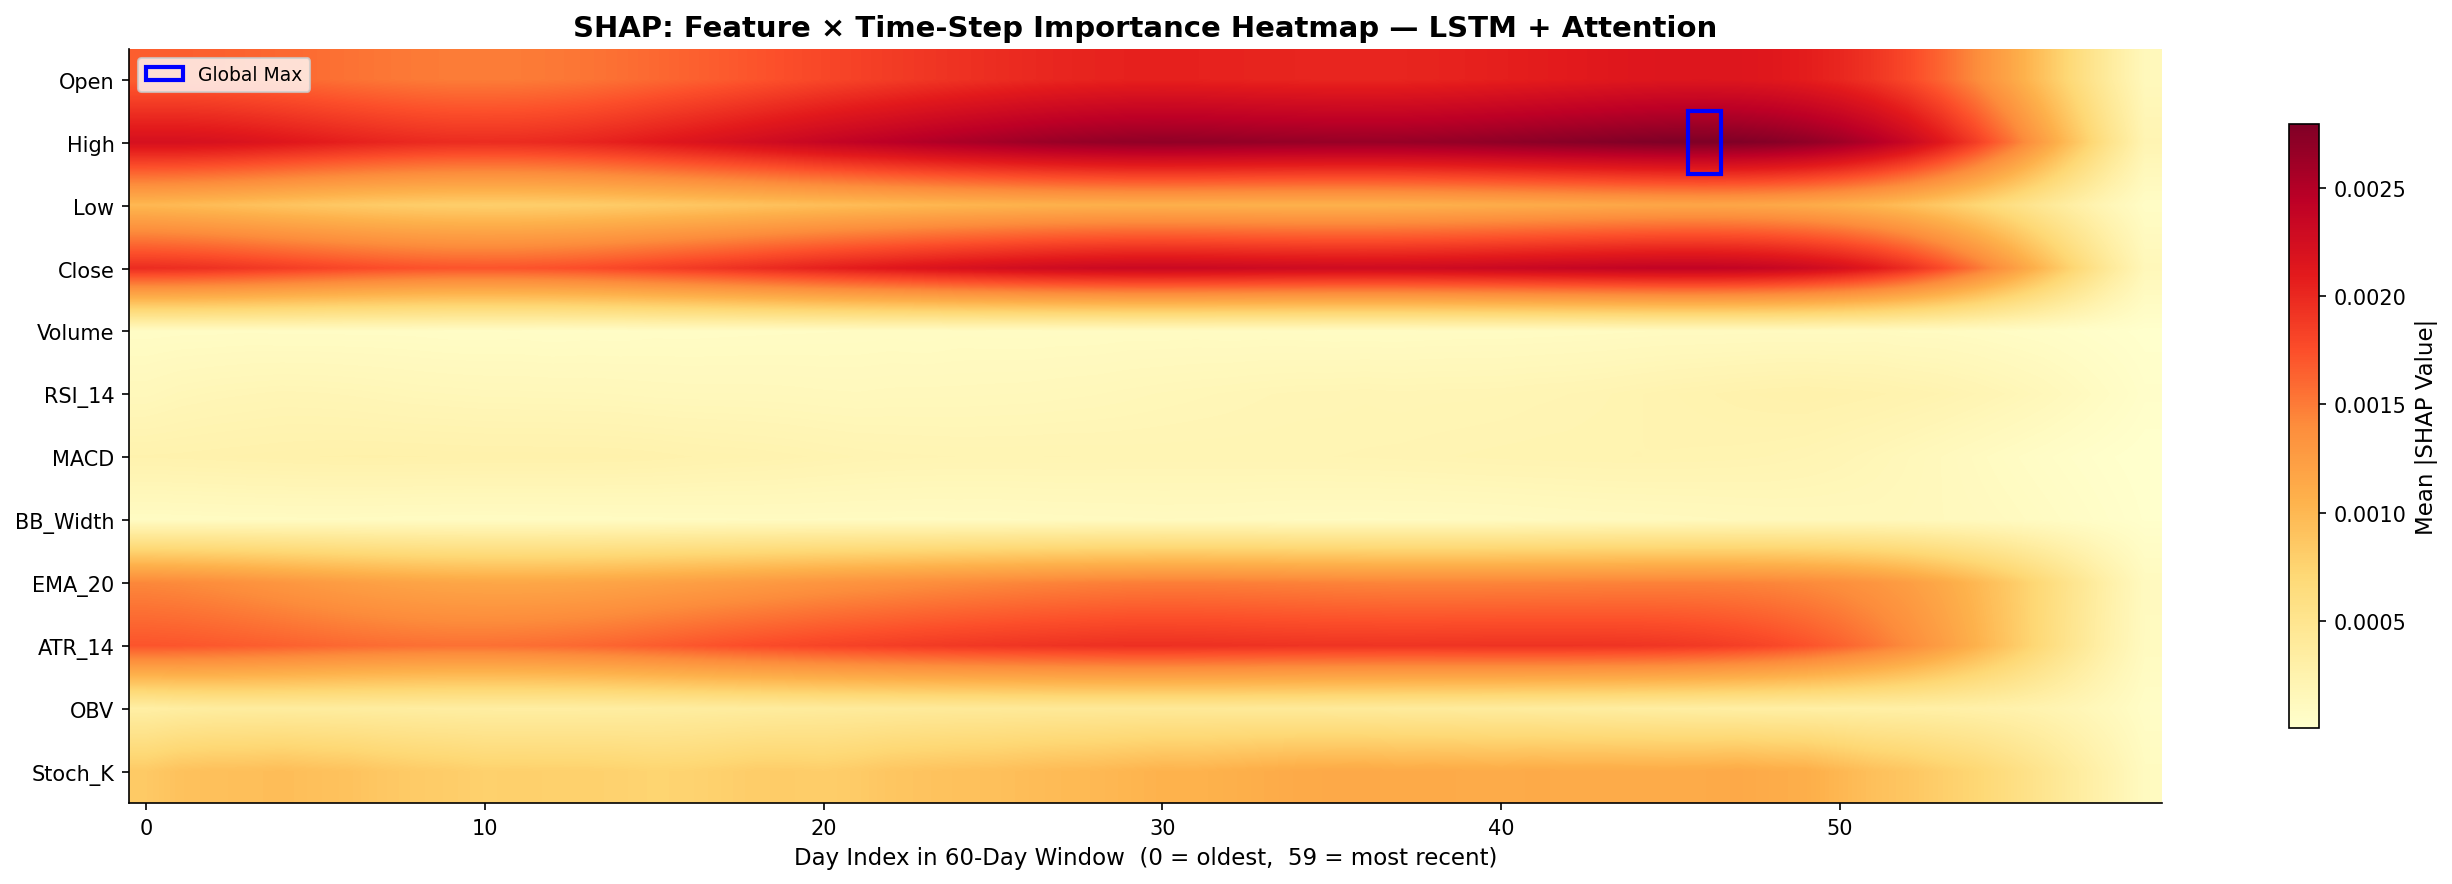

✅ Saved: shap_feature_time_heatmap_lstm.png


In [52]:
# ─── Feature × Time-step Heatmap ─────────────────────────────────────────────
mean_shap_ft = np.abs(shap_3d).mean(axis=0)   # (60, 12)

fig, ax = plt.subplots(figsize=(18, 6))
im = ax.imshow(mean_shap_ft.T, aspect='auto', cmap='YlOrRd', interpolation='bilinear')
plt.colorbar(im, ax=ax, label='Mean |SHAP Value|', shrink=0.8)
ax.set_yticks(range(N_FEATURES))
ax.set_yticklabels(FEATURE_NAMES, fontsize=10)
ax.set_xlabel("Day Index in 60-Day Window  (0 = oldest,  59 = most recent)", fontsize=11)
ax.set_title("SHAP: Feature × Time-Step Importance Heatmap — LSTM + Attention",
             fontsize=14, fontweight='bold')

# Annotate top contributing cell
max_idx = np.unravel_index(mean_shap_ft.T.argmax(), mean_shap_ft.T.shape)
ax.add_patch(plt.Rectangle((max_idx[1]-0.5, max_idx[0]-0.5), 1, 1,
             fill=False, edgecolor='blue', lw=2, label='Global Max'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f"{DIRS['viz_shap']}/shap_feature_time_heatmap_lstm.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: shap_feature_time_heatmap_lstm.png")

## Section 22 — XAI: XGBoost TreeSHAP (Exact Shapley Values)

✅ XGBoost TreeSHAP shape: (50, 720)


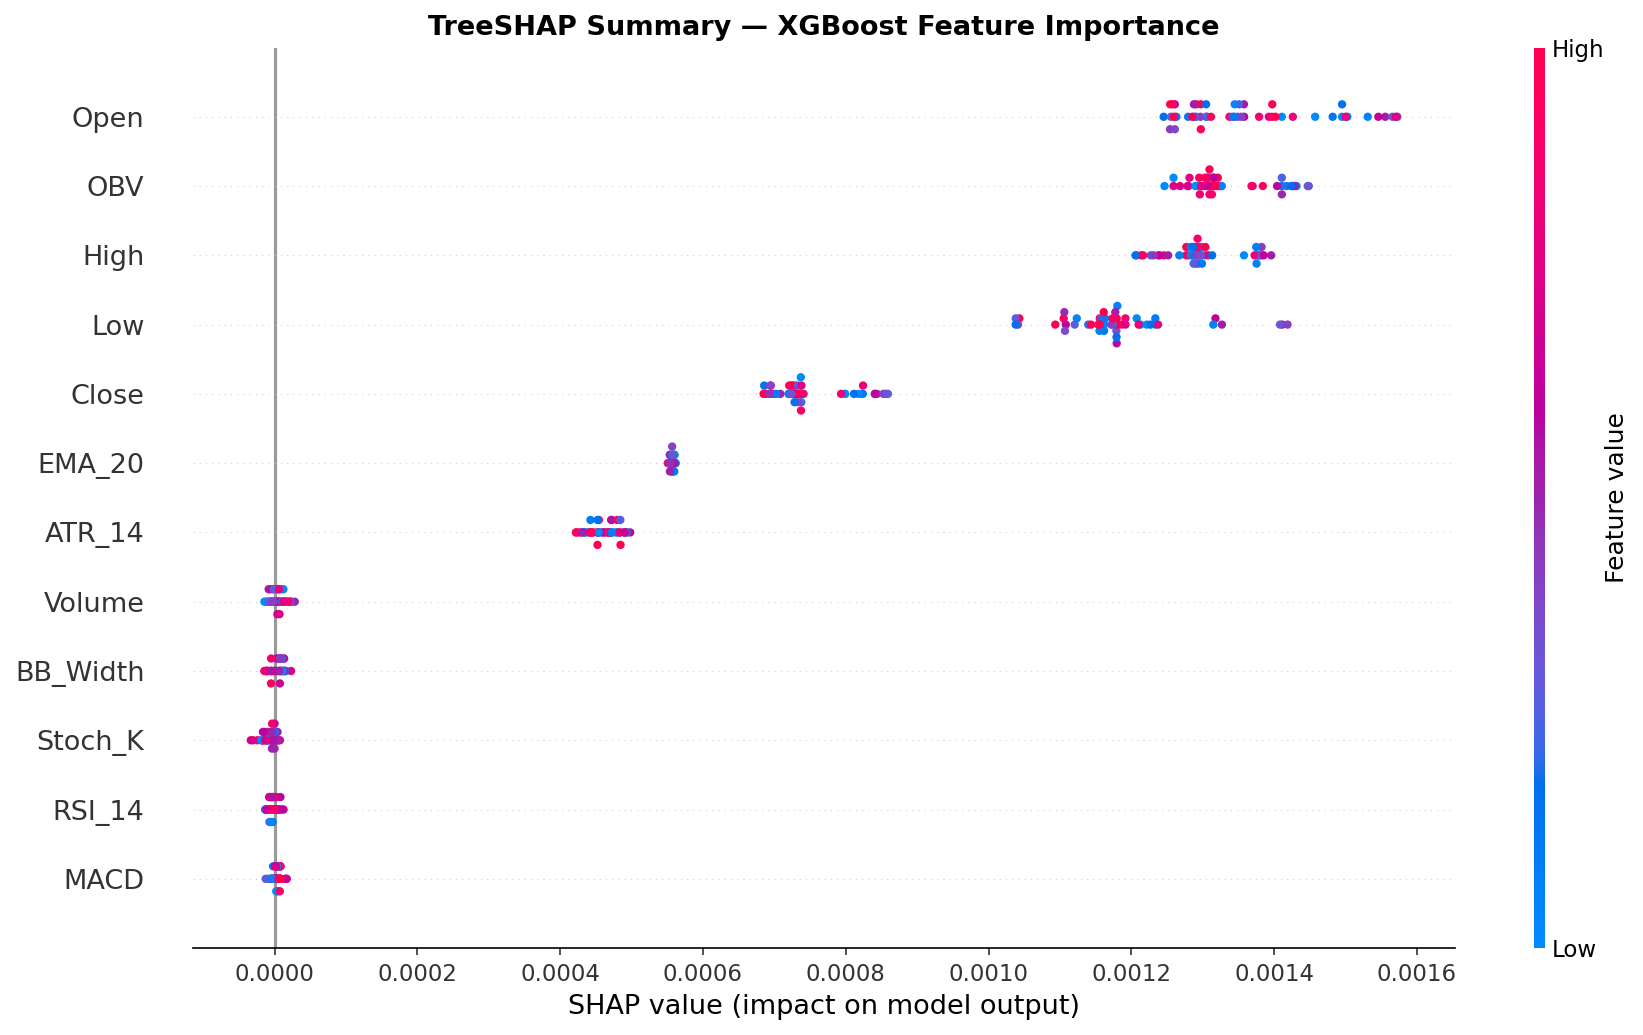

✅ Saved: shap_xgb_summary.png


In [53]:
tree_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_flat  = tree_explainer.shap_values(X_test_flat[:N_EXPLAIN])   # (50, 720)

xgb_shap_3d   = xgb_shap_flat.reshape(N_EXPLAIN, WINDOW_SIZE, N_FEATURES)
xgb_shap_feat = xgb_shap_3d.mean(axis=1)   # (50, 12)

print(f"✅ XGBoost TreeSHAP shape: {xgb_shap_flat.shape}")

plt.figure()
shap.summary_plot(xgb_shap_feat, X_test_mean, feature_names=FEATURE_NAMES,
                  show=False, plot_size=(12, 7))
plt.title("TreeSHAP Summary — XGBoost Feature Importance", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['viz_shap']}/shap_xgb_summary.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: shap_xgb_summary.png")

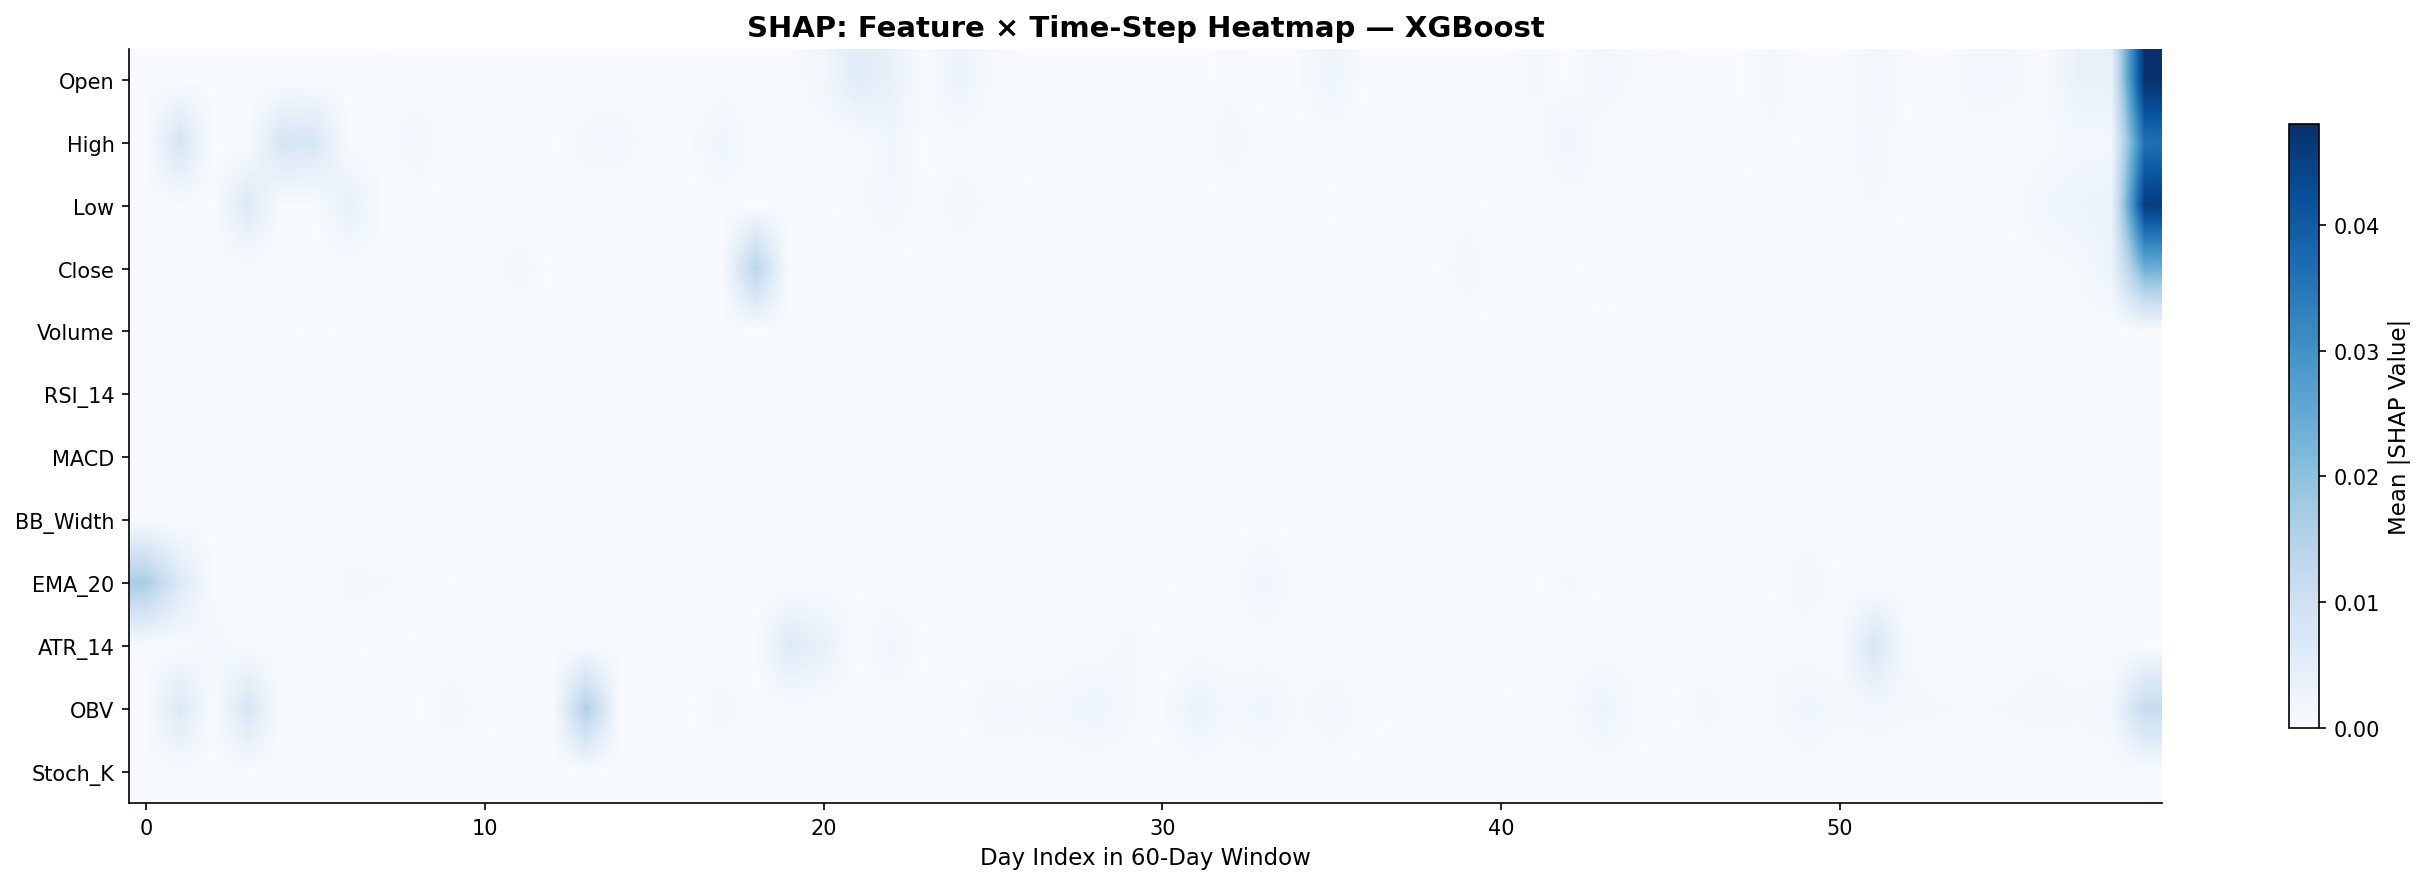

✅ Saved: shap_feature_time_heatmap_xgb.png


In [54]:
# ─── XGBoost Feature × Time heatmap ──────────────────────────────────────────
xgb_ft = np.abs(xgb_shap_3d).mean(axis=0)   # (60, 12)

fig, ax = plt.subplots(figsize=(18, 6))
im = ax.imshow(xgb_ft.T, aspect='auto', cmap='Blues', interpolation='bilinear')
plt.colorbar(im, ax=ax, label='Mean |SHAP Value|', shrink=0.8)
ax.set_yticks(range(N_FEATURES))
ax.set_yticklabels(FEATURE_NAMES, fontsize=10)
ax.set_xlabel("Day Index in 60-Day Window", fontsize=11)
ax.set_title("SHAP: Feature × Time-Step Heatmap — XGBoost",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{DIRS['viz_shap']}/shap_feature_time_heatmap_xgb.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: shap_feature_time_heatmap_xgb.png")

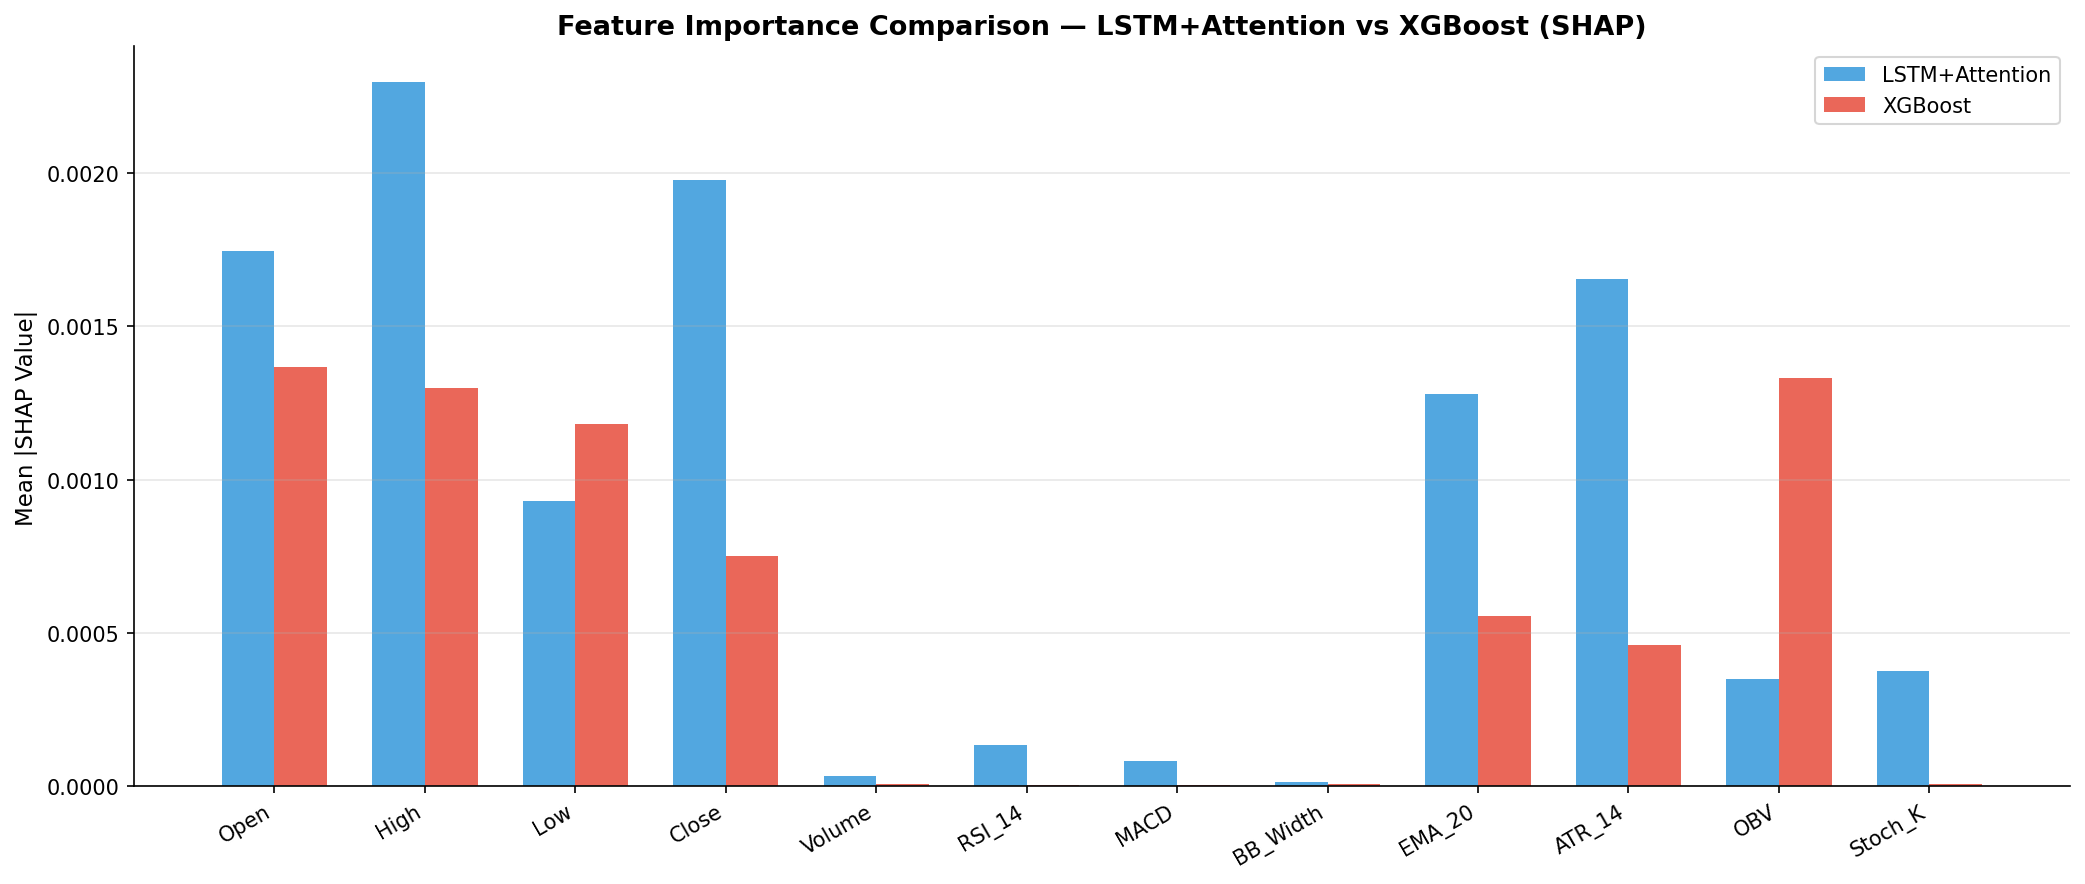

✅ Saved: shap_model_comparison.png


In [55]:
# ─── LSTM vs XGBoost SHAP Comparison ─────────────────────────────────────────
lstm_imp = np.abs(shap_feat).mean(axis=0)
xgb_imp  = np.abs(xgb_shap_feat).mean(axis=0)

x     = np.arange(N_FEATURES)
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
b1 = ax.bar(x - width/2, lstm_imp, width, label='LSTM+Attention', color='#3498db', alpha=0.85)
b2 = ax.bar(x + width/2, xgb_imp,  width, label='XGBoost',        color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_NAMES, rotation=30, ha='right', fontsize=10)
ax.set_ylabel("Mean |SHAP Value|")
ax.set_title("Feature Importance Comparison — LSTM+Attention vs XGBoost (SHAP)",
             fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f"{DIRS['viz_shap']}/shap_model_comparison.png", bbox_inches='tight', dpi=150)
plt.show()
print("✅ Saved: shap_model_comparison.png")

## Section 23 — Final Dashboard (Plotly)
KPIs · All Model Predictions · Attention Matrix · Feature Importance · SHAP Bars

In [56]:
best_model_name = metrics_df['RMSE'].idxmin()
best_rmse       = metrics_df.loc[best_model_name, 'RMSE']
best_r2         = metrics_df.loc[best_model_name, 'R²']
best_mape       = metrics_df.loc[best_model_name, 'MAPE(%)']
best_mae        = metrics_df.loc[best_model_name, 'MAE']
total_return    = ((df['Close'].iloc[-1] - df['Close'].iloc[0]) / df['Close'].iloc[0]) * 100
ann_vol         = df['Vol_30d'].mean() * 100
sharpe_approx   = (df['Daily_Return'].mean() / df['Daily_Return'].std()) * np.sqrt(252)

print(f"Best Model : {best_model_name}")
print(f"RMSE       : {best_rmse}")
print(f"R²         : {best_r2}")
print(f"Total Rtn  : {total_return:.2f}%")
print(f"Ann. Vol   : {ann_vol:.2f}%")
print(f"Sharpe     : {sharpe_approx:.3f}")

Best Model : Bi-LSTM
RMSE       : 219.5152
R²         : 0.9018
Total Rtn  : 3570.98%
Ann. Vol   : 2946.42%
Sharpe     : 1.467


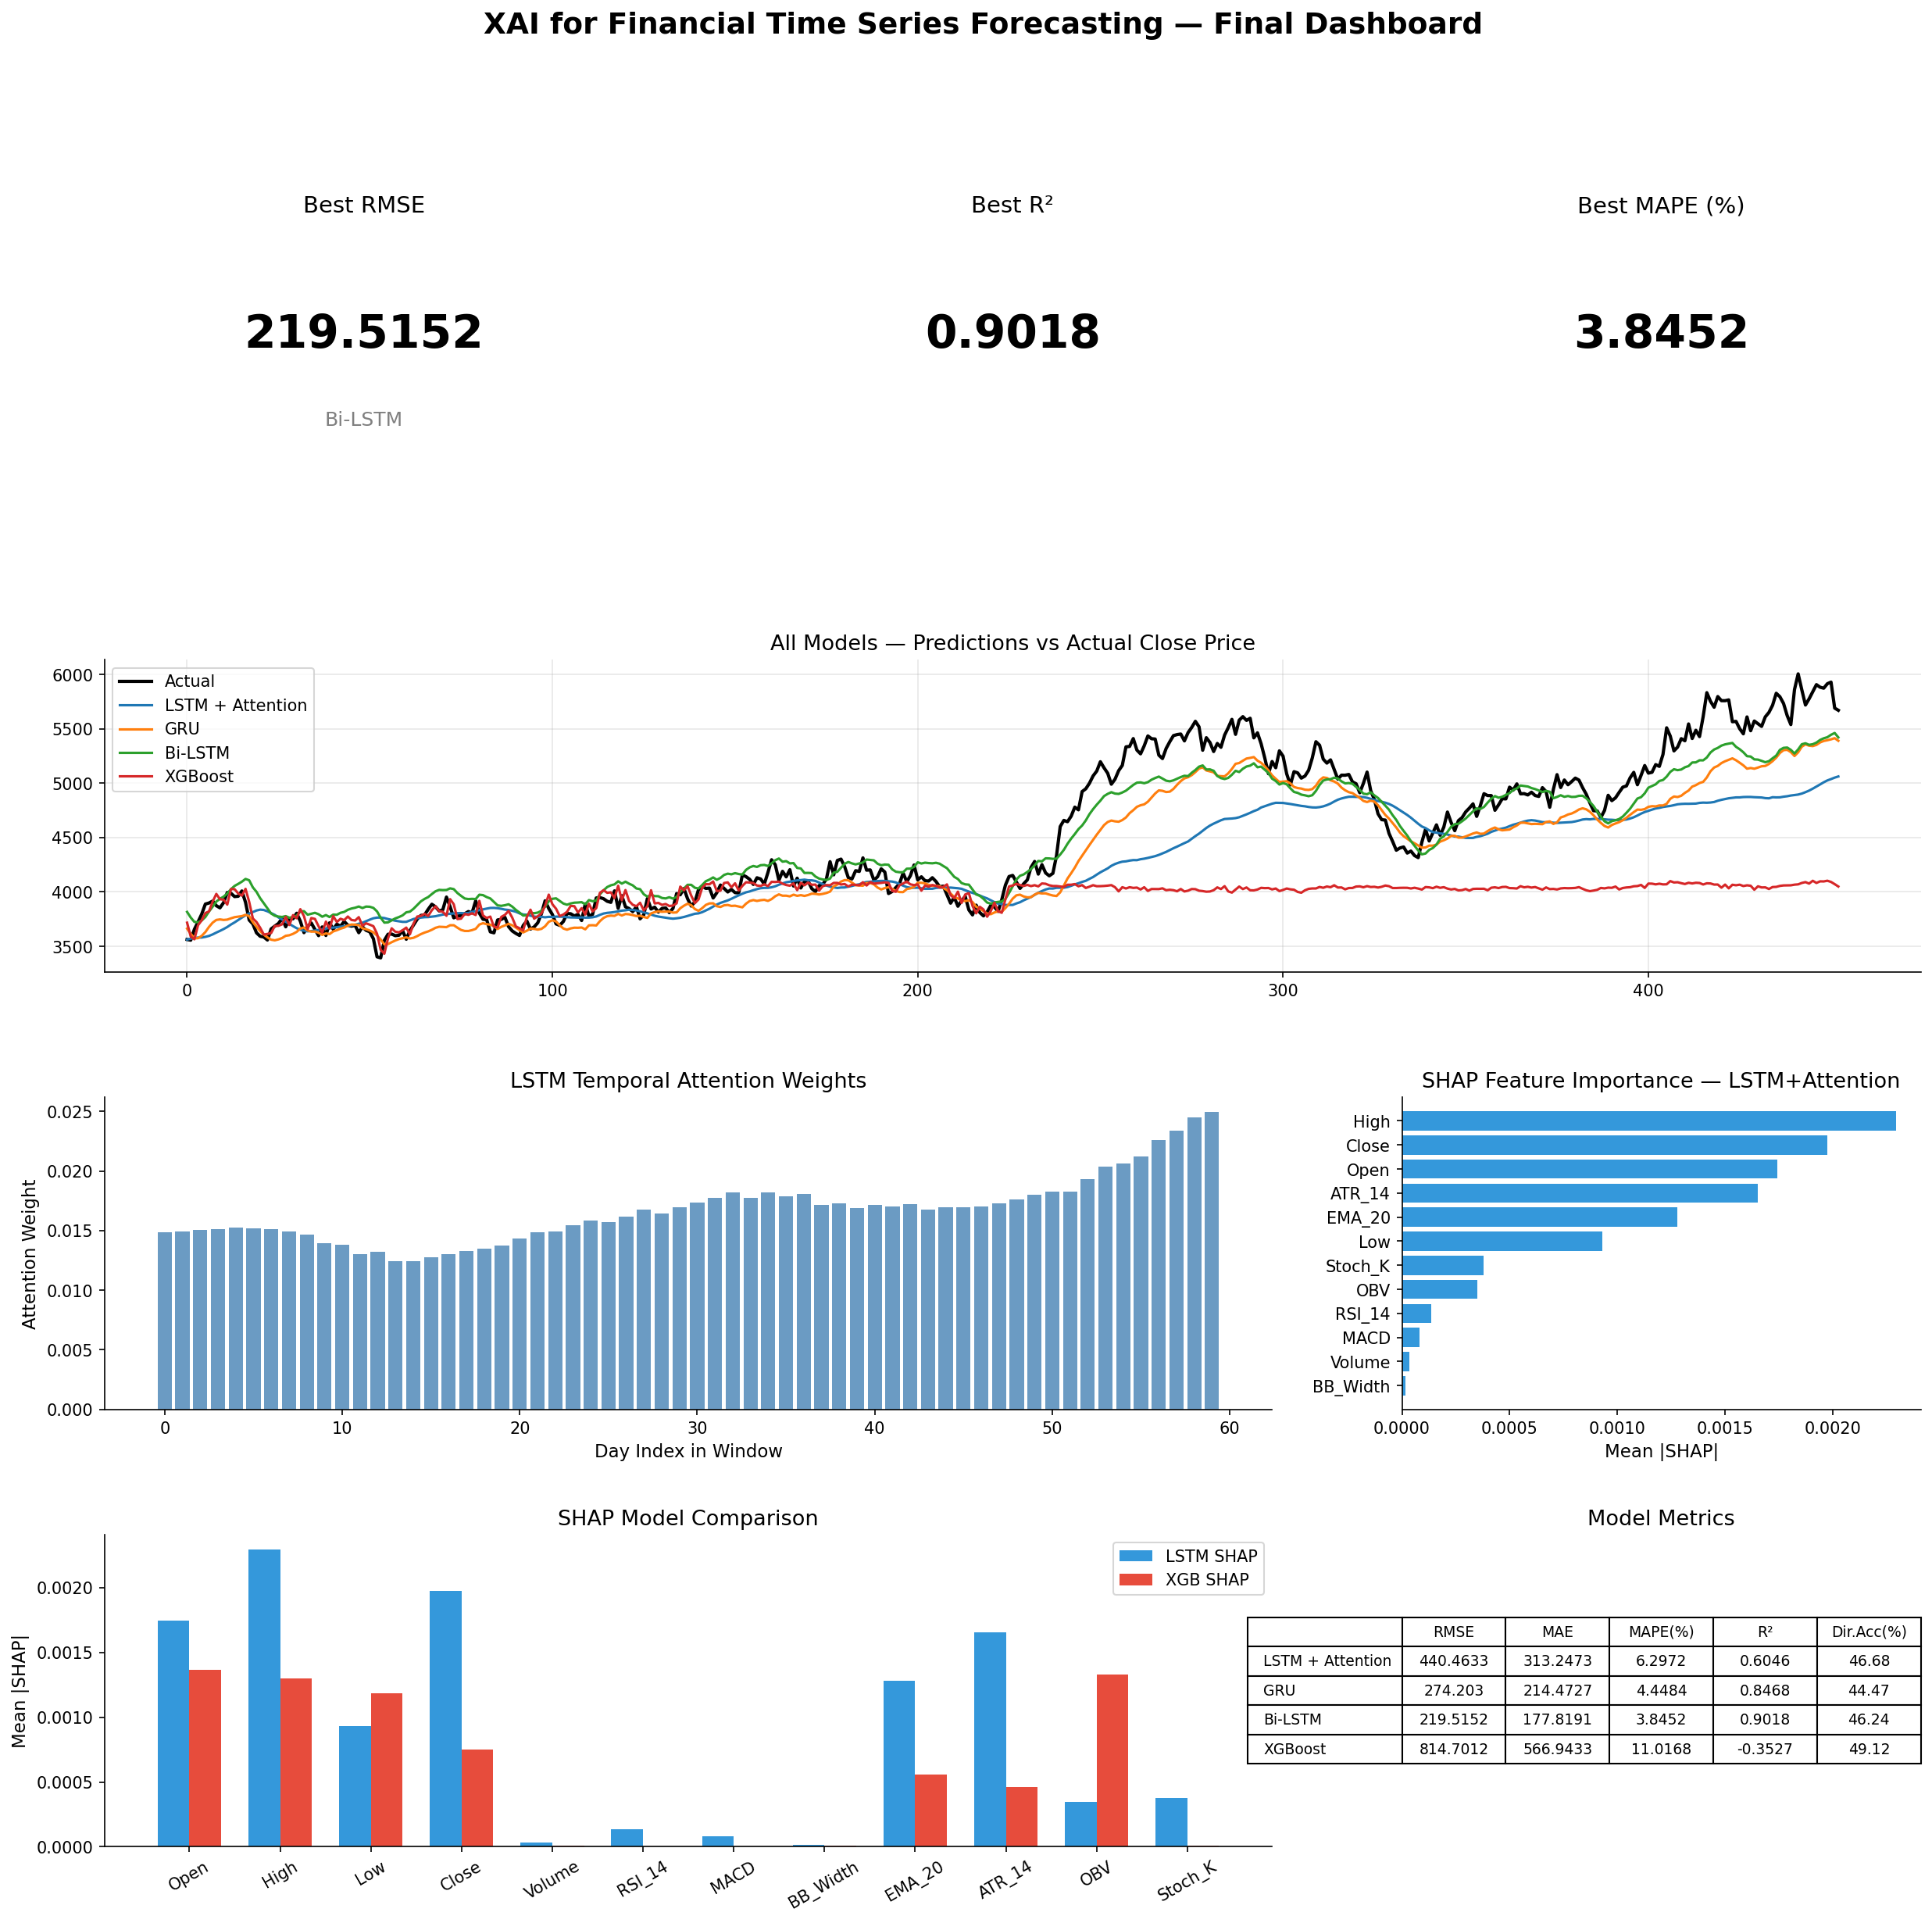

✅ Final dashboard saved as PNG


In [62]:
# ─── Final Dashboard (Matplotlib PNG Version) ────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure(figsize=(20, 18))
gs  = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.25)

# ─────────────────────────────────────────
# Row 1 — KPI Indicators (Text Panels)
# ─────────────────────────────────────────
kpi_titles = ["Best RMSE", "Best R²", "Best MAPE (%)"]
kpi_values = [best_rmse, best_r2, best_mape]

for i in range(3):
    ax = fig.add_subplot(gs[0, i])
    ax.axis('off')
    ax.text(0.5, 0.6, f"{kpi_values[i]:.4f}", fontsize=28, fontweight='bold', ha='center')
    if i == 0:
        ax.text(0.5, 0.35, best_model_name, fontsize=12, ha='center', color='gray')
    ax.set_title(kpi_titles[i], fontsize=14)

# ─────────────────────────────────────────
# Row 2 — Predictions vs Actual
# ─────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
td = list(range(len(y_test_inv)))

ax2.plot(td, y_test_inv, color='black', linewidth=2, label='Actual')

for name, pred, color in MODEL_PREDS:
    ax2.plot(td, pred, linewidth=1.5, label=name)

ax2.set_title("All Models — Predictions vs Actual Close Price")
ax2.legend()
ax2.grid(alpha=0.3)

# ─────────────────────────────────────────
# Row 3 Left — Attention Weights
# ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, :2])

ax3.bar(range(WINDOW_SIZE), mean_att, color='steelblue', alpha=0.8)
ax3.set_title("LSTM Temporal Attention Weights")
ax3.set_xlabel("Day Index in Window")
ax3.set_ylabel("Attention Weight")

# ─────────────────────────────────────────
# Row 3 Right — SHAP (LSTM)
# ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 2])

sorted_idx   = np.argsort(lstm_imp)
sorted_names = [FEATURE_NAMES[i] for i in sorted_idx]
sorted_vals  = lstm_imp[sorted_idx]

ax4.barh(sorted_names, sorted_vals, color='#3498db')
ax4.set_title("SHAP Feature Importance — LSTM+Attention")
ax4.set_xlabel("Mean |SHAP|")

# ─────────────────────────────────────────
# Row 4 Left — SHAP Comparison
# ─────────────────────────────────────────
ax5 = fig.add_subplot(gs[3, :2])

x = np.arange(len(FEATURE_NAMES))
width = 0.35

ax5.bar(x - width/2, lstm_imp, width, label='LSTM SHAP', color='#3498db')
ax5.bar(x + width/2, xgb_imp, width, label='XGB SHAP', color='#e74c3c')

ax5.set_xticks(x)
ax5.set_xticklabels(FEATURE_NAMES, rotation=30)
ax5.set_title("SHAP Model Comparison")
ax5.set_ylabel("Mean |SHAP|")
ax5.legend()

# ─────────────────────────────────────────
# Row 4 Right — Metrics Table
# ─────────────────────────────────────────
ax6 = fig.add_subplot(gs[3, 2])
ax6.axis('off')

table_data = [metrics_df.columns.tolist()] + metrics_df.values.tolist()
row_labels = [""] + metrics_df.index.tolist()

table = ax6.table(
    cellText=table_data,
    rowLabels=row_labels,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

ax6.set_title("Model Metrics")

# ─────────────────────────────────────────
# Final Layout
# ─────────────────────────────────────────
plt.suptitle("XAI for Financial Time Series Forecasting — Final Dashboard",
             fontsize=18, fontweight='bold')

plt.savefig(f"{DIRS['viz_dashboard']}/final_dashboard.png",
            bbox_inches='tight', dpi=150)

plt.show()

print("✅ Final dashboard saved as PNG")

## Section 24 — Save KPI & Final Reports

In [59]:
# ─── KPI Summary ─────────────────────────────────────────────────────────────
kpi_lines = []
kpi_lines.append("=" * 65)
kpi_lines.append("  KEY PERFORMANCE INDICATORS — XAI Financial Forecasting")
kpi_lines.append("=" * 65)
kpi_lines.append(f"  Best model           : {best_model_name}")
kpi_lines.append(f"  Best RMSE            : {best_rmse}")
kpi_lines.append(f"  Best MAE             : {best_mae}")
kpi_lines.append(f"  Best MAPE            : {best_mape}%")
kpi_lines.append(f"  Best R²              : {best_r2}")
kpi_lines.append("")
kpi_lines.append("  Dataset KPIs:")
kpi_lines.append(f"  Total synthesized days : {len(df)}")
kpi_lines.append(f"  Date range             : {df['Date'].min().date()} to {df['Date'].max().date()}")
kpi_lines.append(f"  Total return (GBM)     : {total_return:.2f}%")
kpi_lines.append(f"  Avg annualised vol     : {ann_vol:.2f}%")
kpi_lines.append(f"  Approx. Sharpe ratio   : {sharpe_approx:.3f}")
kpi_lines.append(f"  Features used          : {N_FEATURES} ({', '.join(FEATURE_NAMES)})")
kpi_lines.append(f"  Window size            : {WINDOW_SIZE} days")
kpi_lines.append(f"  Train/Test split       : 80% / 20%")
kpi_lines.append("")
kpi_lines.append("  All Models:")
kpi_lines.append(metrics_df.to_string())
kpi_lines.append("")
kpi_lines.append("  Top SHAP Features (LSTM+Attention):")
for rank, idx in enumerate(np.argsort(lstm_imp)[::-1][:5], 1):
    kpi_lines.append(f"    {rank}. {FEATURE_NAMES[idx]:<14} mean|SHAP|={lstm_imp[idx]:.6f}")
kpi_lines.append("=" * 65)

kpi_txt = "\n".join(kpi_lines)
with open(f"{DIRS['reports']}/kpi_summary.txt", "w") as f:
    f.write(kpi_txt)
print(kpi_txt)
print("\n✅ kpi_summary.txt saved")

  KEY PERFORMANCE INDICATORS — XAI Financial Forecasting
  Best model           : Bi-LSTM
  Best RMSE            : 219.5152
  Best MAE             : 177.8191
  Best MAPE            : 3.8452%
  Best R²              : 0.9018

  Dataset KPIs:
  Total synthesized days : 2321
  Date range             : 2015-10-08 to 2024-08-29
  Total return (GBM)     : 3570.98%
  Avg annualised vol     : 2946.42%
  Approx. Sharpe ratio   : 1.467
  Features used          : 12 (Open, High, Low, Close, Volume, RSI_14, MACD, BB_Width, EMA_20, ATR_14, OBV, Stoch_K)
  Window size            : 60 days
  Train/Test split       : 80% / 20%

  All Models:
                      RMSE       MAE  MAPE(%)      R²  Dir.Acc(%)
Model                                                            
LSTM + Attention  440.4633  313.2473   6.2972  0.6046       46.68
GRU               274.2030  214.4727   4.4484  0.8468       44.47
Bi-LSTM           219.5152  177.8191   3.8452  0.9018       46.24
XGBoost           814.7012  566.9433 

In [60]:
# ─── Final Summary ────────────────────────────────────────────────────────────
final_lines = []
final_lines.append("=" * 65)
final_lines.append("  FINAL PROJECT SUMMARY")
final_lines.append("  Developing XAI for Financial Time Series Forecasting")
final_lines.append("  Apple (AAPL) Synthesized Stock Data")
final_lines.append("=" * 65)
final_lines.append("")
final_lines.append("PROJECT OVERVIEW:")
final_lines.append("  This project develops an explainable AI (XAI) framework for")
final_lines.append("  financial time series forecasting using synthesized AAPL-like")
final_lines.append("  stock data generated via Geometric Brownian Motion (GBM).")
final_lines.append("")
final_lines.append("METHODOLOGY:")
final_lines.append(f"  - Data Synthesis   : GBM with mu=0.25, sigma=0.30, S0=150")
final_lines.append(f"  - Features         : {N_FEATURES} — OHLCV + 7 technical indicators")
final_lines.append(f"  - Window           : {WINDOW_SIZE}-day rolling sequences")
final_lines.append(f"  - Models trained   : LSTM+Attention, GRU, Bi-LSTM, XGBoost")
final_lines.append(f"  - XAI              : SHAP GradientExplainer + TreeExplainer")
final_lines.append("")
final_lines.append("RESULTS:")
final_lines.append(metrics_df.to_string())
final_lines.append("")
final_lines.append(f"  Best performing model : {best_model_name}")
final_lines.append(f"  RMSE                  : {best_rmse}")
final_lines.append(f"  R²                    : {best_r2}")
final_lines.append("")
final_lines.append("TOP XAI INSIGHTS (LSTM+Attention):")
for rank, idx in enumerate(np.argsort(lstm_imp)[::-1][:5], 1):
    final_lines.append(f"  {rank}. {FEATURE_NAMES[idx]:<14} — Mean |SHAP| = {lstm_imp[idx]:.6f}")
final_lines.append("")
final_lines.append(f"  Most influential time step: {WINDOW_SIZE - peak_day} days ago (index {peak_day})")
final_lines.append("")
final_lines.append("OUTPUTS SAVED:")
final_lines.append(f"  Visualizations : {BASE}/visualizations/")
final_lines.append(f"  Reports        : {BASE}/reports/")
final_lines.append(f"  Data           : {BASE}/data/")
final_lines.append("=" * 65)

final_txt = "\n".join(final_lines)
with open(f"{DIRS['reports']}/final_summary.txt", "w") as f:
    f.write(final_txt)
print(final_txt)
print("\n✅ final_summary.txt saved")

  FINAL PROJECT SUMMARY
  Developing XAI for Financial Time Series Forecasting
  Apple (AAPL) Synthesized Stock Data

PROJECT OVERVIEW:
  This project develops an explainable AI (XAI) framework for
  financial time series forecasting using synthesized AAPL-like
  stock data generated via Geometric Brownian Motion (GBM).

METHODOLOGY:
  - Data Synthesis   : GBM with mu=0.25, sigma=0.30, S0=150
  - Features         : 12 — OHLCV + 7 technical indicators
  - Window           : 60-day rolling sequences
  - Models trained   : LSTM+Attention, GRU, Bi-LSTM, XGBoost
  - XAI              : SHAP GradientExplainer + TreeExplainer

RESULTS:
                      RMSE       MAE  MAPE(%)      R²  Dir.Acc(%)
Model                                                            
LSTM + Attention  440.4633  313.2473   6.2972  0.6046       46.68
GRU               274.2030  214.4727   4.4484  0.8468       44.47
Bi-LSTM           219.5152  177.8191   3.8452  0.9018       46.24
XGBoost           814.7012  566.94

In [61]:
# ─── Print all saved files ────────────────────────────────────────────────────
import glob

print("=" * 60)
print("  ALL SAVED PROJECT FILES")
print("=" * 60)
for pattern in [f"{BASE}/**/*.*"]:
    files_found = sorted(glob.glob(pattern, recursive=True))
    for f in files_found:
        size = os.path.getsize(f)
        print(f"  {f.replace(BASE, '.')}  ({size:,} bytes)")
print("=" * 60)
print("\n✅ Capstone project complete.")

  ALL SAVED PROJECT FILES
  ./data/processed/AAPL_processed.csv  (427,614 bytes)
  ./data/raw/AAPL_synthesized_raw.csv  (151,404 bytes)
  ./reports/final_summary.txt  (1,843 bytes)
  ./reports/initial_summary.txt  (1,484 bytes)
  ./reports/kpi_summary.txt  (1,479 bytes)
  ./visualizations/cleaning/cleaning_overview.png  (266,603 bytes)
  ./visualizations/dashboard/eda_dashboard.html  (5,374,062 bytes)
  ./visualizations/dashboard/final_dashboard.html  (4,619,829 bytes)
  ./visualizations/eda/autocorrelation.png  (59,485 bytes)
  ./visualizations/eda/boxplot_skewness.png  (79,417 bytes)
  ./visualizations/eda/correlation_bivariate.png  (334,993 bytes)
  ./visualizations/eda/feature_correlation_full.png  (168,560 bytes)
  ./visualizations/eda/rolling_stats_volatility.png  (521,935 bytes)
  ./visualizations/eda/seasonality_analysis.png  (96,421 bytes)
  ./visualizations/eda/technical_indicators.png  (826,029 bytes)
  ./visualizations/eda/time_series_analysis.png  (205,812 bytes)
  ./visua

In [64]:
!ls /content/Capstone_Project/

data  reports  visualizations


In [66]:
import os
import zipfile
from google.colab import files

PROJECT_DIR = '/content/Capstone_Project'
OUTPUT_ZIP  = '/content/XAI_FinancialForecasting_Om.zip'

SAFE_DATE = (1980, 1, 1, 0, 0, 0)

folders_to_include = ['data', 'reports', 'visualizations']

with zipfile.ZipFile(OUTPUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:

    for folder in folders_to_include:
        folder_path = os.path.join(PROJECT_DIR, folder)
        if os.path.exists(folder_path):
            for root, dirs, filenames in os.walk(folder_path):
                for filename in filenames:
                    filepath = os.path.join(root, filename)
                    arcname  = os.path.relpath(filepath, PROJECT_DIR)
                    info = zipfile.ZipInfo(arcname, date_time=SAFE_DATE)
                    info.compress_type = zipfile.ZIP_DEFLATED
                    with open(filepath, 'rb') as f:
                        zf.writestr(info, f.read())
            print(f'Added: {folder}')
        else:
            print(f'Skipped (not found): {folder_path}')

    for filename in os.listdir('/content'):
        if filename.endswith('.ipynb'):
            filepath = f'/content/{filename}'
            info = zipfile.ZipInfo(filename, date_time=SAFE_DATE)
            info.compress_type = zipfile.ZIP_DEFLATED
            with open(filepath, 'rb') as f:
                zf.writestr(info, f.read())
            print(f'Added notebook: {filename}')

    readme_path = os.path.join(PROJECT_DIR, 'README.md')
    if os.path.exists(readme_path):
        info = zipfile.ZipInfo('README.md', date_time=SAFE_DATE)
        info.compress_type = zipfile.ZIP_DEFLATED
        with open(readme_path, 'rb') as f:
            zf.writestr(info, f.read())
        print('Added: README.md')

print('Zip created successfully')
files.download(OUTPUT_ZIP)

Added: data
Added: reports
Added: visualizations
Zip created successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>